Analyze groups of organoids (through frame table)

In [43]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
from datetime import datetime, timedelta
import datajoint as dj
from scipy.ndimage import gaussian_filter
import bottleneck as bn
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
import plotly.io as pio

In [45]:
import openpyxl

In [46]:
from element_array_ephys.ephys_no_curation import map_channel_to_electrode
from workflow.pipeline import frame, culture, ephys, analysis, mua, probe

Determine groups for analysis (store as frame keys)

In [47]:
group_organoids = {
    "H9 Batch 1": ["O09", "O10", "O11", "O12"],
    "H9 Batch 2": ["O13", "O14", "O15", "O16"],
    "H9-GBM Batch": ["O17", "O18", "O19", "O20"],
    "IF3 Batch": ["O21", "O22", "O23", "O24"],
    "F2M9-GBM Batch": ["O25", "O26", "O27", "O28"],
    "F2M9 Batch": ["O29", "O30", "O31", "O32"],
}
num_expected_groups = 2

analysis_keys = {}
for group_name, organoid_list in group_organoids.items():
    analysis_keys[group_name] = []
    
    drug_name = "Control"
    frame_param_idx = 6

    for organoid_id in organoid_list:
        experiment_start_time = (culture.Experiment & f"organoid_id = '{organoid_id}'" & f"drug_name = '{drug_name}'").fetch1("experiment_start_time")

        organoid_key = {
            "organoid_id": organoid_id,
            "experiment_start_time": experiment_start_time,
            "frame_param_idx": frame_param_idx,
        }
        frame_session_keys = (frame.FrameAnalysis & organoid_key).fetch("KEY")

        if len(frame_session_keys) != num_expected_groups:
            raise ValueError(f"Expected {num_expected_groups} frame sessions for organoid {organoid_id} but found {len(frame_session_keys)}")
        
        active_frame_keys = (frame.FrameAnalysis.ActiveTimeFrames & frame_session_keys).fetch("KEY", order_by="frame_start")

        # add start_time and end_time to keys (to match with ephys sessions)
        active_frame_keys = [
            {
                **key,
                "start_time": key['frame_start'],
                "end_time": key['frame_end'],
            }
            for key in active_frame_keys
        ]

        analysis_keys[group_name].extend(active_frame_keys)

In [48]:
# get frequency band information
# get frequency bands
frequency_bands = {
    band['band_name']: (band['lower_freq'], band['upper_freq']) for band in analysis.SpectralBand.fetch(as_dict=True, order_by='lower_freq')
    }

band_colors = {
    "delta": "#ad2bea",
    "theta": "#4d3ff8",
    "alpha": "#39cabb",
    "beta": "#53e53a",
    "gamma": "#e3e12c",
    "highgamma1": "#f7a740",
    "highgamma2": "#ed3838",
}

min_freq = 2
max_freq = 300

In [49]:
excel_workbook_path = "C:\\Users\\Organoid PC\\Documents\\Organoid_Analysis.xlsx"

OPTIONAL: Filter out keys

In [50]:
filter_dict = {}

In [51]:
exception_key = {
    "frame_start": [datetime(2023, 7, 11, 15, 22, 45),
                    datetime(2024, 10, 1, 18, 40, 1),
                    datetime(2024, 10, 1, 18, 37, 1)],
    "frame_end": [datetime(2023, 7, 11, 15, 27, 44),
                  datetime(2024, 10, 1, 18, 45),
                  datetime(2024, 10, 1, 18, 42)],
}

filter_dict["Artifact"] = {}
for group_name, keys in analysis_keys.items():

    artifact_bool = []
    for key in keys:
        if np.any([key[k] == v for k, v_list in exception_key.items() for v in v_list]):
            artifact_bool.append(True)
        else:
            artifact_bool.append(False)
    
    print(f"Group: {group_name}, Total Frames: {len(keys)}, Artifact Frames: {sum(artifact_bool)}")
    filter_dict["Artifact"][group_name] = artifact_bool

Group: H9 Batch 1, Total Frames: 64, Artifact Frames: 0
Group: H9 Batch 2, Total Frames: 48, Artifact Frames: 0
Group: H9-GBM Batch, Total Frames: 48, Artifact Frames: 3
Group: IF3 Batch, Total Frames: 35, Artifact Frames: 0
Group: F2M9-GBM Batch, Total Frames: 54, Artifact Frames: 3
Group: F2M9 Batch, Total Frames: 45, Artifact Frames: 0


In [52]:
filter_dict["Impedance"] = {}
min_impedance = 10000
max_impedance = 3000000

impedance_values = {}

for group_name, keys in analysis_keys.items():

    impedance_bool = []
    for key in keys:
        # fetch session_info
        session_info = (ephys.EphysSessionInfo & key).fetch1("session_info")
        
        # extract channel indices and impedance magnitudes
        port_id = (ephys.EphysSessionProbe & key).fetch1("port_id")
        impedance_magnitudes = np.array([channel_dict["electrode_impedance_magnitude"] for channel_dict in session_info["amplifier_channels"] if channel_dict["port_name"] == f"Port {port_id}"])
        mean_impedance = np.mean(impedance_magnitudes)

        # store impedance values if not already stored for that organoid
        # if it is stored, store another nested entry if the mean impedance is at least 5% different from the stored value
        electrode_indices = map_channel_to_electrode(input_indices=np.arange(32))
        
        if key['organoid_id'] not in impedance_values.keys():
            impedance_values[key['organoid_id']] = {}

            impedance_values[key['organoid_id']][key['frame_start'].strftime("%m/%d/%Y")] = impedance_magnitudes[electrode_indices]

        else:
            for date_str, stored_impedances in impedance_values[key['organoid_id']].items():
                if np.abs(mean_impedance - np.mean(stored_impedances)) / np.mean(stored_impedances) >= 0.05:
                    impedance_values[key['organoid_id']][key['frame_start'].strftime("%m/%d/%Y")] = impedance_magnitudes[electrode_indices]
                    break

        if (min_impedance <= mean_impedance) & (mean_impedance <= max_impedance):
            impedance_bool.append(False)
        else:
            impedance_bool.append(True)

    print(f"Group: {group_name}, Total Frames: {len(keys)}, Impedance Artifact Frames: {sum(impedance_bool)}")
    filter_dict["Impedance"][group_name] = impedance_bool

Group: H9 Batch 1, Total Frames: 64, Impedance Artifact Frames: 0
Group: H9 Batch 2, Total Frames: 48, Impedance Artifact Frames: 11
Group: H9-GBM Batch, Total Frames: 48, Impedance Artifact Frames: 15
Group: IF3 Batch, Total Frames: 35, Impedance Artifact Frames: 16
Group: F2M9-GBM Batch, Total Frames: 54, Impedance Artifact Frames: 11


C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_1308\3583845322.py:30: RuntimeWarning:

invalid value encountered in scalar divide

C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_1308\3583845322.py:30: RuntimeWarning:

invalid value encountered in scalar divide

C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_1308\3583845322.py:30: RuntimeWarning:

invalid value encountered in scalar divide

C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_1308\3583845322.py:30: RuntimeWarning:

invalid value encountered in scalar divide

C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_1308\3583845322.py:30: RuntimeWarning:

invalid value encountered in scalar divide

C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_1308\3583845322.py:30: RuntimeWarning:

invalid value encountered in scalar divide

C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_1308\3583845322.py:30: RuntimeWarning:

invalid value encountered in scalar divide

C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_1308\3583845

Group: F2M9 Batch, Total Frames: 45, Impedance Artifact Frames: 38


C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_1308\3583845322.py:30: RuntimeWarning:

invalid value encountered in scalar divide

C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_1308\3583845322.py:30: RuntimeWarning:

invalid value encountered in scalar divide



In [53]:
# TODO: Read through the "Impedance Values (Ohms)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using impedance_values
# loop through the impedance_values dictionary using the dictionary keys to fill in the "Organoid ID - (MM/DD/YYYY)" column, the electrode values (in 0-31 order) as the 
# values, and take the mean for the "Organoid Average" column
# Each key-value pair should fill one complete row

# Populate "Impedance Values (Ohms)" sheet
# Sheet layout (row 2 is the header):
#   Col A: "Organoid ID - (MM/DD/YYYY)"
#   Col B: "Organoid Average"
#   Cols C-AJ: Electrode indices 0-31
# impedance_values structure: {organoid_id: {date_str: np.array of shape (32,)}}
import openpyxl

wb_imp = openpyxl.load_workbook(excel_workbook_path)
ws_imp = wb_imp["Impedance Values (Ohms)"]

data_row = 3  # data starts on row 3 (row 1: label header, row 2: column headers)
for organoid_id, date_dict in impedance_values.items():
    for date_str, electrode_vals in date_dict.items():
        row_label = f"{organoid_id} - ({date_str})"
        ws_imp.cell(row=data_row, column=1, value=row_label)                            # Organoid ID - (MM/DD/YYYY)
        ws_imp.cell(row=data_row, column=2, value=float(np.mean(electrode_vals)))       # Organoid Average
        for elec_idx in range(len(electrode_vals)):                                     # Electrodes 0-31
            ws_imp.cell(row=data_row, column=3 + elec_idx, value=float(electrode_vals[elec_idx]))
        data_row += 1

wb_imp.save(excel_workbook_path)
print(f"Saved {data_row - 3} rows to 'Impedance Values (Ohms)'")

Saved 50 rows to 'Impedance Values (Ohms)'


In [54]:
# View population firing rates

filter_dict["Firing Rate"] = {}
min_firing_rate = 0.5

frame_firing_rate_values = {}

for group_name, keys in analysis_keys.items():

    firing_rate_bool = []
    firing_rate_list = []
    for key in keys:
        # fetch mua firing rates
        frame_firing_rate = (frame.FrameAnalysis.ActiveTimeFrames & key).fetch1("frame_firing_rate")
        firing_rate_list.append(frame_firing_rate)

        if frame_firing_rate >= min_firing_rate:
            firing_rate_bool.append(False)
        else:
            firing_rate_bool.append(True)

    print(f"Group: {group_name}, Total Frames: {len(keys)}, Low Firing Rate Frames: {sum(firing_rate_bool)}")
    filter_dict["Firing Rate"][group_name] = firing_rate_bool
    frame_firing_rate_values[group_name] = firing_rate_list


Group: H9 Batch 1, Total Frames: 64, Low Firing Rate Frames: 26
Group: H9 Batch 2, Total Frames: 48, Low Firing Rate Frames: 21
Group: H9-GBM Batch, Total Frames: 48, Low Firing Rate Frames: 23
Group: IF3 Batch, Total Frames: 35, Low Firing Rate Frames: 27
Group: F2M9-GBM Batch, Total Frames: 54, Low Firing Rate Frames: 35
Group: F2M9 Batch, Total Frames: 45, Low Firing Rate Frames: 33


In [56]:
# TODO: Read through the "Session Spike Rates (Hz)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using frame_firing_rate_values dictionary
# loop through the frame_firing_rate_values dictionary using the dictionary keys to fill in the "Organoid ID" 
# under the "Session Values" columns, fill in the firing rate values. List indices indicate the session index
#   if there are less sessions than number of columns, leave remaining columns blank
# under the "Organoid Average" column, fill in the average firing rate across sessions for each organoid
# Each key-value pair should fill one complete row

# Populate "Session Spike Rates (Hz)" sheet
# Sheet layout (row 2 is the header):
#   Col A: "Organoid ID"
#   Cols B onward: session indices 1, 2, 3, ...
# frame_firing_rate_values structure: {group_name: [rate_session0, rate_session1, ...]}
# The flat list is ordered by analysis_keys[group_name], so we rebuild per-organoid sub-lists.

wb_ssr = openpyxl.load_workbook(excel_workbook_path)
ws_ssr = wb_ssr["Session Spike Rates (Hz)"]

data_row = 3  # data starts on row 3
for group_name, firing_rate_list in frame_firing_rate_values.items():
    organoid_list_group = group_organoids[group_name]
    keys_group = analysis_keys[group_name]
    for organoid_id in organoid_list_group:
        organoid_sessions = [
            rate for key, rate in zip(keys_group, firing_rate_list)
            if key["organoid_id"] == organoid_id
        ]
        if not organoid_sessions:
            continue
        ws_ssr.cell(row=data_row, column=1, value=organoid_id)           # Organoid ID
        for sess_idx, rate in enumerate(organoid_sessions):               # Sessions start at col B (column 2)
            ws_ssr.cell(row=data_row, column=2 + sess_idx, value=float(rate))
        data_row += 1

wb_ssr.save(excel_workbook_path)
print(f"Saved {data_row - 3} rows to 'Session Spike Rates (Hz)'")

Saved 24 rows to 'Session Spike Rates (Hz)'


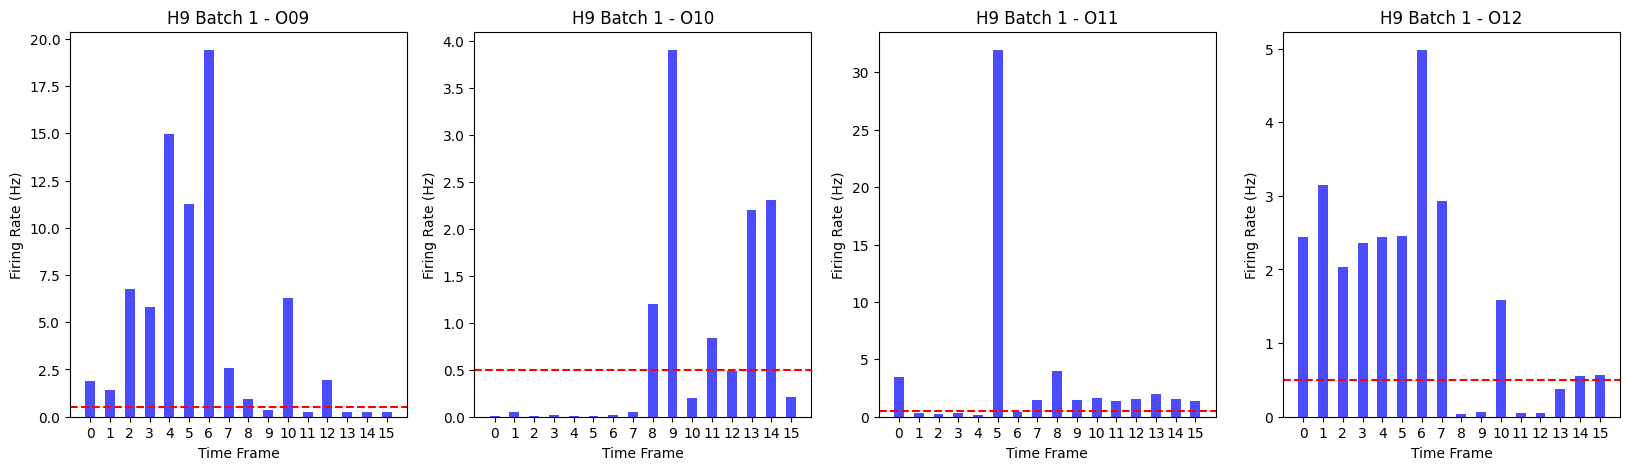

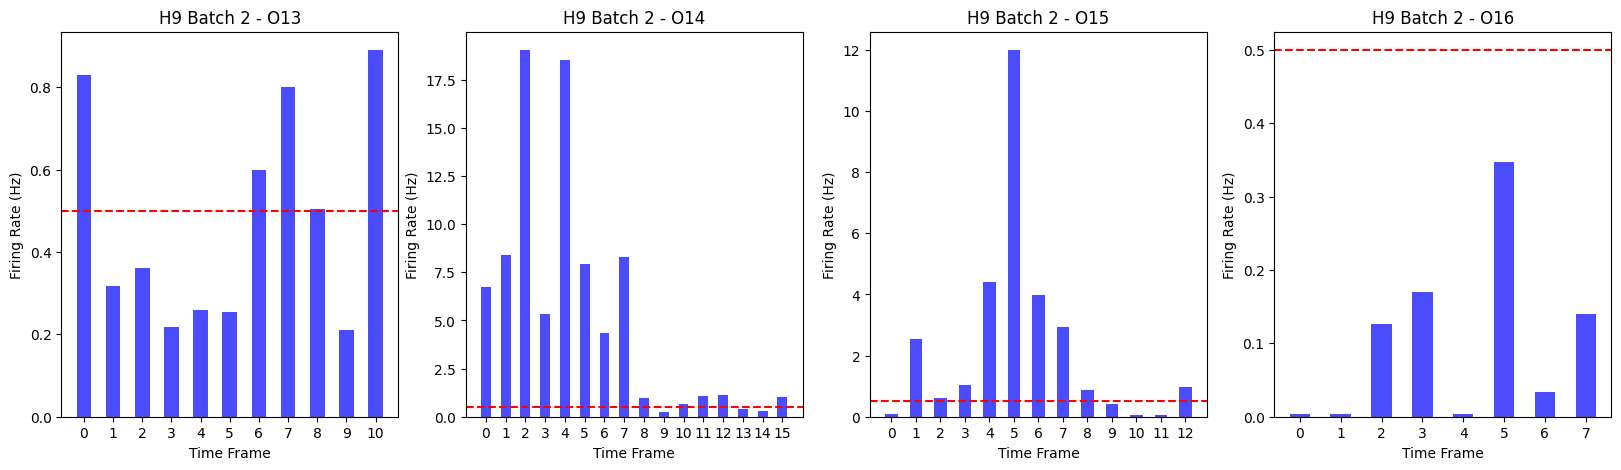

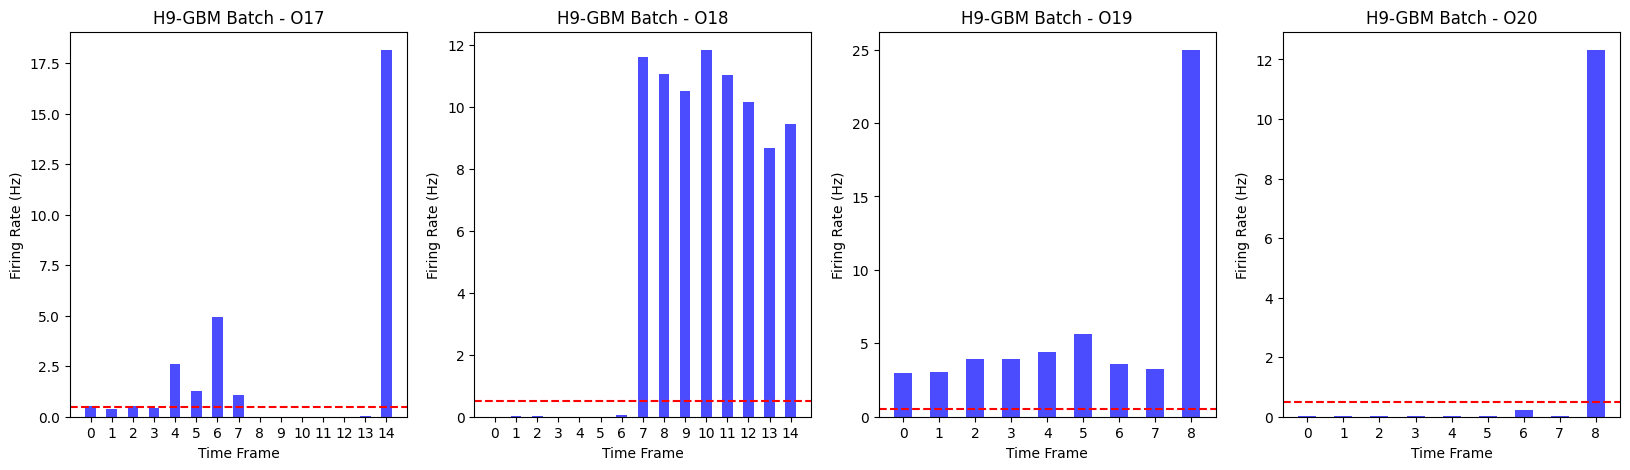

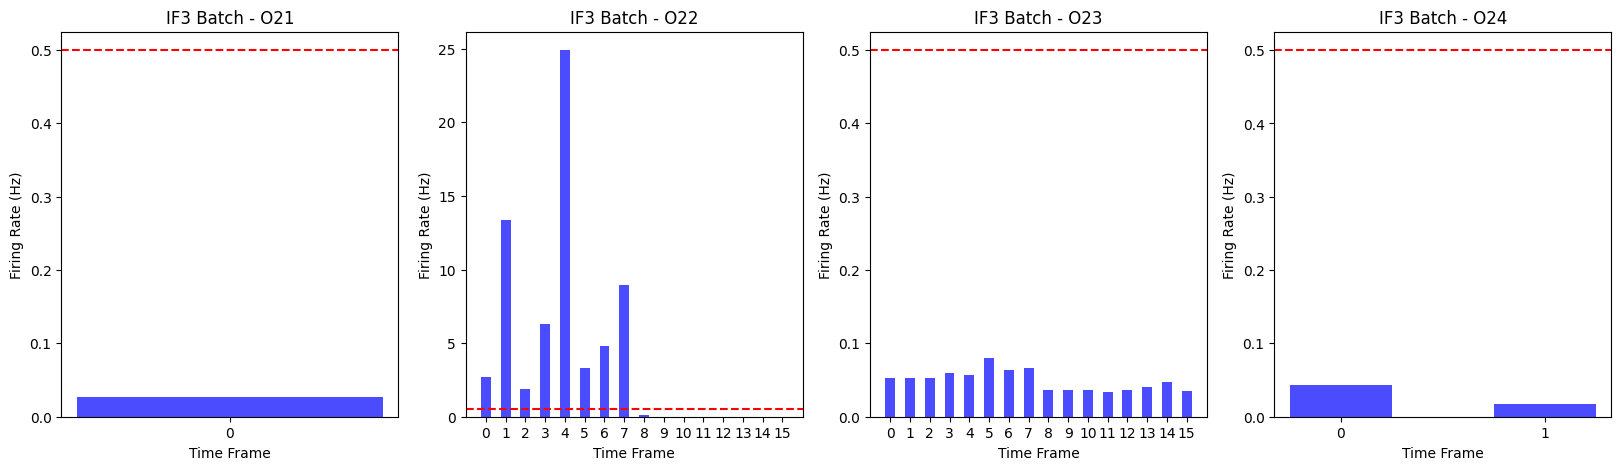

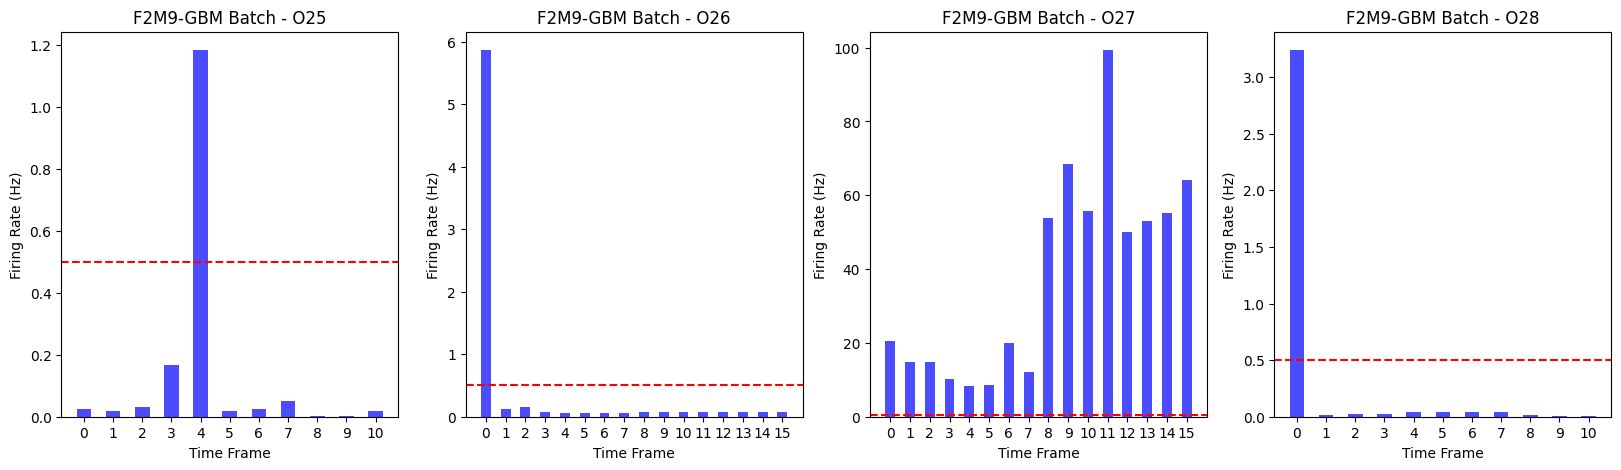

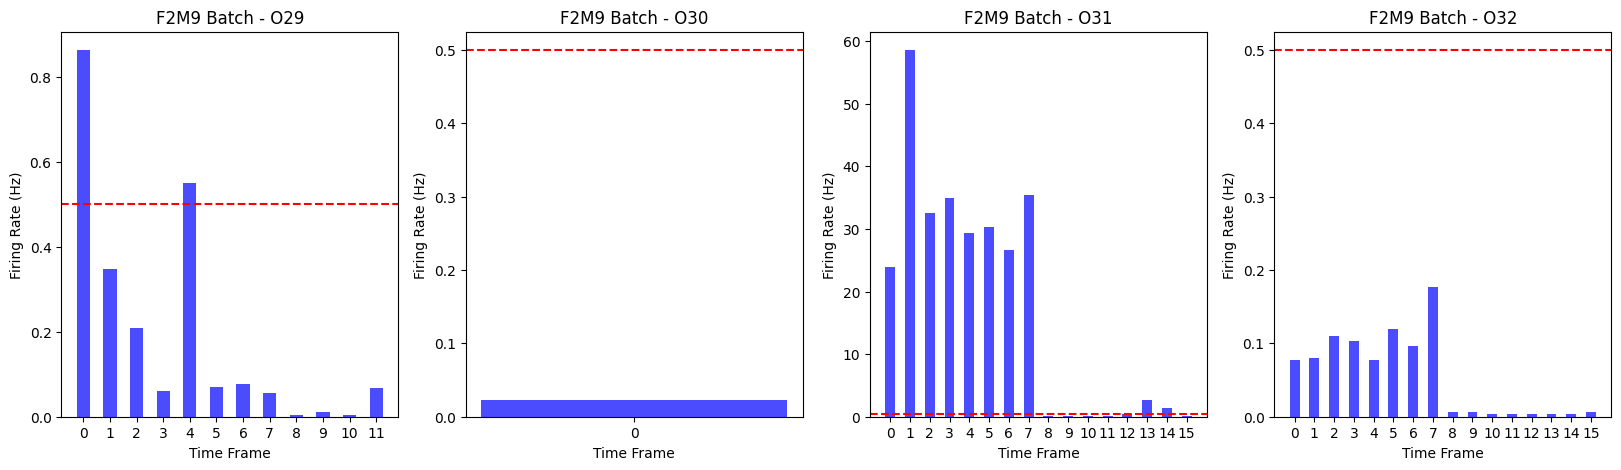

In [57]:
for group_name, keys in analysis_keys.items():

    num_organoids = len(group_organoids[group_name])
    fig, axs = plt.subplots(1, num_organoids, figsize=(5*num_organoids, 5))

    # fetch organoid ids and firing rates
    organoid_ids, firing_rates = (frame.FrameAnalysis.ActiveTimeFrames & keys).fetch("organoid_id", "frame_firing_rate")

    for i, organoid_id in enumerate(group_organoids[group_name]):
        ax = axs[i]
        organoid_firing_rates = firing_rates[organoid_ids == organoid_id]
        x = np.arange(len(organoid_firing_rates))

        ax.bar(x, organoid_firing_rates, color="blue", alpha=0.7, width=0.5)
        ax.axhline(min_firing_rate, color="red", linestyle="--")
        ax.set_title(f"{group_name} - {organoid_id}")
        ax.set_xlabel("Time Frame")
        ax.set_ylabel("Firing Rate (Hz)")
        ax.set_xticks(x)
    
    plt.show()

In [58]:
exclude_list = ["Impedance"] # list of filters to exclude (leave empty if none)

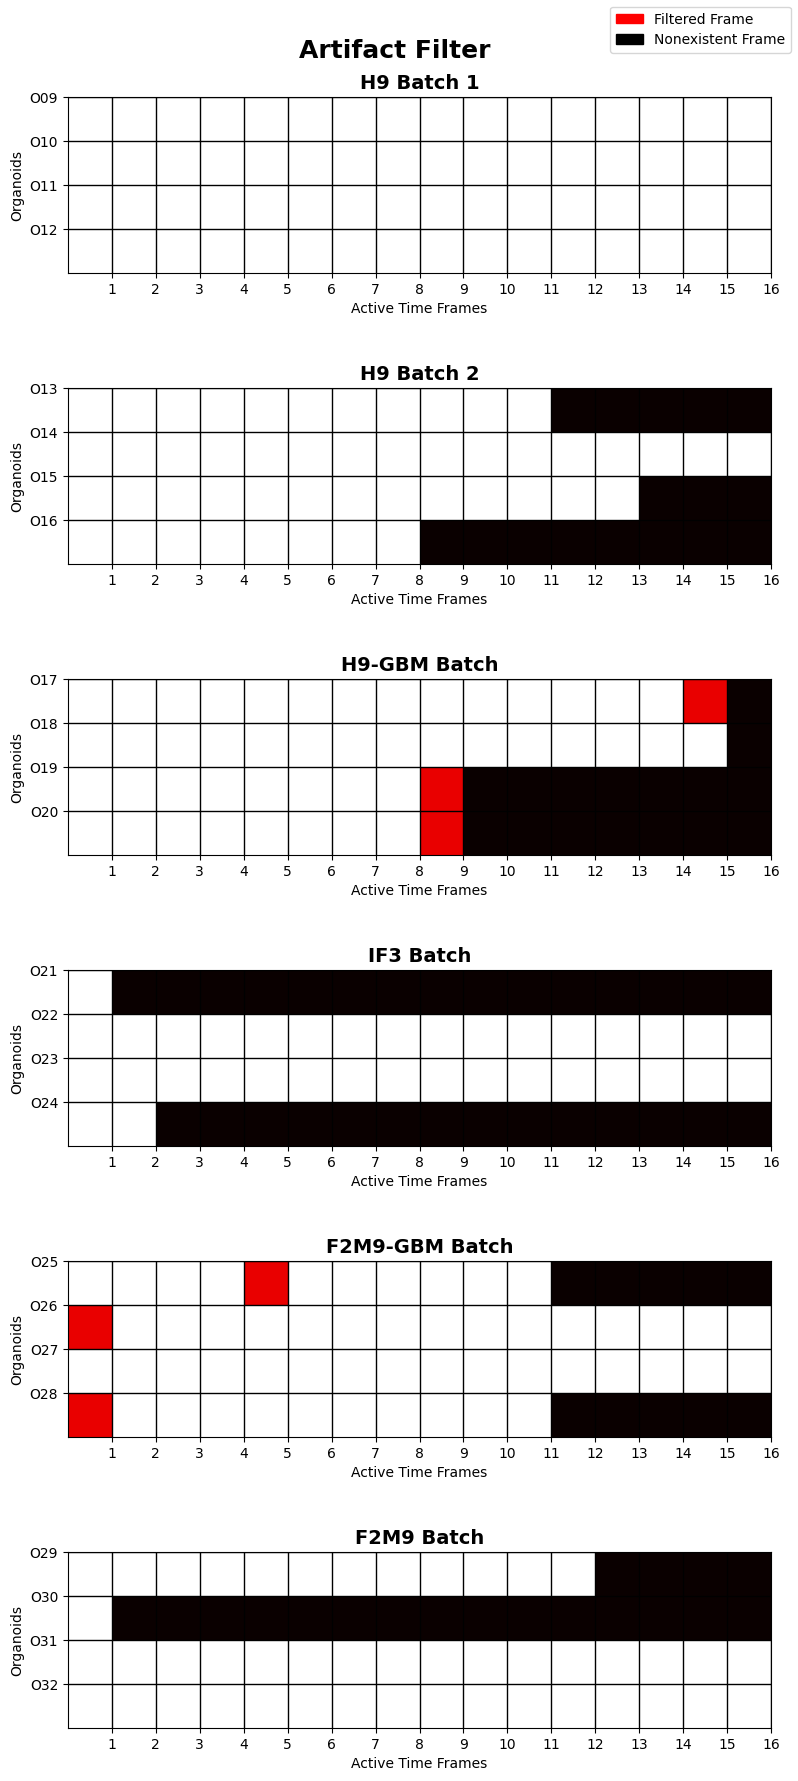

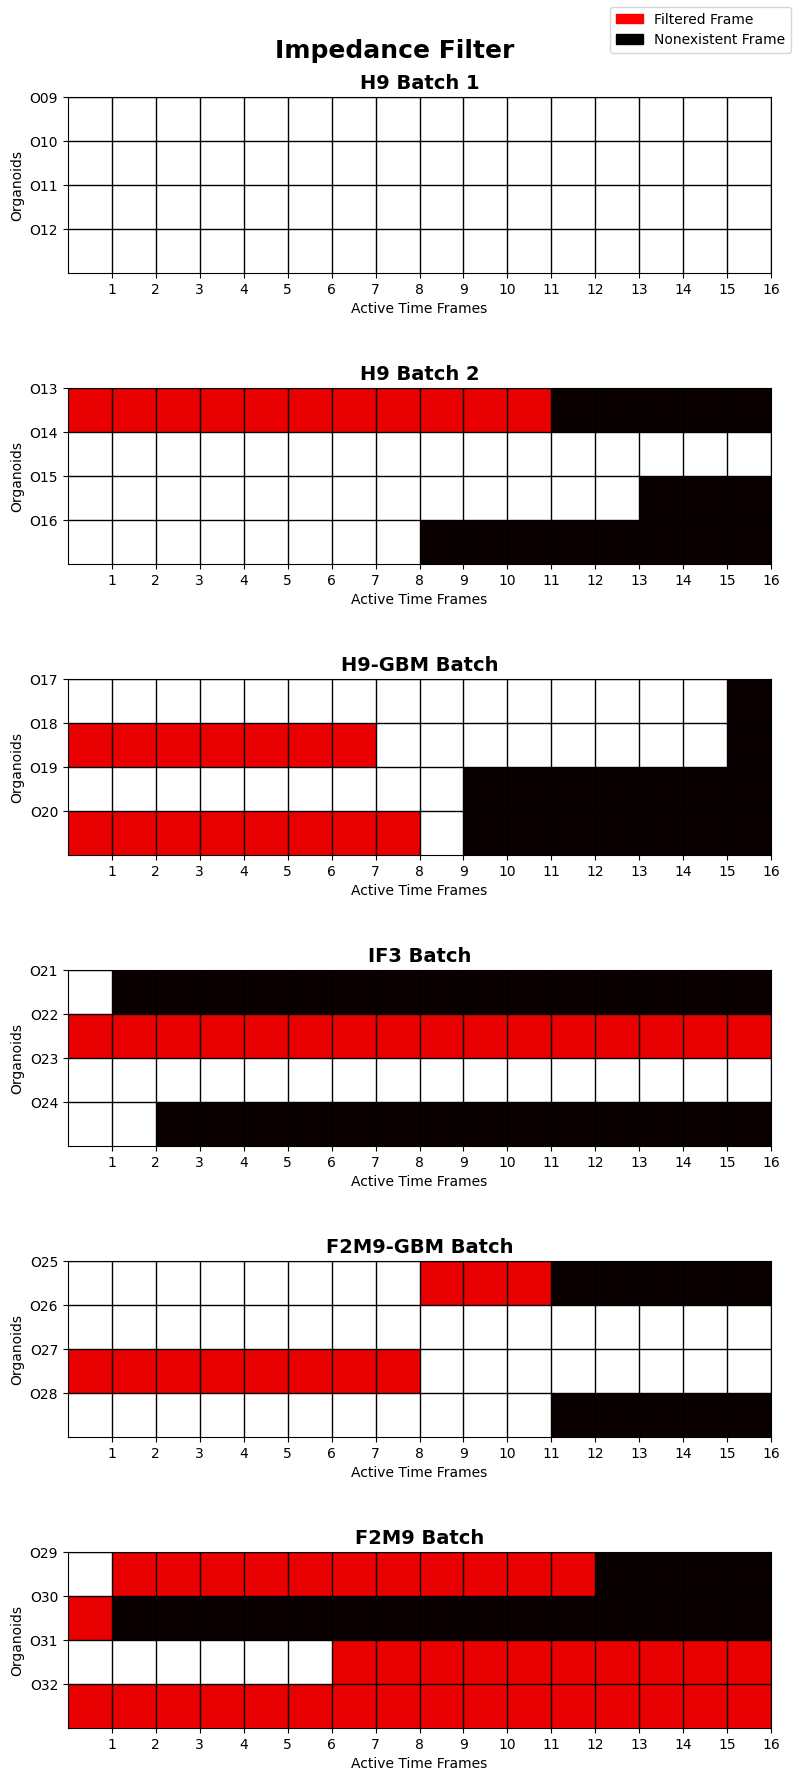

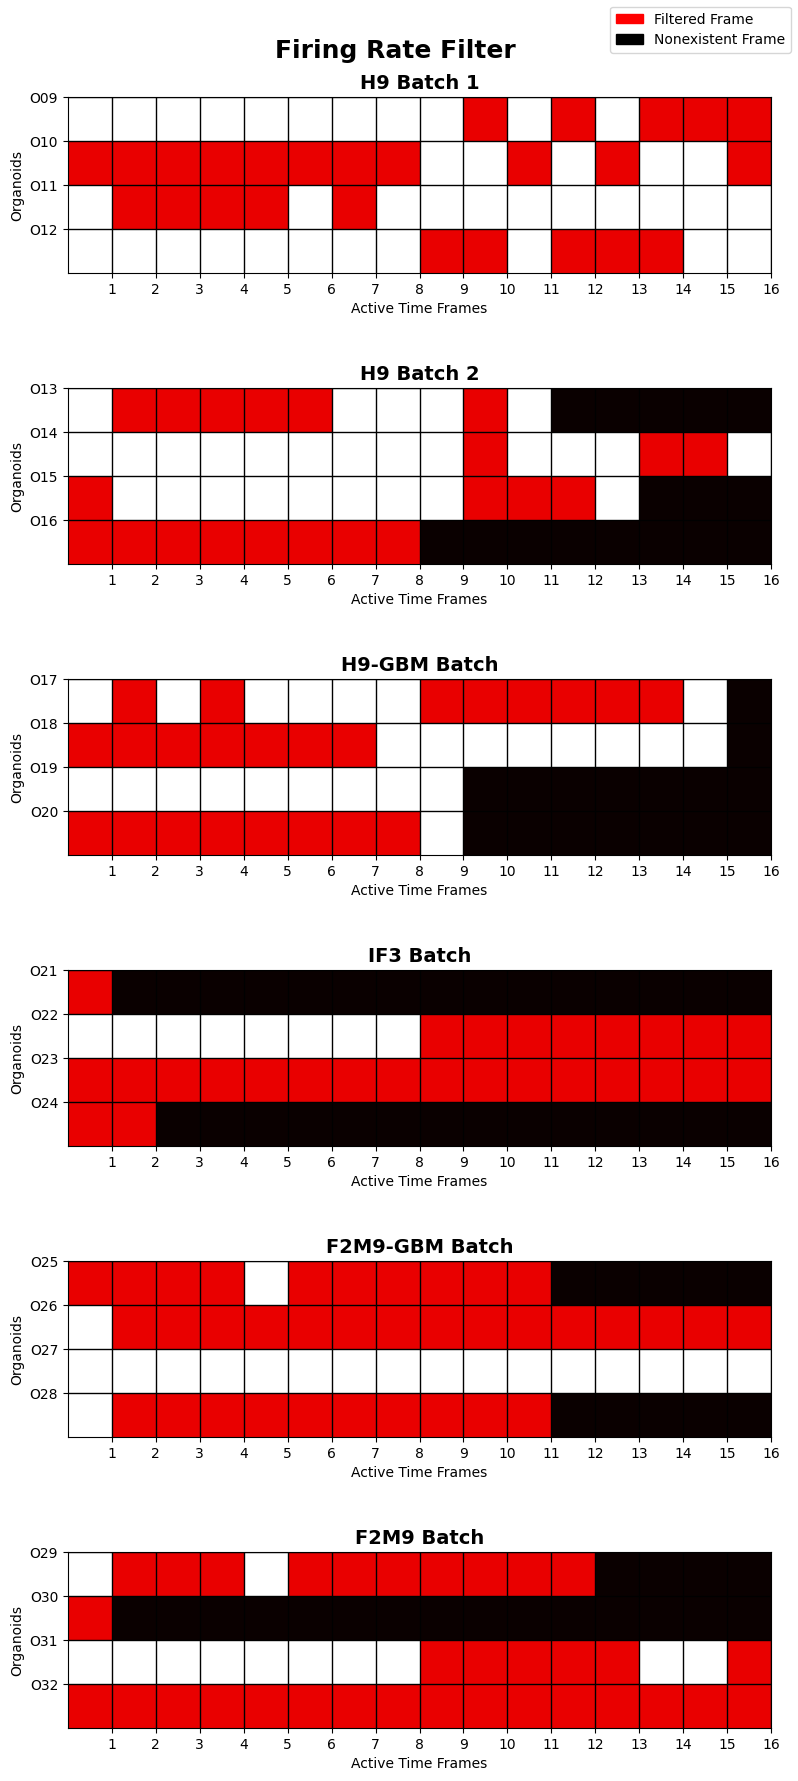

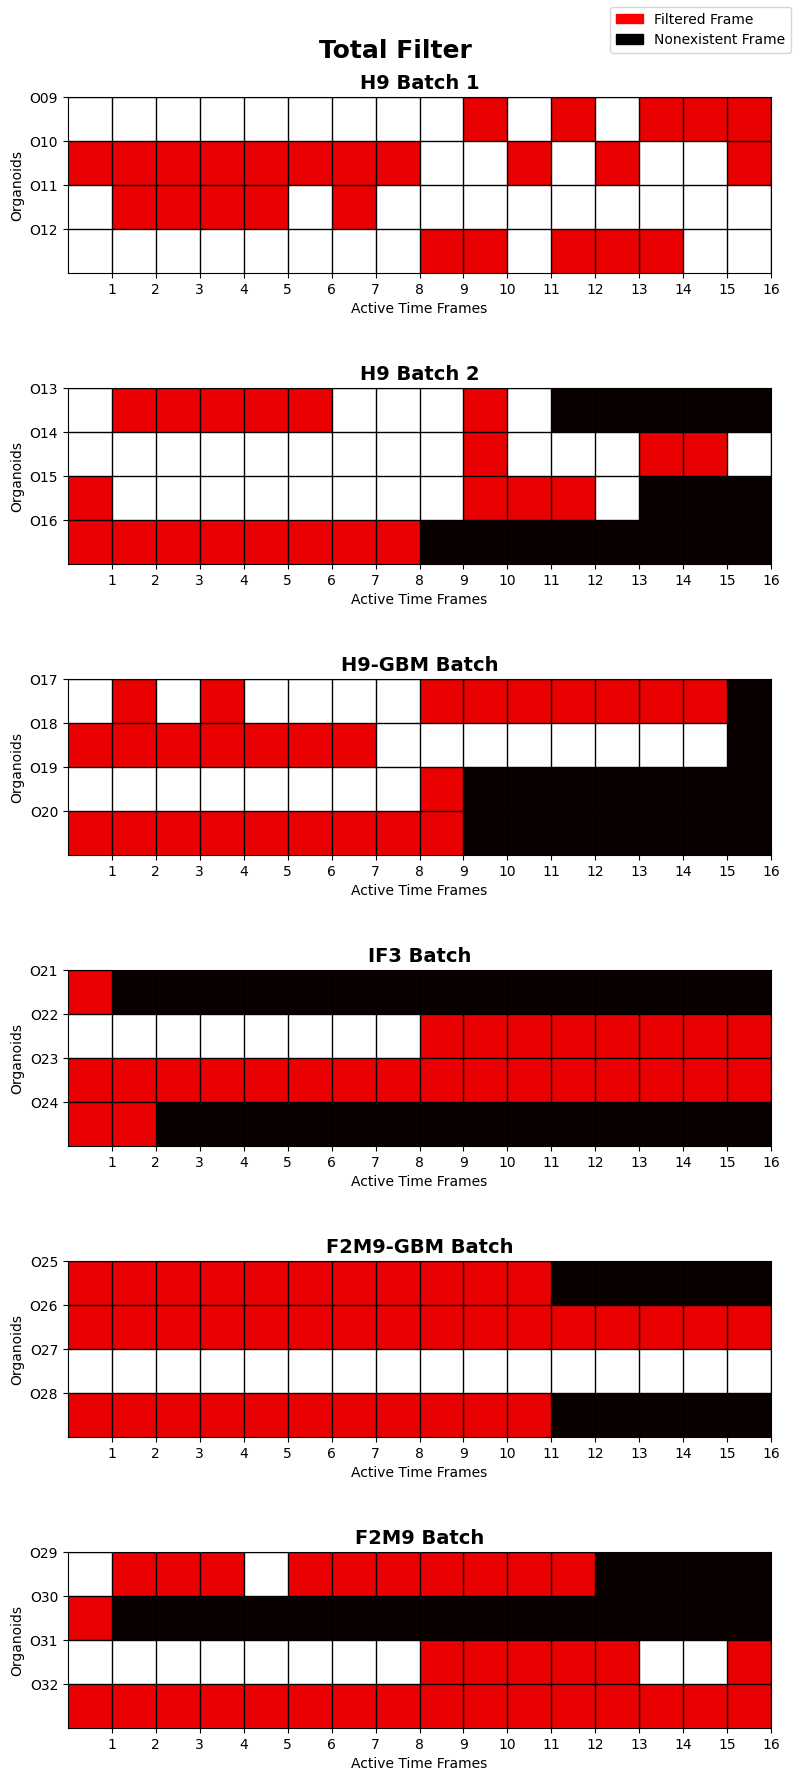

In [59]:
# Visualize filter results

max_sessions = (frame.TimeFrameParamset & f"frame_param_idx = {frame_param_idx}").fetch1("num_frames") * num_expected_groups

for filter_name, group_dict in filter_dict.items():
    # For each filter, make a figure. 
    # Each group gets a subplot, and within each subplot, each organoid gets a row of red squares indicating which frames are filtered out by that filter.
    # Some organoids will not have the maximum number of frames, those blocks will appear as black

    fig, axs = plt.subplots(len(group_dict), 1, figsize=(8, 3*len(group_dict)), tight_layout=True)
    fig.suptitle(f"{filter_name} Filter", fontsize=18, fontweight="bold")

    for i, (group_name, bool_list) in enumerate(group_dict.items()):
        ax = axs[i]
        organoid_list = group_organoids[group_name]

        # create an array of zeros with shape (num_organoids, max_sessions)
        num_organoids = len(organoid_list)
        filter_array = np.ones((num_organoids, max_sessions))

        # determine which frames to filter out for each organoid and populate the filter_array
        active_frames = np.array(analysis_keys[group_name])
        filtered_frames = active_frames[bool_list]

        for ii, organoid_id in enumerate(organoid_list):
            
            # extract frames corresponding to the current organoid
            organoid_bool = [key["organoid_id"] == organoid_id for key in active_frames]

            # determine number of frames for this organoid
            num_frames = sum(organoid_bool)
            filter_array[ii, num_frames:] = 0

            # mark filtered frames in the filter_array
            filtered_frames_bool = np.array(bool_list)[organoid_bool]
            filter_array[ii, :num_frames] = (filtered_frames_bool * (-2/3))+1 # mark filtered frames with 0.5 and unfiltered frames with 0 (already initialized)

        # Visualize the filter array for this group
        ax.imshow(filter_array, aspect="equal", cmap="hot", vmin=0, vmax=1)
        ax.set_title(group_name, fontsize=14, fontweight="bold")
        ax.set_ylabel("Organoids")
        ax.set_xlabel("Active Time Frames")

        ax.set_yticks(np.arange(num_organoids)-.5)
        ax.set_yticklabels(organoid_list)
        ax.set_xticks(np.arange(max_sessions)+.5)
        ax.set_xticklabels(np.arange(1, max_sessions+1))    
    
        # turn on grid lines
        ax.grid(which="both", color="black", linestyle="-", linewidth=1)

    # create global legend
    red_patch = Patch(color="red", label="Filtered Frame")
    black_patch = Patch(color="black", label="Nonexistent Frame")
    fig.legend(handles=[red_patch, black_patch], loc="upper right")

    plt.show()

# Create a figure for all filters

# get total filter bool
total_filter = {
    group_name: np.any([group_dict[group_name] for filter_name, group_dict in filter_dict.items() if filter_name not in exclude_list], axis=0)
    for group_name in analysis_keys.keys()
}

fig, axs = plt.subplots(len(group_dict), 1, figsize=(8, 3*len(group_dict)), tight_layout=True)
fig.suptitle("Total Filter", fontsize=18, fontweight="bold")

for i, (group_name, bool_list) in enumerate(total_filter.items()):
    ax = axs[i]
    organoid_list = group_organoids[group_name]

    # create an array of zeros with shape (num_organoids, max_sessions)
    num_organoids = len(organoid_list)
    filter_array = np.ones((num_organoids, max_sessions))

    # determine which frames to filter out for each organoid and populate the filter_array
    active_frames = np.array(analysis_keys[group_name])
    filtered_frames = active_frames[bool_list]

    for ii, organoid_id in enumerate(organoid_list):
        
        # extract frames corresponding to the current organoid
        organoid_bool = [key["organoid_id"] == organoid_id for key in active_frames]

        # determine number of frames for this organoid
        num_frames = sum(organoid_bool)
        filter_array[ii, num_frames:] = 0

        # mark filtered frames in the filter_array
        filtered_frames_bool = np.array(bool_list)[organoid_bool]
        filter_array[ii, :num_frames] = (filtered_frames_bool * (-2/3))+1 # mark filtered frames with 0.5 and unfiltered frames with 0 (already initialized)

    # Visualize the filter array for this group
    ax.imshow(filter_array, aspect="equal", cmap="hot", vmin=0, vmax=1)
    ax.set_title(group_name, fontsize=14, fontweight="bold")
    ax.set_ylabel("Organoids")
    ax.set_xlabel("Active Time Frames")

    ax.set_yticks(np.arange(num_organoids)-.5)
    ax.set_yticklabels(organoid_list)
    ax.set_xticks(np.arange(max_sessions)+.5)
    ax.set_xticklabels(np.arange(1, max_sessions+1))    

    # turn on grid lines
    ax.grid(which="both", color="black", linestyle="-", linewidth=1)

# create global legend
red_patch = Patch(color="red", label="Filtered Frame")
black_patch = Patch(color="black", label="Nonexistent Frame")
fig.legend(handles=[red_patch, black_patch], loc="upper right")

plt.show()


In [60]:
# Filter out keys
for group_name, bool_list in total_filter.items():

    filtered_keys = np.array(analysis_keys[group_name])[~bool_list]
    analysis_keys[group_name] = filtered_keys

In [61]:
# Determine number of sessions per organoid after filtering
num_sessions_dict = {}
analysis_organoids_dict = {}

for group_name, keys in analysis_keys.items():
    num_sessions_dict[group_name] = {}

    organoid_ids = np.array([key["organoid_id"] for key in keys])
    organoid_list = group_organoids[group_name]

    print(f"Group: {group_name}")
    group_organoids_list = []
    for organoid_id in organoid_list:
        num_sessions = sum(organoid_ids == organoid_id)
        num_sessions_dict[group_name][organoid_id] = num_sessions
        print(f"Organoid: {organoid_id}, Sessions: {num_sessions}")

        if num_sessions > 0:
            group_organoids_list.append(organoid_id)
    analysis_organoids_dict[group_name] = np.array(group_organoids_list)

Group: H9 Batch 1
Organoid: O09, Sessions: 11
Organoid: O10, Sessions: 5
Organoid: O11, Sessions: 11
Organoid: O12, Sessions: 11
Group: H9 Batch 2
Organoid: O13, Sessions: 5
Organoid: O14, Sessions: 13
Organoid: O15, Sessions: 9
Organoid: O16, Sessions: 0
Group: H9-GBM Batch
Organoid: O17, Sessions: 6
Organoid: O18, Sessions: 8
Organoid: O19, Sessions: 8
Organoid: O20, Sessions: 0
Group: IF3 Batch
Organoid: O21, Sessions: 0
Organoid: O22, Sessions: 8
Organoid: O23, Sessions: 0
Organoid: O24, Sessions: 0
Group: F2M9-GBM Batch
Organoid: O25, Sessions: 0
Organoid: O26, Sessions: 0
Organoid: O27, Sessions: 16
Organoid: O28, Sessions: 0
Group: F2M9 Batch
Organoid: O29, Sessions: 2
Organoid: O30, Sessions: 0
Organoid: O31, Sessions: 10
Organoid: O32, Sessions: 0


In [62]:
group_colors = {
    "H9 Batch 1": "#3FC8F2",
    "H9 Batch 2": "#3F4BF2",
    "H9-GBM Batch": "#F23F62",
    "IF3 Batch": "#C23FF2",
    "F2M9-GBM Batch": "#F2993F",
    "F2M9 Batch": "#F23FDA",
}

box_width = 0.2
box_spacing = 0.05
group_spacing = 0.25

# get x positions for each organoid plot
x_positions = {}
x = 0
for analysis_organoids in analysis_organoids_dict.values():
    for organoid_id in analysis_organoids:
        x_positions[organoid_id] = x
        x += (box_width + box_spacing)
    x += group_spacing

In [63]:
fs = 20000

MUA Firing Rate

In [64]:
# Get Firing Rate Data
firing_rate_dict = {}
for group_name, keys in analysis_keys.items():
    firing_rate_dict[group_name] = {}

    organoid_ids, channel_firing_rates, channel_indices = (mua.MUASpikes.Channel & keys).fetch("organoid_id", "spike_rate", "channel_idx")
    electrode_indices = map_channel_to_electrode(input_indices=channel_indices)

    for organoid_id in analysis_organoids_dict[group_name]:
        
        organoid_mask = organoid_ids == organoid_id
        num_elec_inside = (culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")

        organoid_firing_rates = []
        for elec in range(num_elec_inside):
            elec_mask = electrode_indices == elec

            # ensure there are the expected number of data values
            if sum(organoid_mask & elec_mask) != num_sessions_dict[group_name][organoid_id]:
                raise ValueError(f"Expected {num_sessions_dict[group_name][organoid_id]} data points for organoid {organoid_id} and electrode {elec} but found {sum(organoid_mask & elec_mask)}")

            # average channel firing rates across sessions (per electrode)
            organoid_firing_rates.append(np.mean(channel_firing_rates[organoid_mask & elec_mask]))
        
        firing_rate_dict[group_name][organoid_id] = np.array(organoid_firing_rates)

In [65]:
# TODO: Read through the "Spike Rates (Hz)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using firing_rate_dict
# loop through the firing_rate_dict using the dictionary keys to fill in the "Organoid ID" column
# under the "Electrode Values" columns, fill in the firing rate values. List indices indicate the electrode index (0-31)
#      if there are less electrodes than number of columns, leave remaining columns blank
# under the "Organoid Average" column, fill in the average firing rate across electrodes for each organoid

# Populate "Spike Rates (Hz)" sheet
# Sheet layout (row 2 is the header):
#   Col A: "Organoid ID"
#   Col B: "Organoid Average"  (typo in sheet: "Orgnaoid Average")
#   Cols C-AJ: Electrode indices 0-31
# firing_rate_dict structure: {group_name: {organoid_id: np.array of shape (num_elec_inside,)}}
wb_sr = openpyxl.load_workbook(excel_workbook_path)
ws_sr = wb_sr["Spike Rates (Hz)"]

data_row = 3  # data starts on row 3
for group_name, group_dict in firing_rate_dict.items():
    for organoid_id, electrode_rates in group_dict.items():
        ws_sr.cell(row=data_row, column=1, value=organoid_id)                          # Organoid ID
        ws_sr.cell(row=data_row, column=2, value=float(np.mean(electrode_rates)))      # Organoid Average
        for elec_idx, rate in enumerate(electrode_rates):                              # Electrodes 0-31
            ws_sr.cell(row=data_row, column=3 + elec_idx, value=float(rate))
        data_row += 1

wb_sr.save(excel_workbook_path)
print(f"Saved {data_row - 3} rows to 'Spike Rates (Hz)'")

Saved 14 rows to 'Spike Rates (Hz)'


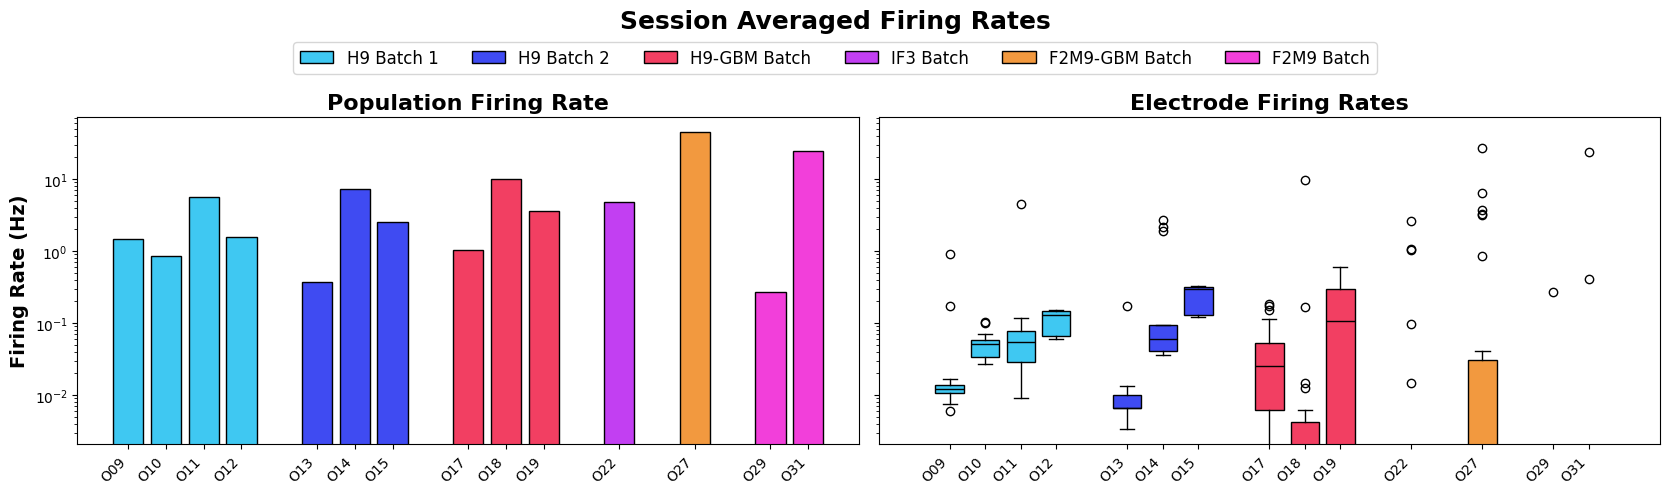

In [66]:
# Plot organoid firing rate (1x2 figure)
# Left subplot: Bar plot with height corresponding to population firing rate
# Right subplot: Box and whisker plot for each organoid, groups have different colors and are seperated along the x-axis

fig, axs = plt.subplots(1, 2, figsize=(1.2*len(x_positions), 5), sharey=True)


# left subplot: bar plot of population firing rate
ax = axs[0]
for group_name, group_dict in firing_rate_dict.items():
    for organoid_id, firing_rates in group_dict.items():
        ax.bar(x_positions[organoid_id], np.sum(firing_rates), color=group_colors[group_name], alpha=1, width=box_width, edgecolor="black", label=group_name)

# customize subplot
ax.set_xticks(list(x_positions.values()))   
ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')
ax.set_ylabel("Firing Rate (Hz)", fontsize=14, fontweight="bold")
ax.set_title("Population Firing Rate", fontsize=16, fontweight="bold")
ax.set_yscale("log")

# right subplot: box and whisker plot of firing rates for each organoid
ax = axs[1]
for group_name, group_dict in firing_rate_dict.items():
    for organoid_id, firing_rates in group_dict.items():
        x_pos = x_positions[organoid_id]
        ax.boxplot(firing_rates, positions=[x_pos], widths=box_width, patch_artist=True,
                   boxprops=dict(facecolor=group_colors[group_name], color='black'),
                   medianprops=dict(color='black'),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'))

# customize subplot
ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')
ax.set_title("Electrode Firing Rates", fontsize=16, fontweight="bold")


# customize figure
fig.suptitle("Session Averaged Firing Rates", fontsize=18, fontweight="bold", y=0.98)

legend_elements = [
    Patch(facecolor=color, edgecolor='black', label=group_name)
    for group_name, color in group_colors.items()
]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.93),
           ncol=len(group_colors), fontsize=12)

fig.tight_layout(rect=[0, 0, 1, 0.92])  # leaves top band for suptitle + legend

plt.show()

In [67]:
# Get ISI data 
isi_dict = {}
min_isi = 2 # ms
max_isi = 100 # ms

for group_name, keys in analysis_keys.items():
    isi_dict[group_name] = {}

    for organoid_id in analysis_organoids_dict[group_name]:
        num_elec_inside = (culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")

        organoid_isi = [[] for _ in range(num_elec_inside)]

        # get keys for this organoid
        organoid_keys = [key for key in keys if key["organoid_id"] == organoid_id]
        for key in organoid_keys:

            # get MUA keys for each organoid
            mua_keys = (mua.MUASpikes & f"start_time BETWEEN '{key['start_time']}' AND '{key['end_time']}'" & f"organoid_id = '{organoid_id}'").fetch("KEY")

            # fetch mua data
            organoid_ids, spike_indices, start_times, channel_indices = (mua.MUASpikes.Channel & mua_keys).fetch("organoid_id", "spike_indices", "start_time", "channel_idx")
            electrode_indices = map_channel_to_electrode(input_indices=channel_indices)

            # convert spike indices to spike times in seconds (relative to session start time)
            spike_times = ((spike_indices / fs) + (start_times - key["start_time"]).astype("timedelta64[s]").astype(int)) * 1000 # convert to ms
        
            # calculate ISIs for each electrode
            for elec in range(num_elec_inside):
            
                # compute ISIs in seconds
                electrode_spikes = np.sort(np.concatenate(spike_times[electrode_indices == elec]))
                isis = np.diff(electrode_spikes)
                isis = isis[(min_isi <= isis) & (isis <= max_isi)] # filter ISIs to be within the specified range

                organoid_isi[elec].extend(isis)

        isi_dict[group_name][organoid_id] = organoid_isi

In [68]:
# TODO: Read through the "Inter-spike Intervals (ms)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using isi_dict
# loop through the isi_dict using the dictionary keys to fill in the "Organoid ID"
# under the "Electrode Values" columns, fill in the ISI values. List indices indicate the electrode index (0-31)
#     if there are less electrodes than number of columns, leave remaining columns blank
# under the "Organoid Average" column, fill in the average ISI across electrodes for each organoid
# Each organoid should fill one complete row

# Populate "Inter-Spike Intervals (ms)" sheet
# Sheet layout (row 2 is the header):
#   Col A: "Organoid ID"
#   Col B: "Organoid Average"  (typo in sheet: "Orgnaoid Average")
#   Cols C-AJ: Electrode indices 0-31
# isi_dict structure: {group_name: {organoid_id: [list_of_isis_elec0, list_of_isis_elec1, ...]}}
# We store the mean ISI per electrode, then the overall mean across electrodes.
wb_isi = openpyxl.load_workbook(excel_workbook_path)
ws_isi = wb_isi["Inter-Spike Intervals (ms)"]

data_row = 3  # data starts on row 3
for group_name, group_dict in isi_dict.items():
    for organoid_id, organoid_isi in group_dict.items():
        electrode_means = [
            float(np.mean(elec_isis)) if len(elec_isis) > 0 else None
            for elec_isis in organoid_isi
        ]
        valid_means = [v for v in electrode_means if v is not None]
        organoid_avg = float(np.mean(valid_means)) if valid_means else None

        ws_isi.cell(row=data_row, column=1, value=organoid_id)       # Organoid ID
        ws_isi.cell(row=data_row, column=2, value=organoid_avg)      # Organoid Average
        for elec_idx, mean_isi in enumerate(electrode_means):        # Electrodes 0-31
            ws_isi.cell(row=data_row, column=3 + elec_idx, value=mean_isi)
        data_row += 1

wb_isi.save(excel_workbook_path)
print(f"Saved {data_row - 3} rows to 'Inter-Spike Intervals (ms)'")

Saved 14 rows to 'Inter-Spike Intervals (ms)'


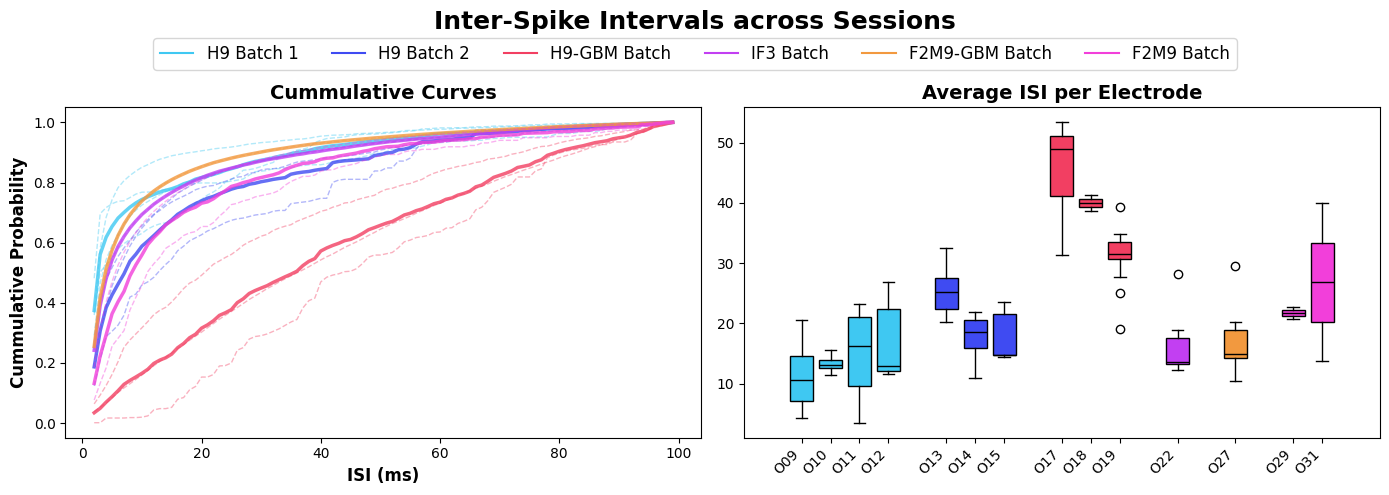

In [69]:
# Plot inter-spike intervals (ISIs) for each organoid (1x2 figure)
# left subplot: cummulative curve of all ISIs for each organoid, groups have different colors, group average curves are bolder than individual organoid curves
# right subplot: box and whisker plot of electrode average ISIs for each organoid, groups have different colors and are seperated along the x-axis

fig, axs = plt.subplots(1, 2, figsize=(len(x_positions), 5))

# left subplot: cummulative curve of all ISIs for each organoid, groups have different colors
ax = axs[0]

for group_name, group_dict in isi_dict.items():

    group_cummulative_isi = []
    for organoid_id, organoid_isi in group_dict.items():
        
        # get ISI histogram for this organoid
        bins = np.arange(min_isi, max_isi + 1, 1)
        isi_hist = np.histogram(np.concatenate(organoid_isi), bins=bins, density=True)[0]

        cummulative_isi = np.cumsum(isi_hist)
        ax.plot(bins[:-1], cummulative_isi, color=group_colors[group_name], alpha=0.4, linewidth=1, linestyle="--")

        group_cummulative_isi.append(cummulative_isi)
    
    # plot group average curve
    if group_cummulative_isi:
        group_avg_cummulative_isi = np.mean(group_cummulative_isi, axis=0)
        ax.plot(bins[:-1], group_avg_cummulative_isi, color=group_colors[group_name], alpha=0.8, linewidth=2.5)

# customize subplot
ax.set_xlabel("ISI (ms)", fontsize=12, fontweight="bold")
ax.set_ylabel("Cummulative Probability", fontsize=12, fontweight="bold")
ax.set_title("Cummulative Curves", fontsize=14, fontweight="bold")

# right subplot: box and whisker plot of electrode average ISIs for each organoid, groups have different colors and are seperated along the x-axis
ax = axs[1]
min_isi_values = 10 # per electrode

for group_name, group_dict in isi_dict.items():
    for organoid_id, organoid_isi in group_dict.items():

        # calculate average ISI per electrode
        avg_isi_per_electrode = [np.mean(isi) for isi in organoid_isi if len(isi) >= min_isi_values]

        x_pos = x_positions[organoid_id]
        ax.boxplot(avg_isi_per_electrode, positions=[x_pos], widths=box_width, patch_artist=True,
                   boxprops=dict(facecolor=group_colors[group_name], color='black'),
                   medianprops=dict(color='black'),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'))
        
# customize subplot
ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')
ax.set_title("Average ISI per Electrode", fontsize=14, fontweight="bold")

# customize figure
fig.suptitle("Inter-Spike Intervals across Sessions", fontsize=18, fontweight="bold", y=0.98)
fig.subplots_adjust(hspace=0.25)

for group_name, color in group_colors.items():
    ax.plot([], [], color=color, label=group_name)

fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.94),
           ncol=len(group_colors), fontsize=12)

fig.tight_layout(rect=[0, 0, 1, 0.94])  # leaves top band for suptitle + legend

plt.show()

Population Burst Analysis

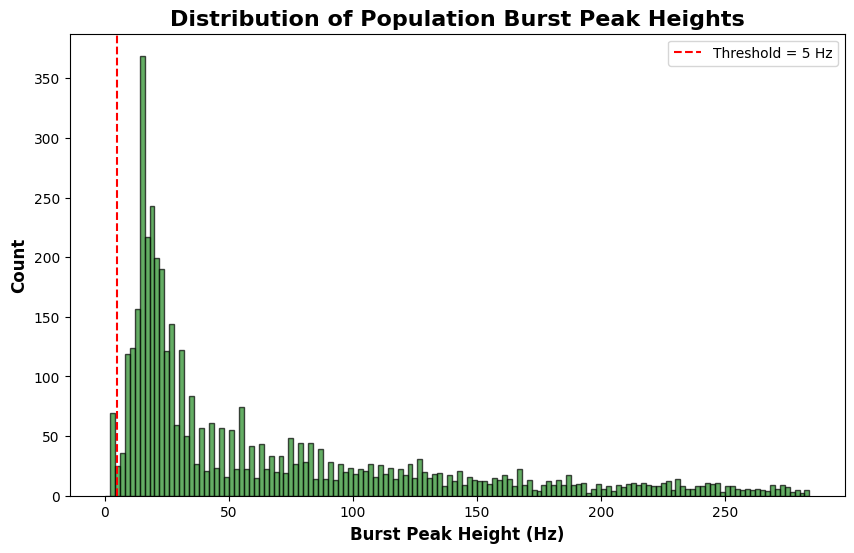

In [70]:
# Determine minimum peak height for population bursts
# Plot histogram of all burs heights across all organoids and groups to determine a reasonable threshold for population bursts.
burst_height_threshold = 5

# fetch burst heights
all_analysis_keys = np.concatenate(list(analysis_keys.values()))
burst_heights = np.concatenate((mua.PopulationBursts & all_analysis_keys).fetch("burst_peak_heights"))

# plot histogram of burst heights
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.arange(0, np.percentile(burst_heights, 95), 2)
ax.hist(burst_heights, bins=bins, color="forestgreen", alpha=0.7, edgecolor="black")
ax.axvline(burst_height_threshold, color="red", linestyle="--", label=f"Threshold = {burst_height_threshold} Hz")

ax.set_xlabel("Burst Peak Height (Hz)", fontsize=12, fontweight="bold")
ax.set_ylabel("Count", fontsize=12, fontweight="bold")
ax.set_title("Distribution of Population Burst Peak Heights", fontsize=16, fontweight="bold")
ax.legend()

plt.show()

In [71]:
max_burst_interval = 60 # seconds

In [72]:
# Get burst metrics for each organoid and group, applying the burst height threshold to determine which bursts are considered population bursts.
burst_metrics_dict = {
    "Rate (bursts/min)": {},
    "Inter-burst Interval (s)": {},
    "Peak Height (Hz)": {},
    "Duration (ms)": {},
    "% Active Electrodes": {},
    "Correlation (weighted sttc)": {}
}

for group_name, keys in analysis_keys.items():

    # initialize dicts for this group
    for metric in burst_metrics_dict.keys():
        burst_metrics_dict[metric][group_name] = {}

    # fetch burst metrics
    organoid_ids, start_times, end_times, burst_indices, burst_peak_heights, burst_bounds, burst_spike_arrays, burst_weighted_sttc = (
        mua.PopulationBursts & keys
        ).fetch("organoid_id", "start_time", "end_time", "burst_indices", "burst_peak_heights", "burst_bounds", "burst_spike_array", "weighted_sttc")
    
    for organoid_id in analysis_organoids_dict[group_name]:
        organoid_mask = organoid_ids == organoid_id
        num_elec_inside = (culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")

        # ensure there are the expected number of data values
        if sum(organoid_mask) != num_sessions_dict[group_name][organoid_id]:
            raise ValueError(f"Expected {num_sessions_dict[group_name][organoid_id]} data points for organoid {organoid_id} but found {sum(organoid_mask)}")
        
        # get burst rate and inter-burst interval (needs to be done on a per sesson basis before concatenating across sessions)
        organoid_burst_rates = []
        organoid_ibis = []
        for session_indices, session_peak_heights, start_time, end_time in zip(
            burst_indices[organoid_mask], burst_peak_heights[organoid_mask], start_times[organoid_mask], end_times[organoid_mask]):

            # burst rate
            session_duration_min = (end_time - start_time).total_seconds() / 60
            organoid_burst_rates.append(np.sum(session_peak_heights >= burst_height_threshold) / session_duration_min)

            # inter-burst interval
            session_ibis = np.diff(session_indices[session_peak_heights >= burst_height_threshold]) / 1000 # convert from ms to s
            organoid_ibis.extend(session_ibis[session_ibis <= max_burst_interval]) # only keep ibIs that are less than the max burst interval

        burst_metrics_dict["Rate (bursts/min)"][group_name][organoid_id] = np.mean(organoid_burst_rates)
        burst_metrics_dict["Inter-burst Interval (s)"][group_name][organoid_id] = np.array(organoid_ibis)

        # remove bursts that do not meet the burst height threshold and concatenate data across sessions for this organoid
        valid_burst_mask = np.concatenate(burst_peak_heights[organoid_mask]) >= burst_height_threshold

        organoid_peak_heights = np.concatenate(burst_peak_heights[organoid_mask])[valid_burst_mask]
        organoid_bounds = np.concatenate(burst_bounds[organoid_mask])[valid_burst_mask]
        organoid_spike_arrays = np.concatenate(burst_spike_arrays[organoid_mask])[valid_burst_mask]
        organoid_weighted_sttc = np.concatenate(burst_weighted_sttc[organoid_mask])[valid_burst_mask]

        # store burst metrics for this organoid
        burst_metrics_dict["Peak Height (Hz)"][group_name][organoid_id] = organoid_peak_heights
        burst_metrics_dict["Duration (ms)"][group_name][organoid_id] = np.diff(organoid_bounds, axis=1).flatten()
        burst_metrics_dict["% Active Electrodes"][group_name][organoid_id] = np.sum(np.sum(organoid_spike_arrays, axis=2) > 0, axis=1) / num_elec_inside * 100
        burst_metrics_dict["Correlation (weighted sttc)"][group_name][organoid_id] = organoid_weighted_sttc

In [73]:
# TODO: Read through the "Burst Rates (bursts per min)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using burst_metrics_dict["Rate (bursts/min)"]
# loop through the burst_metrics_dict["Rate (bursts/min)"] using the dictionary keys to fill in the "Organoid ID" column 
# under the "Burst Rate" column, fill in the burst rate value for each organoid
# Each organoid should fill one complete row

# Populate "Burst Rates (bursts per min)" sheet
# Sheet layout (row 1 is the header):
#   Col A: "Organoid ID"
#   Col B: "Burst Rate"
# burst_metrics_dict["Rate (bursts/min)"] structure: {group_name: {organoid_id: scalar}}

wb_br = openpyxl.load_workbook(excel_workbook_path)
ws_br = wb_br["Burst Rates (bursts per min)"]

data_row = 2  # data starts on row 2 (row 1 is the header)
for group_name, group_dict in burst_metrics_dict["Rate (bursts/min)"].items():
    for organoid_id, burst_rate in group_dict.items():
        ws_br.cell(row=data_row, column=1, value=organoid_id)         # Organoid ID
        ws_br.cell(row=data_row, column=2, value=float(burst_rate))   # Burst Rate
        data_row += 1

wb_br.save(excel_workbook_path)
print(f"Saved {data_row - 2} rows to 'Burst Rates (bursts per min)'")

Saved 14 rows to 'Burst Rates (bursts per min)'


In [74]:
# TODO: Read through the "Burst Peak Height (Hz)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using burst_metrics_dict["Peak Height (Hz)"]
# loop through the burst_metrics_dict["Peak Height (Hz)"] using the dictionary keys to fill in the "Organoid ID" column
# the value will be a list of peak heights for each burst (no telling how many bursts there are, so just fill in as many columns as needed)
#   fill in the burst index (under Burst Indices) to indicate which bursts correspond to which peak heights
#   for each burst fill in the corresponding burst height 
# under the "Organoid Average" column, fill in the average burst height across all bursts for each organoid
# Each organoid should fill one complete row

# Populate "Burst Peak Height (Hz)" sheet
# Sheet layout (row 2 is the header):
#   Col A: "Organoid ID"
#   Col B: "Organoid Average"
#   Cols C onward: Burst indices 1, 2, 3, ... (as many as needed)
# burst_metrics_dict["Peak Height (Hz)"] structure: {group_name: {organoid_id: np.array of peak heights}}

wb_bph = openpyxl.load_workbook(excel_workbook_path)
ws_bph = wb_bph["Burst Peak Height (Hz)"]

# Extend burst index header if data has more bursts than existing header columns
max_bursts_ph = max(
    len(heights)
    for group_dict in burst_metrics_dict["Peak Height (Hz)"].values()
    for heights in group_dict.values()
)
existing_ph_cols = ws_bph.max_column - 2  # cols A and B are fixed
for b in range(existing_ph_cols + 1, max_bursts_ph + 1):
    ws_bph.cell(row=2, column=2 + b, value=b)  # extend burst index header (1-based)

data_row = 3  # data starts on row 3
for group_name, group_dict in burst_metrics_dict["Peak Height (Hz)"].items():
    for organoid_id, peak_heights in group_dict.items():
        ws_bph.cell(row=data_row, column=1, value=organoid_id)
        ws_bph.cell(row=data_row, column=2,
                    value=float(np.mean(peak_heights)) if len(peak_heights) > 0 else None)
        for b_idx, height in enumerate(peak_heights):
            ws_bph.cell(row=data_row, column=3 + b_idx, value=float(height))
        data_row += 1

wb_bph.save(excel_workbook_path)
print(f"Saved {data_row - 3} rows to 'Burst Peak Height (Hz)'")

Saved 14 rows to 'Burst Peak Height (Hz)'


In [75]:
# TODO: Read through the "Burst Duration (ms)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using burst_metrics_dict["Duration (ms)"]
# loop through the burst_metrics_dict["Duration (ms)"] using the dictionary keys to fill in the "Organoid ID" column
# the value will be a list of durations for each burst (no telling how many bursts there are, so just fill in as many columns as needed)
#   fill in the burst index (under Burst Indices) to indicate which bursts correspond to which durations
#   for each burst fill in the corresponding burst duration 
# under the "Organoid Average" column, fill in the average burst duration across all bursts for each organoid
# Each organoid should fill one complete row

# Populate "Burst Duration (ms)" sheet
# Same layout as Burst Peak Height: Col A = Organoid ID, Col B = Organoid Average, Cols C+ = burst values (1-indexed)
# burst_metrics_dict["Duration (ms)"] structure: {group_name: {organoid_id: np.array of durations}}

wb_bd = openpyxl.load_workbook(excel_workbook_path)
ws_bd = wb_bd["Burst Duration (ms)"]

max_bursts_dur = max(
    len(durations)
    for group_dict in burst_metrics_dict["Duration (ms)"].values()
    for durations in group_dict.values()
)
existing_dur_cols = ws_bd.max_column - 2
for b in range(existing_dur_cols + 1, max_bursts_dur + 1):
    ws_bd.cell(row=2, column=2 + b, value=b)

data_row = 3
for group_name, group_dict in burst_metrics_dict["Duration (ms)"].items():
    for organoid_id, durations in group_dict.items():
        ws_bd.cell(row=data_row, column=1, value=organoid_id)
        ws_bd.cell(row=data_row, column=2,
                   value=float(np.mean(durations)) if len(durations) > 0 else None)
        for b_idx, dur in enumerate(durations):
            ws_bd.cell(row=data_row, column=3 + b_idx, value=float(dur))
        data_row += 1

wb_bd.save(excel_workbook_path)
print(f"Saved {data_row - 3} rows to 'Burst Duration (ms)'")

Saved 14 rows to 'Burst Duration (ms)'


In [76]:
# TODO: Read through the "Electrodes with Burst Spike (%)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using burst_metrics_dict["Electrodes with Burst Spike (%)"]
# loop through the burst_metrics_dict["% Active Electrodes"] using the dictionary keys to fill in the "Organoid ID" column
# the value will be a list of percentages for each burst (no telling how many bursts there are, so just fill in as many columns as needed)
#   fill in the burst index (under Burst Indices) to indicate which bursts correspond to which percentages
#   for each burst fill in the corresponding percentage 
# under the "Organoid Average" column, fill in the average percentage across all bursts for each organoid
# Each organoid should fill one complete row

# Populate "Electrodes with Burst Spike (%)" sheet
# Same layout: Col A = Organoid ID, Col B = Organoid Average, Cols C+ = burst values (1-indexed)
# burst_metrics_dict["% Active Electrodes"] structure: {group_name: {organoid_id: np.array of percentages}}

wb_ae = openpyxl.load_workbook(excel_workbook_path)
ws_ae = wb_ae["Electrodes with Burst Spike (%)"]

max_bursts_ae = max(
    len(pcts)
    for group_dict in burst_metrics_dict["% Active Electrodes"].values()
    for pcts in group_dict.values()
)
existing_ae_cols = ws_ae.max_column - 2
for b in range(existing_ae_cols + 1, max_bursts_ae + 1):
    ws_ae.cell(row=2, column=2 + b, value=b)

data_row = 3
for group_name, group_dict in burst_metrics_dict["% Active Electrodes"].items():
    for organoid_id, pcts in group_dict.items():
        ws_ae.cell(row=data_row, column=1, value=organoid_id)
        ws_ae.cell(row=data_row, column=2,
                   value=float(np.mean(pcts)) if len(pcts) > 0 else None)
        for b_idx, pct in enumerate(pcts):
            ws_ae.cell(row=data_row, column=3 + b_idx, value=float(pct))
        data_row += 1

wb_ae.save(excel_workbook_path)
print(f"Saved {data_row - 3} rows to 'Electrodes with Burst Spike (%)'")

Saved 14 rows to 'Electrodes with Burst Spike (%)'


In [77]:
# TODO: Read through the "Burst Correlation (STTC)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using burst_metrics_dict["Burst Correlation (STTC)"]
# loop through the burst_metrics_dict["Correlation (weighted sttc)"] using the dictionary keys to fill in the "Organoid ID" column
# the value will be a list of correlation values for each burst (no telling how many bursts there are, so just fill in as many columns as needed)
#   fill in the burst index (under Burst Indices) to indicate which bursts correspond to which correlation values
#   for each burst fill in the corresponding correlation value
# under the "Organoid Average" column, fill in the average correlation value across all bursts for each organoid
# Each organoid should fill one complete row

# Populate "Burst Correlation (STTC)" sheet
# Same layout: Col A = Organoid ID, Col B = Organoid Average, Cols C+ = burst values (1-indexed)
# burst_metrics_dict["Correlation (weighted sttc)"] structure: {group_name: {organoid_id: np.array of sttc values}}

wb_sttc = openpyxl.load_workbook(excel_workbook_path)
ws_sttc = wb_sttc["Burst Correlation (STTC)"]

max_bursts_sttc = max(
    len(corrs)
    for group_dict in burst_metrics_dict["Correlation (weighted sttc)"].values()
    for corrs in group_dict.values()
)
existing_sttc_cols = ws_sttc.max_column - 2
for b in range(existing_sttc_cols + 1, max_bursts_sttc + 1):
    ws_sttc.cell(row=2, column=2 + b, value=b)

data_row = 3
for group_name, group_dict in burst_metrics_dict["Correlation (weighted sttc)"].items():
    for organoid_id, corrs in group_dict.items():
        ws_sttc.cell(row=data_row, column=1, value=organoid_id)
        ws_sttc.cell(row=data_row, column=2,
                     value=float(np.mean(corrs)) if len(corrs) > 0 else None)
        for b_idx, corr in enumerate(corrs):
            ws_sttc.cell(row=data_row, column=3 + b_idx, value=float(corr))
        data_row += 1

wb_sttc.save(excel_workbook_path)
print(f"Saved {data_row - 3} rows to 'Burst Correlation (STTC)'")

Saved 14 rows to 'Burst Correlation (STTC)'


In [78]:
# TODO: Read through the "Inter-Burst Interval (s)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using burst_metrics_dict["Inter-Burst Interval (s)"]
# loop through the burst_metrics_dict["Inter-Burst Interval (s)"] using the dictionary keys to fill in the "Organoid ID" column
# the value will be a list of inter-burst intervals for each burst (no telling how many bursts there are, so just fill in as many columns as needed)
#   fill in the burst index (under Burst Indices) to indicate which bursts correspond to which inter-burst intervals
#   for each burst fill in the corresponding inter-burst interval
# under the "Organoid Average" column, fill in the average inter-burst interval across all bursts for each organoid
# Each organoid should fill one complete row

# Populate "Inter-Burst Intervals (s)" sheet
# Same layout: Col A = Organoid ID, Col B = Organoid Average, Cols C+ = IBI values (1-indexed)
# burst_metrics_dict["Inter-burst Interval (s)"] structure: {group_name: {organoid_id: np.array of IBIs}}

wb_ibi = openpyxl.load_workbook(excel_workbook_path)
ws_ibi = wb_ibi["Inter-Burst Intervals (s)"]

max_bursts_ibi = max(
    len(ibis)
    for group_dict in burst_metrics_dict["Inter-burst Interval (s)"].values()
    for ibis in group_dict.values()
)
existing_ibi_cols = ws_ibi.max_column - 2
for b in range(existing_ibi_cols + 1, max_bursts_ibi + 1):
    ws_ibi.cell(row=2, column=2 + b, value=b)

data_row = 3
for group_name, group_dict in burst_metrics_dict["Inter-burst Interval (s)"].items():
    for organoid_id, ibis in group_dict.items():
        ws_ibi.cell(row=data_row, column=1, value=organoid_id)
        ws_ibi.cell(row=data_row, column=2,
                    value=float(np.mean(ibis)) if len(ibis) > 0 else None)
        for b_idx, ibi in enumerate(ibis):
            ws_ibi.cell(row=data_row, column=3 + b_idx, value=float(ibi))
        data_row += 1

wb_ibi.save(excel_workbook_path)
print(f"Saved {data_row - 3} rows to 'Inter-Burst Intervals (s)'")

Saved 14 rows to 'Inter-Burst Intervals (s)'


C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_1308\2297369803.py:12: RuntimeWarning:

Mean of empty slice



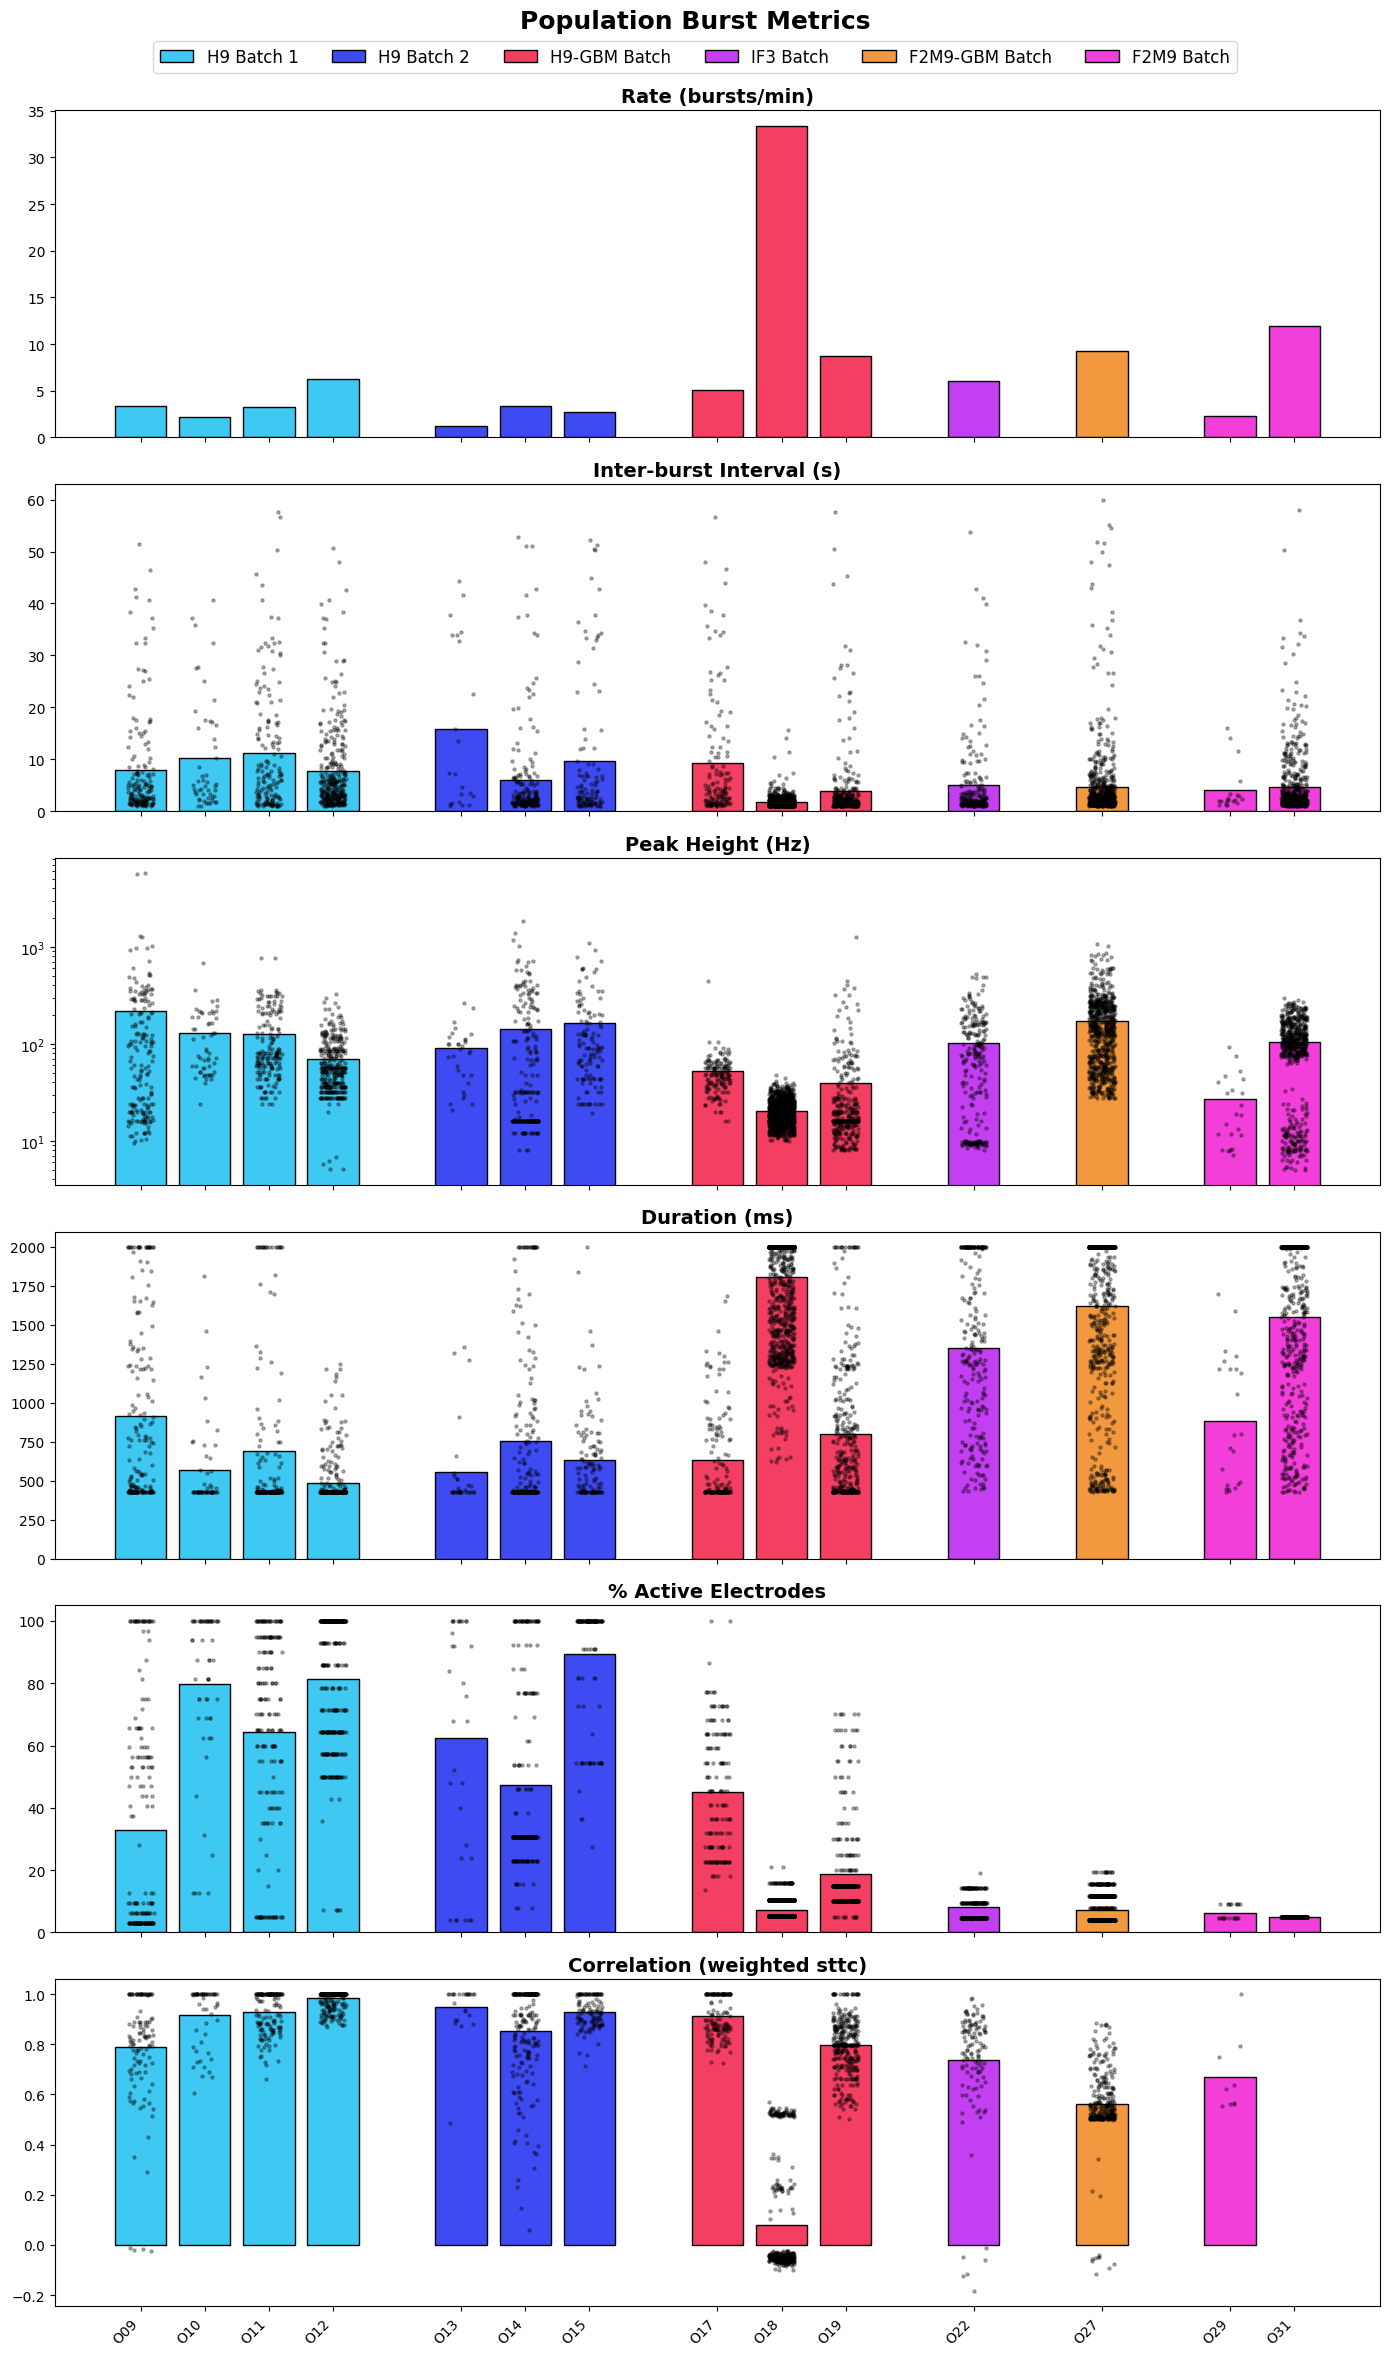

In [79]:
# Plot summary burst metrics for each group (num metrcs x 1 figure)
# Bar plot with height indicating the organoid average with individual data points representing each burst, colored and seperated by group

fig, axs = plt.subplots(len(burst_metrics_dict), 1, figsize=(len(x_positions), 4*len(burst_metrics_dict)), sharex=True)

for i, (metric_name, group_dict) in enumerate(burst_metrics_dict.items()):
    ax = axs[i]

    for group_name, group_dict in group_dict.items():
        organoid_ids = list(group_dict.keys())
        x = [x_positions[organoid_id] for organoid_id in organoid_ids]
        y = [np.nanmean(group_dict[organoid_id]) if isinstance(group_dict[organoid_id], np.ndarray) else group_dict[organoid_id] for organoid_id in organoid_ids]

        # plot bar for mean value
        ax.bar(x, y, color=group_colors[group_name], alpha=1, width=box_width, edgecolor="black", label=group_name)

        # plot individual data points
        for organoid_id in organoid_ids:
            organoid_values = group_dict[organoid_id]
            if isinstance(organoid_values, np.ndarray):
                jitter = (np.random.rand(len(organoid_values)) - 0.5) * box_width * 0.5
                ax.scatter(np.full_like(organoid_values, x_positions[organoid_id], dtype=float) + jitter, organoid_values, color="black", alpha=0.3, s=20, marker=".")

    # customize subplot
    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')
    ax.set_title(metric_name, fontsize=14, fontweight="bold")
    if metric_name == "Peak Height (Hz)":
        ax.set_yscale("log")

# customize figure
fig.suptitle("Population Burst Metrics", fontsize=18, fontweight="bold", y=0.98)
fig.subplots_adjust(hspace=0.25)

legend_elements = [
    Patch(facecolor=color, edgecolor='black', label=group_name)
    for group_name, color in group_colors.items()
]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.97),
           ncol=len(group_colors), fontsize=12)

fig.tight_layout(rect=[0, 0, 1, 0.97])  # leaves top band for suptitle + legend

plt.show()

In [80]:
# Get burst waveforms for each organoid
burst_waveforms_dict = {}

for group_name, keys in analysis_keys.items():
    burst_waveforms_dict[group_name] = {}

    organoid_ids, burst_heights, burst_spike_arrays = (mua.PopulationBursts & keys).fetch("organoid_id", "burst_peak_heights", "burst_spike_array")
    
    for organoid_id in analysis_organoids_dict[group_name]:

        # get valid organoid bursts
        organoid_mask = organoid_ids == organoid_id
        valid_burst_mask = np.concatenate(burst_heights[organoid_mask]) >= burst_height_threshold
        organoid_spike_arrays = np.concatenate(burst_spike_arrays[organoid_mask])[valid_burst_mask]

        # sum electrode spike activity
        population_spikes = np.sum(organoid_spike_arrays, axis=1)

        # find cummulative spike count across each burst
        cummulative_spikes = np.cumsum(population_spikes, axis=1)

        burst_waveforms_dict[group_name][organoid_id] = cummulative_spikes


In [81]:
cummulative_spikes_dict = {}
normalized_cummulative_spikes_dict = {}

num_ms = burst_waveforms_dict[group_name][organoid_id].shape[1]
t = np.arange(-num_ms//2, num_ms//2) / 1000 # convert from ms to s

for group_name, group_dict in burst_waveforms_dict.items():

    for organoid_id, spike_arrays in group_dict.items():

        mean_waveform = np.mean(spike_arrays, axis=0)
        cummulative_spikes_dict[organoid_id] = gaussian_filter(mean_waveform, sigma=20.0, axes=0)

        normalized_waveforms = spike_arrays / np.max(spike_arrays, axis=0, keepdims=True)
        mean_waveform = np.mean(normalized_waveforms, axis=0)
        normalized_cummulative_spikes_dict[organoid_id] = gaussian_filter(mean_waveform, sigma=20.0, axes=0)

C:\Users\Organoid PC\AppData\Local\Temp\ipykernel_1308\2134240580.py:14: RuntimeWarning:

invalid value encountered in divide



In [82]:
# TODO: Read through the "Cummulative Burst Spike Count" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using cummulative_spikes_dict
# loop through the cummulative_spikes_dict using the dictionary keys to fill in the "Organoid ID" column
# the value will be a list of cummulative spike counts corresponding to array "t"
#   for each time point fill in the corresponding cummulative spike count
# each key-value pair should fill one complete row

# Populate "Cummulative Burst Spike Count" sheet
# Sheet layout (row 2 is the header):
#   Col A: "Organoid ID"
#   Cols B onward: time vector values from array t (already pre-filled in row 2)
# cummulative_spikes_dict structure: {organoid_id: np.array of shape (num_timepoints,)}

wb_cbs = openpyxl.load_workbook(excel_workbook_path)
ws_cbs = wb_cbs["Cummulative Burst Spike Count"]

data_row = 3  # data starts on row 3
for organoid_id, cum_spikes in cummulative_spikes_dict.items():
    ws_cbs.cell(row=data_row, column=1, value=organoid_id)          # Organoid ID
    for t_idx, spike_count in enumerate(cum_spikes):                # time-point values
        ws_cbs.cell(row=data_row, column=2 + t_idx, value=float(spike_count))
    data_row += 1

wb_cbs.save(excel_workbook_path)
print(f"Saved {data_row - 3} rows to 'Cummulative Burst Spike Count'")

Saved 14 rows to 'Cummulative Burst Spike Count'


In [83]:
# TODO: Read through the "Norm. Cum. Burst Spike Count" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using normalized_cummulative_spikes_dict
# loop through the normalized_cummulative_spikes_dict using the dictionary keys to fill in the "Organoid ID" column
# the value will be a list of normalized cummulative spike counts corresponding to array "t"
#   for each time point fill in the corresponding normalized cummulative spike count
# each key-value pair should fill one complete row

# Populate "Norm. Cum. Burst Spike Count" sheet
# Identical layout to "Cummulative Burst Spike Count":
#   Col A: "Organoid ID", Cols B onward: time vector values
# normalized_cummulative_spikes_dict structure: {organoid_id: np.array of shape (num_timepoints,)}

wb_ncbs = openpyxl.load_workbook(excel_workbook_path)
ws_ncbs = wb_ncbs["Norm. Cum. Burst Spike Count"]

data_row = 3
for organoid_id, norm_cum_spikes in normalized_cummulative_spikes_dict.items():
    ws_ncbs.cell(row=data_row, column=1, value=organoid_id)
    for t_idx, spike_count in enumerate(norm_cum_spikes):
        ws_ncbs.cell(row=data_row, column=2 + t_idx, value=float(spike_count))
    data_row += 1

wb_ncbs.save(excel_workbook_path)
print(f"Saved {data_row - 3} rows to 'Norm. Cum. Burst Spike Count'")

Saved 14 rows to 'Norm. Cum. Burst Spike Count'


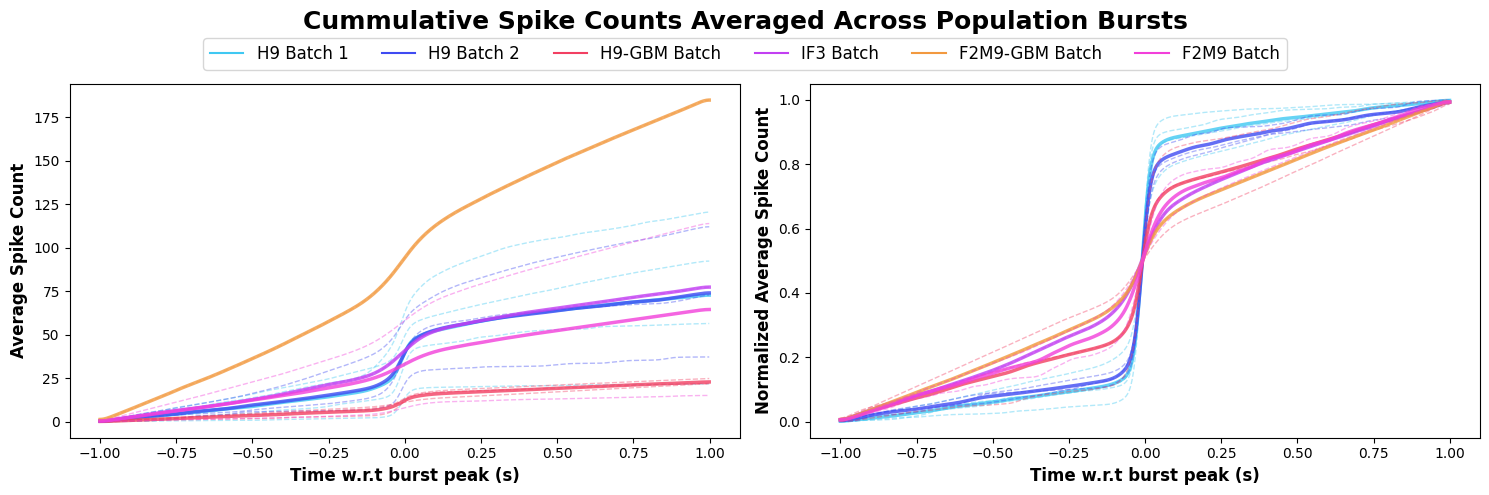

In [84]:
# Plot cummulative burst behavior (1 x 2 figure)
# left plot: line plot of average cummulative spike count across bursts for each organoid, colored by group, group average curves are bolder than individual organoid curves

fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

num_ms = burst_waveforms_dict[group_name][organoid_id].shape[1]
t = np.arange(-num_ms//2, num_ms//2) / 1000 # convert from ms to s

# left subplot: line plot of average cummulative spike count across bursts for each organoid, colored by group
ax = axs[0]

for group_name, group_dict in burst_waveforms_dict.items():

    group_waveforms = []
    for organoid_id, cummulative_spikes in group_dict.items():

        mean_waveform = np.mean(cummulative_spikes, axis=0)
        mean_waveform = gaussian_filter(mean_waveform, sigma=20.0, axes=0)

        ax.plot(t, mean_waveform, color=group_colors[group_name], alpha=0.4, linewidth=1, linestyle="--")

        group_waveforms.append(mean_waveform)
    
    # plot group average curve
    group_avg_waveform = np.mean(group_waveforms, axis=0)
    ax.plot(t, group_avg_waveform, color=group_colors[group_name], alpha=0.8, linewidth=2.5)


# customize subplot
ax.set_xlabel("Time w.r.t burst peak (s)", fontsize=12, fontweight="bold")
ax.set_ylabel("Average Spike Count", fontsize=12, fontweight="bold")

# right subplot: line plot of individual burst waveforms for each organoid, colored by group
ax = axs[1]

for group_name, group_dict in burst_waveforms_dict.items():
    
    group_waveforms = []
    for organoid_id, cummulative_spikes in group_dict.items():

        normalized_cummulative_spikes = cummulative_spikes / np.max(cummulative_spikes, axis=1, keepdims=True)
        mean_waveform = np.mean(normalized_cummulative_spikes, axis=0)
        mean_waveform = gaussian_filter(mean_waveform, sigma=20.0, axes=0)

        ax.plot(t, mean_waveform, color=group_colors[group_name], alpha=0.4, linewidth=1, linestyle="--")

        group_waveforms.append(mean_waveform)
    
    # plot group average curve
    group_avg_waveform = np.mean(group_waveforms, axis=0)
    ax.plot(t, group_avg_waveform, color=group_colors[group_name], alpha=0.8, linewidth=2.5)

# customize subplot
ax.set_xlabel("Time w.r.t burst peak (s)", fontsize=12, fontweight="bold")
ax.set_ylabel("Normalized Average Spike Count", fontsize=12, fontweight="bold")

# customize figure
fig.suptitle("Cummulative Spike Counts Averaged Across Population Bursts", fontsize=18, fontweight="bold", y=0.98)
fig.subplots_adjust(hspace=0.25)

for group_name, color in group_colors.items():
    ax.plot([], [], color=color, label=group_name)

fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.94),
           ncol=len(group_colors), fontsize=12)

fig.tight_layout(rect=[0, 0, 1, 0.94])  # leaves top band for suptitle + legend

plt.show()

Standard Spectral Analysis

In [85]:
#  Get PSD data
psd_dict = {}

# get time and frequency vectors
time, frequency = (analysis.LFPSpectrogram.ChannelSpectrogram & key & "electrode = 0").fetch1("time", "frequency")
freq_mask = (frequency >= min_freq) & (frequency <= max_freq)
lfp_frequency = frequency[freq_mask]

for group_name, keys in analysis_keys.items():
    psd_dict[group_name] = {}

    # get spectrogram keys
    spectrogram_keys = []
    for organoid_id in analysis_organoids_dict[group_name]:
        num_elec_inside = (culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")
        spectrogram_keys.extend((analysis.LFPSpectrogram & keys & f"organoid_id = '{organoid_id}'" & f"electrode < {num_elec_inside}").fetch("KEY"))
    
    # fetch spectrogram data for this group
    print(f"Fetching {group_name} spectrograms...")
    organoid_ids, electrode_indices, spectrograms = (analysis.LFPSpectrogram.ChannelSpectrogram & spectrogram_keys).fetch("organoid_id", "electrode", "spectrogram")

    # convert spectrograms to PSDs (average across time) and stack into array
    psd_array = np.array([np.mean(spectrogram[freq_mask, :], axis=1) for spectrogram in spectrograms]) # shape (num_electrodes*num_sessions, num_freqs)

    for organoid_id in analysis_organoids_dict[group_name]:
        organoid_mask = organoid_ids == organoid_id
        num_elec_inside = (culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")

        organoid_psd = []
        for elec in range(num_elec_inside):
            elec_mask = electrode_indices == elec

            # ensure there are the expected number of data values
            if sum(organoid_mask & elec_mask) != num_sessions_dict[group_name][organoid_id]:
                raise ValueError(f"Expected {num_sessions_dict[group_name][organoid_id]} data points for organoid {organoid_id} and electrode {elec} but found {sum(organoid_mask & elec_mask)}")

            # average spectrograms across sessions (per electrode)
            organoid_psd.append(np.mean(psd_array[organoid_mask & elec_mask, :], axis=0))

        psd_dict[group_name][organoid_id] = np.array(organoid_psd) # shape (num_electrodes, num_freqs)

Fetching H9 Batch 1 spectrograms...


KeyboardInterrupt: 

In [86]:
# Get power band data
power_band_dict = {}

for group_name, keys in analysis_keys.items():
    power_band_dict[group_name] = {
        band_name: {}
        for band_name in frequency_bands.keys()
    }

    # fetch power band data for this group
    organoid_ids, electrode_indices, band_names, band_powers = (analysis.LFPSpectrogram.ChannelPower & keys).fetch("organoid_id", "electrode", "band_name", "mean_power")

    for organoid_id in analysis_organoids_dict[group_name]:
        organoid_mask = organoid_ids == organoid_id
        num_elec_inside = (culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")

        for band_name in frequency_bands.keys():
            band_mask = band_names == band_name

            band_data = []
            for elec in range(num_elec_inside):
                elec_mask = electrode_indices == elec
                # ensure there are the expected number of data values
                if sum(organoid_mask & elec_mask & band_mask) != num_sessions_dict[group_name][organoid_id]:
                    raise ValueError(f"Expected {num_sessions_dict[group_name][organoid_id]} data points for organoid {organoid_id}, electrode {elec}, and band {band_name} but found {sum(organoid_mask & elec_mask & band_mask)}")

                # average power band values across sessions (per electrode)
                mean_band_power = np.mean(band_powers[organoid_mask & elec_mask & band_mask])
                band_data.append(mean_band_power)
            power_band_dict[group_name][band_name][organoid_id] = np.array(band_data) # shape (num_electrodes,)


In [87]:
# TODO: Read through the "Frequency Band Power (uV^2)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using power_band_dict
# loop through the power_band_dict using the final layer of dictionary keys to fill in the "Organoid ID" column 
# the different frequency bands have different columns (labeled above the "Organoid ID cell")
# adjacent to the frequency band label is "Electrode Average" with the various electrode indices listed below. 
# fill in the average power band value for each electrode under the corresponding electrode index column 
#    if there are less electrodes than number of columns, leave remaining columns blank
# under the "Organoid Average" column, fill in the average power band value across electrodes for each organoid
# Each organoid should fill one complete row (different frequency bands will have different collumns)

# Populate "Frequency Band Power (uV^2)" sheet
# Sheet layout: 7 band blocks side-by-side, each 35 columns wide (col 35 is a blank spacer).
#   Band block start columns (1-based): [1, 36, 71, 106, 141, 176, 211]
#   Block structure:
#     Col 1: "Organoid ID"
#     Col 2: "Organoid Average"
#     Cols 3-34: Electrode indices 0-31
#     Col 35: blank spacer
# power_band_dict structure: {group_name: {band_name: {organoid_id: np.array of shape (num_elec_inside,)}}}

FBP_BAND_START_COLS = [1, 36, 71, 106, 141, 176, 211]
band_name_order = list(frequency_bands.keys())  # ordered band names matching sheet columns

wb_fbp = openpyxl.load_workbook(excel_workbook_path)
ws_fbp = wb_fbp["Frequency Band Power (uV^2)"]

# Track next data row per band block (all blocks stay in sync row-wise)
fbp_data_row = 3  # data starts on row 3

for group_name, group_dict in power_band_dict.items():
    organoid_ids_in_group = list(group_dict[band_name_order[0]].keys())
    for organoid_id in organoid_ids_in_group:
        for b_idx, band_name in enumerate(band_name_order):
            col_offset = FBP_BAND_START_COLS[b_idx]
            electrode_powers = group_dict[band_name][organoid_id]  # shape (num_elec_inside,)
            ws_fbp.cell(row=fbp_data_row, column=col_offset,     value=organoid_id)
            ws_fbp.cell(row=fbp_data_row, column=col_offset + 1, value=float(np.mean(electrode_powers)))
            for elec_idx, power in enumerate(electrode_powers):
                ws_fbp.cell(row=fbp_data_row, column=col_offset + 2 + elec_idx, value=float(power))
        fbp_data_row += 1

wb_fbp.save(excel_workbook_path)
print("Saved 'Frequency Band Power (uV^2)'")

Saved 'Frequency Band Power (uV^2)'


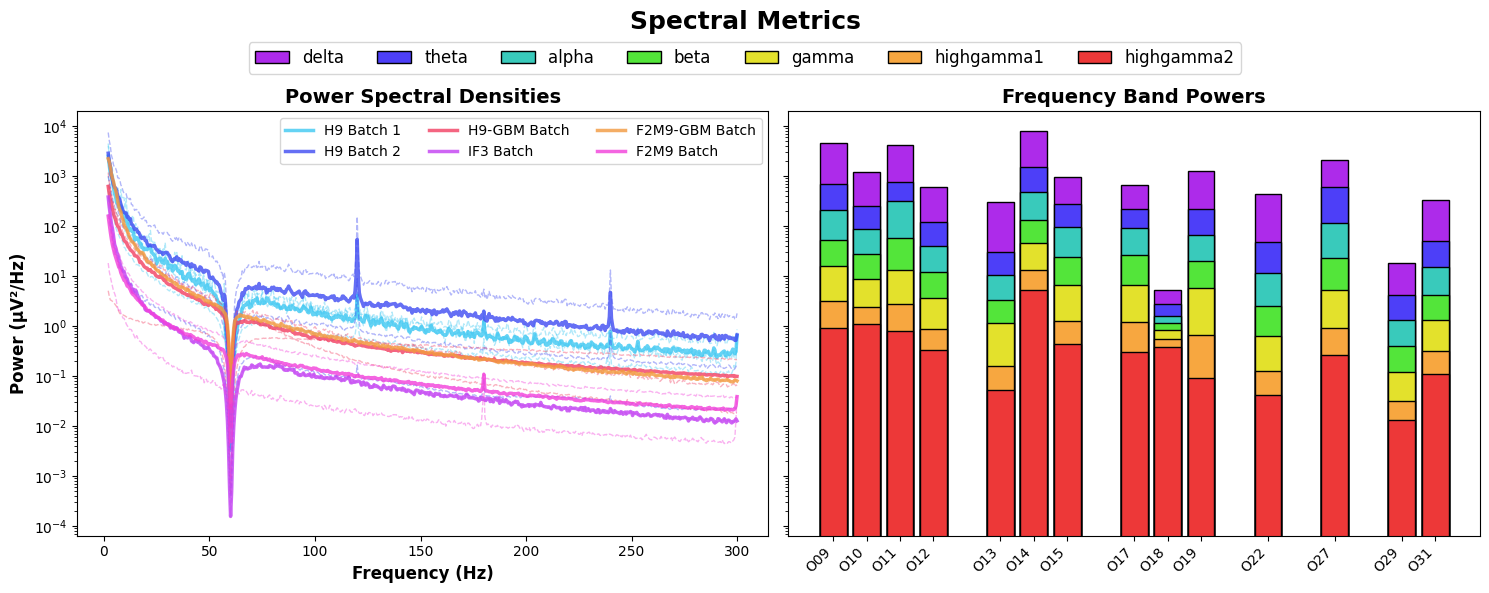

In [ ]:
# Plot summary spectral metrics (1 x 2 figure)
# left plot: line plot of average PSD for each organoid, group average PSDs with bold lines and individual organoid PSDs with transparent lines, colored by group
# right plot: bar plot of power in each frequency band for each group, colored by group

fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# left plot: line plot of average PSD for each organoid, group average PSDs with bold lines and individual organoid PSDs with transparent lines, colored by group
ax = axs[0]

for group_name, group_dict in psd_dict.items():

    for organoid_id, psd in group_dict.items():
        mean_psd = np.mean(psd, axis=0) # average across electrodes
        ax.plot(lfp_frequency, mean_psd, color=group_colors[group_name], alpha=0.4, linewidth=1, linestyle="--")

    # get group average PSD
    group_mean_psd = np.mean([np.mean(psd, axis=0) for psd in group_dict.values()], axis=0)
    ax.plot(lfp_frequency, group_mean_psd, color=group_colors[group_name], alpha=0.8, linewidth=2.5, label=group_name)

# customize subplot
ax.set_xlabel("Frequency (Hz)", fontsize=12, fontweight="bold")
ax.set_ylabel("Power (µV²/Hz)", fontsize=12, fontweight="bold")
ax.set_title("Power Spectral Densities", fontsize=14, fontweight="bold")
ax.set_yscale("log")
ax.legend(loc="upper right", fontsize=10, ncol=min([len(group_colors), 3]))

# right plot: bar plot of power in each frequency band for each group, colored by group, organoid average is represented by individual data points
ax = axs[1]

for group_name, group_dict in power_band_dict.items():

    for band_name, band_dict in group_dict.items():
        organoid_ids = list(band_dict.keys())
        x = [x_positions[organoid_id] for organoid_id in organoid_ids]
        y = [np.mean(band_dict[organoid_id]) for organoid_id in organoid_ids]

        # plot bar for mean value
        ax.bar(x, y, color=band_colors[band_name], alpha=1, width=box_width, edgecolor="black", label=band_name)

# customize subplot
ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')
ax.set_title("Frequency Band Powers", fontsize=14, fontweight="bold")

# customize figure
fig.suptitle("Spectral Metrics", fontsize=18, fontweight="bold", y=0.98)
legend_elements = [
    Patch(facecolor=color, edgecolor='black', label=band_name)
    for band_name, color in band_colors.items()
]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.94),
           ncol=len(band_colors), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.94])  # leaves top band for suptitle + legend

plt.show()

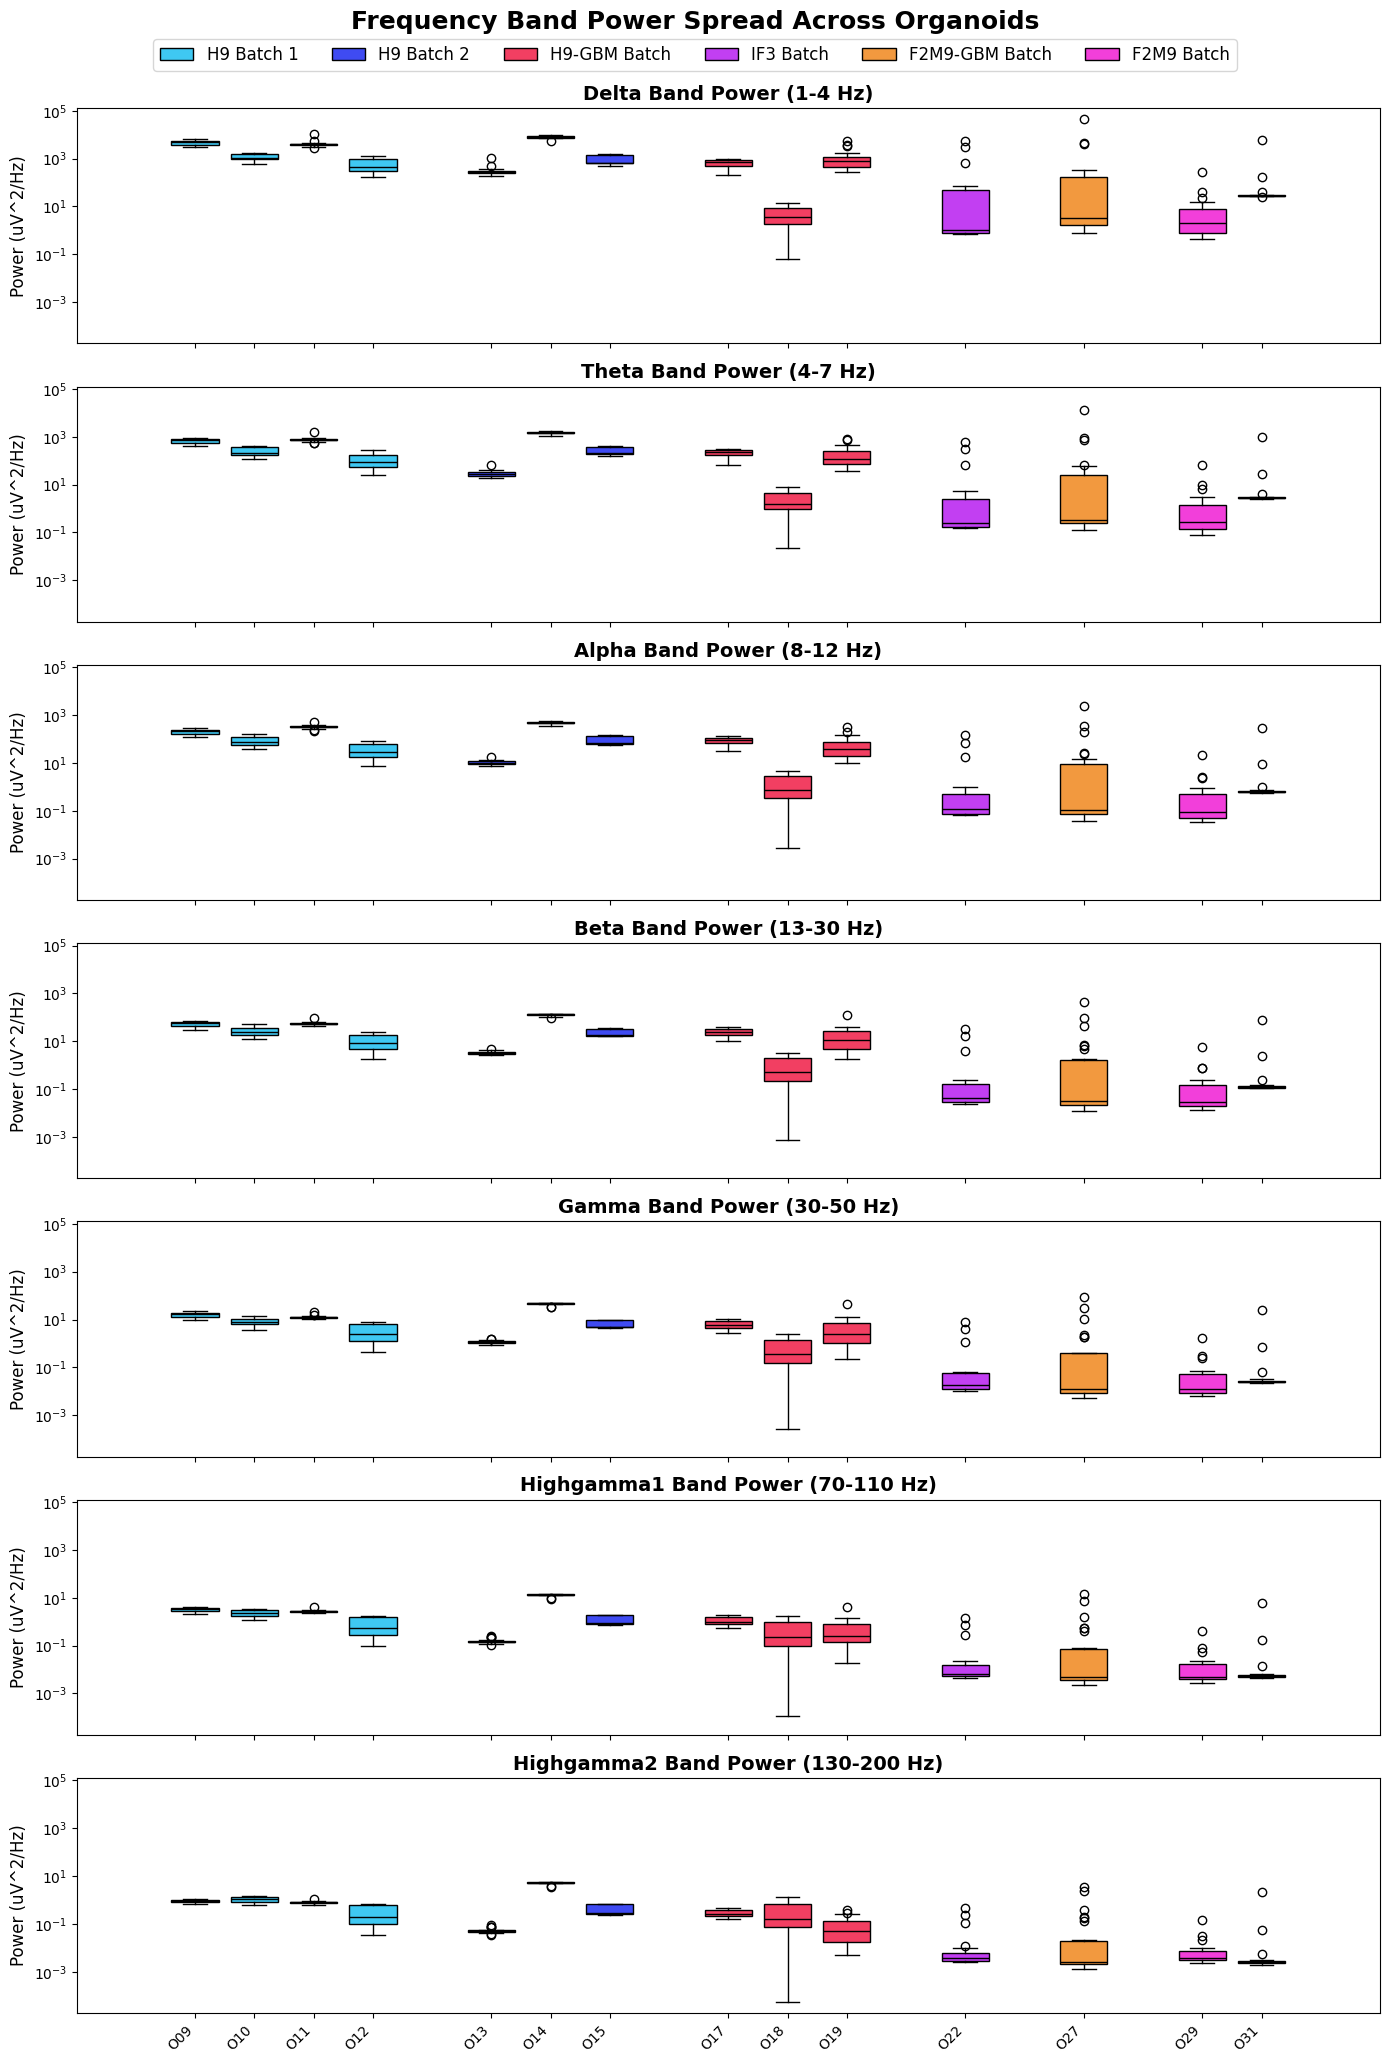

In [88]:
# Plot frequency band power spread for each organoid (num bands x 1 figure)
# Box and whisker subplot for each frequency band, colored by group, organoids on the x-axis

fig, axs = plt.subplots(len(frequency_bands), 1, figsize=(len(x_positions), 3*len(frequency_bands)), sharex=True, sharey=True)

for i, (band_name, (lower_freq, upper_freq)) in enumerate(frequency_bands.items()):
    ax = axs[i]

    for group_name, group_dict in power_band_dict.items():

        organoid_ids = list(group_dict[band_name].keys())
        x = [x_positions[organoid_id] for organoid_id in organoid_ids]
        y = [group_dict[band_name][organoid_id] for organoid_id in organoid_ids]

        # plot box and whisker for this band
        ax.boxplot(y, positions=x, widths=box_width, patch_artist=True,
                   boxprops=dict(facecolor=group_colors[group_name], color='black'),
                   medianprops=dict(color='black'),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'))

    # customize subplot
    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')
    ax.set_title(f"{band_name.capitalize()} Band Power ({int(lower_freq)}-{int(upper_freq)} Hz)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Power (uV^2/Hz)", fontsize=12)
    ax.set_yscale("log")

# customize figure
fig.suptitle("Frequency Band Power Spread Across Organoids", fontsize=18, fontweight="bold", y=0.98)
legend_elements = [Patch(facecolor=color, edgecolor='black', label=group_name) for group_name, color in group_colors.items()]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.97),
           ncol=len(group_colors), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])  # leaves top band for suptitle + legend

plt.show()

FOOOF / fBOSC Analysis

In [89]:
fooof_param_idx = 3 # for group electrode analysis

In [90]:
aperiodic_params_dict = {}

for group_name, keys in analysis_keys.items():
    aperiodic_params_dict[group_name] = {
        "offset": {},
        "exponent": {}
    }

    # fetch aperiodic parameters
    organoid_ids, offsets, exponents = (analysis.FOOOFAnalysis & keys & f"fooof_param_idx = {fooof_param_idx}").fetch(
        "organoid_id", "aperiodic_offset", "aperiodic_exponent")
    
    # average aperiodic parameters across time (already averaged across electrodes)
    offsets, exponents = np.array([[np.mean(10**offset), np.mean(exponent)] for offset, exponent in zip(offsets, exponents)]).T

    for organoid_id in analysis_organoids_dict[group_name]:
        organoid_mask = organoid_ids == organoid_id

        # ensure there are the expected number of data values
        if sum(organoid_mask) != num_sessions_dict[group_name][organoid_id]:
            raise ValueError(f"Expected {num_sessions_dict[group_name][organoid_id]} data points for organoid {organoid_id} but found {sum(organoid_mask)}")

        aperiodic_params_dict[group_name]["offset"][organoid_id] = np.mean(offsets[organoid_mask])
        aperiodic_params_dict[group_name]["exponent"][organoid_id] = np.mean(exponents[organoid_mask])

In [91]:
# TODO: Read through the "FOOOF Aperiodic Metrics" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using aperiodic_params_dict
# loop through the aperiodic_params_dict using the final layer of dictionary keys to fill in the "Organoid ID" column
# there are two other columns "Aperiodic Offset (uV^2/Hz)" and "Aperiodic Exponent" 
#   fill them in with the corresponding values from aperiodic_params_dict ("offset and "exponent" keys, respectively)
# Each organoid should fill one complete row

# Populate "FOOOF Aperiodic Metrics" sheet
# Sheet layout (row 1 is the header):
#   Col A: "Organoid ID"  (typo in sheet: "Orgnaoid ID")
#   Col B: "Aperiodic Offset (uV^2/Hz)"
#   Col C: "Aperiodic Exponent"
# aperiodic_params_dict structure: {group_name: {"offset": {organoid_id: scalar}, "exponent": {organoid_id: scalar}}}

wb_fooof = openpyxl.load_workbook(excel_workbook_path)
ws_fooof = wb_fooof["FOOOF Aperiodic Metrics"]

data_row = 2  # data starts on row 2 (row 1 is header)
for group_name, param_dict in aperiodic_params_dict.items():
    organoid_ids_fooof = list(param_dict["offset"].keys())
    for organoid_id in organoid_ids_fooof:
        ws_fooof.cell(row=data_row, column=1, value=organoid_id)
        ws_fooof.cell(row=data_row, column=2, value=float(param_dict["offset"][organoid_id]))
        ws_fooof.cell(row=data_row, column=3, value=float(param_dict["exponent"][organoid_id]))
        data_row += 1

wb_fooof.save(excel_workbook_path)
print(f"Saved {data_row - 2} rows to 'FOOOF Aperiodic Metrics'")

Saved 14 rows to 'FOOOF Aperiodic Metrics'


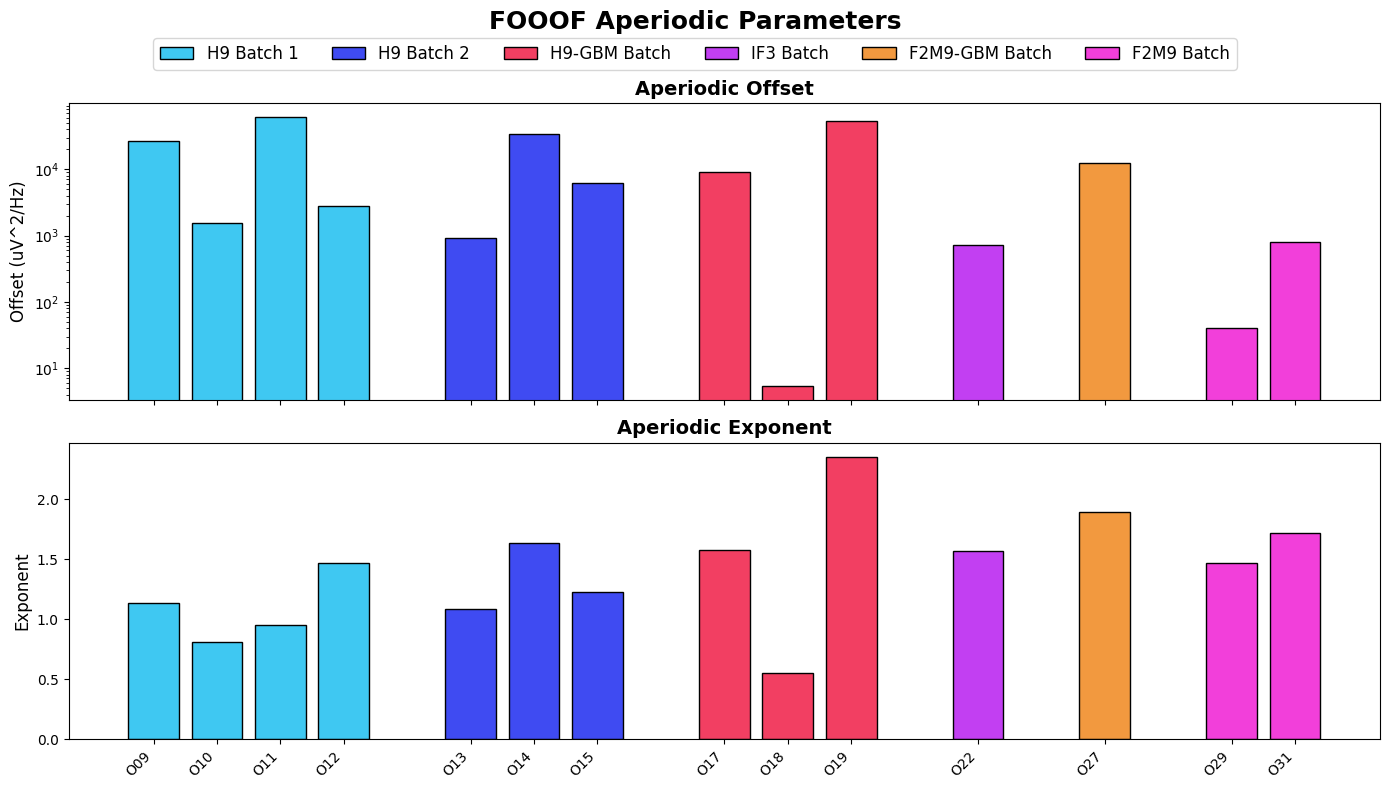

In [92]:
# Plot aperiodic parameters for each organoid (num params x 1 figure)
# Bar plot of each aperiodic parameter, colored by group, organoids on the x-axis

fig, axs = plt.subplots(2, 1, figsize=(len(x_positions), 8), sharex=True)

for i, param_name in enumerate(["offset", "exponent"]):
    ax = axs[i]

    for group_name, group_dict in aperiodic_params_dict.items():

        organoid_ids = list(group_dict[param_name].keys())
        x = [x_positions[organoid_id] for organoid_id in organoid_ids]
        y = [group_dict[param_name][organoid_id] for organoid_id in organoid_ids]

        # plot bar for mean value
        ax.bar(x, y, color=group_colors[group_name], alpha=1, width=box_width, edgecolor="black", label=group_name)

    # customize subplot
    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')
    ax.set_title(f"Aperiodic {param_name.capitalize()}", fontsize=14, fontweight="bold")
    if param_name == "offset":
        ax.set_yscale("log")
axs[0].set_ylabel("Offset (uV^2/Hz)", fontsize=12)
axs[1].set_ylabel("Exponent", fontsize=12)

# customize figure
fig.suptitle("FOOOF Aperiodic Parameters", fontsize=18, fontweight="bold", y=0.98)
legend_elements = [Patch(facecolor=color, edgecolor='black', label=group_name) for group_name, color in group_colors.items()]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.955),
           ncol=len(group_colors), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])  # leaves top band for suptitle + legend

plt.show()

In [93]:
# Get oscillatory burst metrics (fBOSC) for each organoid
oscillatory_metrics_dict = {
    "Burst %": {},
    "Average Burst Amplitude": {}
}


for group_name, keys in analysis_keys.items():
    oscillatory_metrics_dict["Burst %"][group_name] = {}
    oscillatory_metrics_dict["Average Burst Amplitude"][group_name] = {}

    # fetch fBOSC burst metrics
    organoid_ids, start_times, end_times, band_names, oscillation_heights, dt_list = (
        analysis.FOOOFAnalysis.FBOSCAnalysis * analysis.FBOSCParamset & keys & f"fooof_param_idx = {fooof_param_idx}"
        ).fetch("organoid_id", "start_time", "end_time", "band_name", "oscillation_heights", "dt")

    for organoid_id in analysis_organoids_dict[group_name]:
        organoid_mask = organoid_ids == organoid_id
        num_elec_inside = (culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")

        oscillatory_metrics_dict["Burst %"][group_name][organoid_id] = {}
        oscillatory_metrics_dict["Average Burst Amplitude"][group_name][organoid_id] = {}

        for band_name in frequency_bands.keys():
            band_mask = band_names == band_name

            # ensure there are the expected number of data values
            if sum(organoid_mask & band_mask) != num_sessions_dict[group_name][organoid_id]:
                raise ValueError(f"Expected {num_sessions_dict[group_name][organoid_id]} data points for organoid {organoid_id} and band {band_name} but found {sum(organoid_mask & band_mask)}")

            burst_percentages = []
            burst_amplitudes = []
            for start_time, end_time, oscillation_height, dt in zip(start_times[organoid_mask & band_mask], end_times[organoid_mask & band_mask], oscillation_heights[organoid_mask & band_mask], dt_list[organoid_mask & band_mask]):

                # get session duration
                session_duration_min = (end_time - start_time).total_seconds()

                if len(oscillation_height) > 0:
                    # calculate burst percentage
                    burst_percentage = (len(oscillation_height) * dt / session_duration_min) * 100
                    burst_percentages.append(burst_percentage)

                    # calculate burst amplitude (average height across all bursts and electrodes)
                    burst_amplitude = np.mean(oscillation_height)
                    burst_amplitudes.append(burst_amplitude)
                else:
                    burst_percentages.append(0)
                    burst_amplitudes.append(0)

            oscillatory_metrics_dict["Burst %"][group_name][organoid_id][band_name] = np.mean(burst_percentages)
            oscillatory_metrics_dict["Average Burst Amplitude"][group_name][organoid_id][band_name] = np.mean(burst_amplitudes)
    

In [94]:
# TODO: Read through the "fBOSC Burst %" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using oscillatory_metrics_dict["Burst %"]
# loop through the oscillatory_metrics_dict["Burst %"] using the 2nd layer of dictionary keys to fill in the "Organoid ID" column (final layer of keys corresponds to frequency bands)
# adjacent to the "Organoid ID" column are columns labeled by frequency band names (e.g. "Delta", "Theta", etc.)
# fill in the burst percentage value for each organoid under the corresponding frequency band column    
# Each organoid should fill one complete row (different frequency bands will have different collumns)

# Populate "fBOSC Burst %" sheet
# Sheet layout (row 2 is the header):
#   Col A: "Organoid ID"
#   Cols B-H: band columns in order:
#     "Delta (1-4 Hz)", "Theta (4-7 Hz)", "Alpha (8-12 Hz)", "Beta (13-30 Hz)",
#     "Gamma (30-50 Hz)", "High Gamma 1 (70-110 Hz)", "High Gamma 2 (130-200 Hz)"
# oscillatory_metrics_dict["Burst %"] structure: {group_name: {organoid_id: {band_name: scalar}}}

FBOSC_BAND_COL_MAP = {
    "delta":      2,
    "theta":      3,
    "alpha":      4,
    "beta":       5,
    "gamma":      6,
    "highgamma1": 7,
    "highgamma2": 8,
}

wb_fbp_pct = openpyxl.load_workbook(excel_workbook_path)
ws_fbp_pct = wb_fbp_pct["fBOSC Burst %"]

data_row = 3  # data starts on row 3 (row 1: section label, row 2: column headers)
for group_name, group_dict in oscillatory_metrics_dict["Burst %"].items():
    for organoid_id, band_dict in group_dict.items():
        ws_fbp_pct.cell(row=data_row, column=1, value=organoid_id)
        for band_name, col_idx in FBOSC_BAND_COL_MAP.items():
            ws_fbp_pct.cell(row=data_row, column=col_idx, value=float(band_dict[band_name]))
        data_row += 1

wb_fbp_pct.save(excel_workbook_path)
print(f"Saved {data_row - 3} rows to 'fBOSC Burst %'")

Saved 14 rows to 'fBOSC Burst %'


In [95]:
# TODO: Read through the "fBOSC Burst Height" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using oscillatory_metrics_dict["Average Burst Amplitude"]
# loop through the oscillatory_metrics_dict["Average Burst Amplitude"] using the 2nd layer of dictionary keys to fill in the "Organoid ID" column (final layer of keys corresponds to frequency bands)
# adjacent to the "Organoid ID" column are columns labeled by frequency band names (e.g. "Delta", "Theta", etc.)
# fill in the average burst amplitude value for each organoid under the corresponding frequency band column    
# Each organoid should fill one complete row (different frequency bands will have different collumns)

# Populate "fBOSC Burst Height" sheet
# Identical column layout to "fBOSC Burst %" (same FBOSC_BAND_COL_MAP applies)
# oscillatory_metrics_dict["Average Burst Amplitude"] structure: {group_name: {organoid_id: {band_name: scalar}}}

wb_fbp_ht = openpyxl.load_workbook(excel_workbook_path)
ws_fbp_ht = wb_fbp_ht["fBOSC Burst Height"]

data_row = 3
for group_name, group_dict in oscillatory_metrics_dict["Average Burst Amplitude"].items():
    for organoid_id, band_dict in group_dict.items():
        ws_fbp_ht.cell(row=data_row, column=1, value=organoid_id)
        for band_name, col_idx in FBOSC_BAND_COL_MAP.items():
            ws_fbp_ht.cell(row=data_row, column=col_idx, value=float(band_dict[band_name]))
        data_row += 1

wb_fbp_ht.save(excel_workbook_path)
print(f"Saved {data_row - 3} rows to 'fBOSC Burst Height'")

Saved 14 rows to 'fBOSC Burst Height'


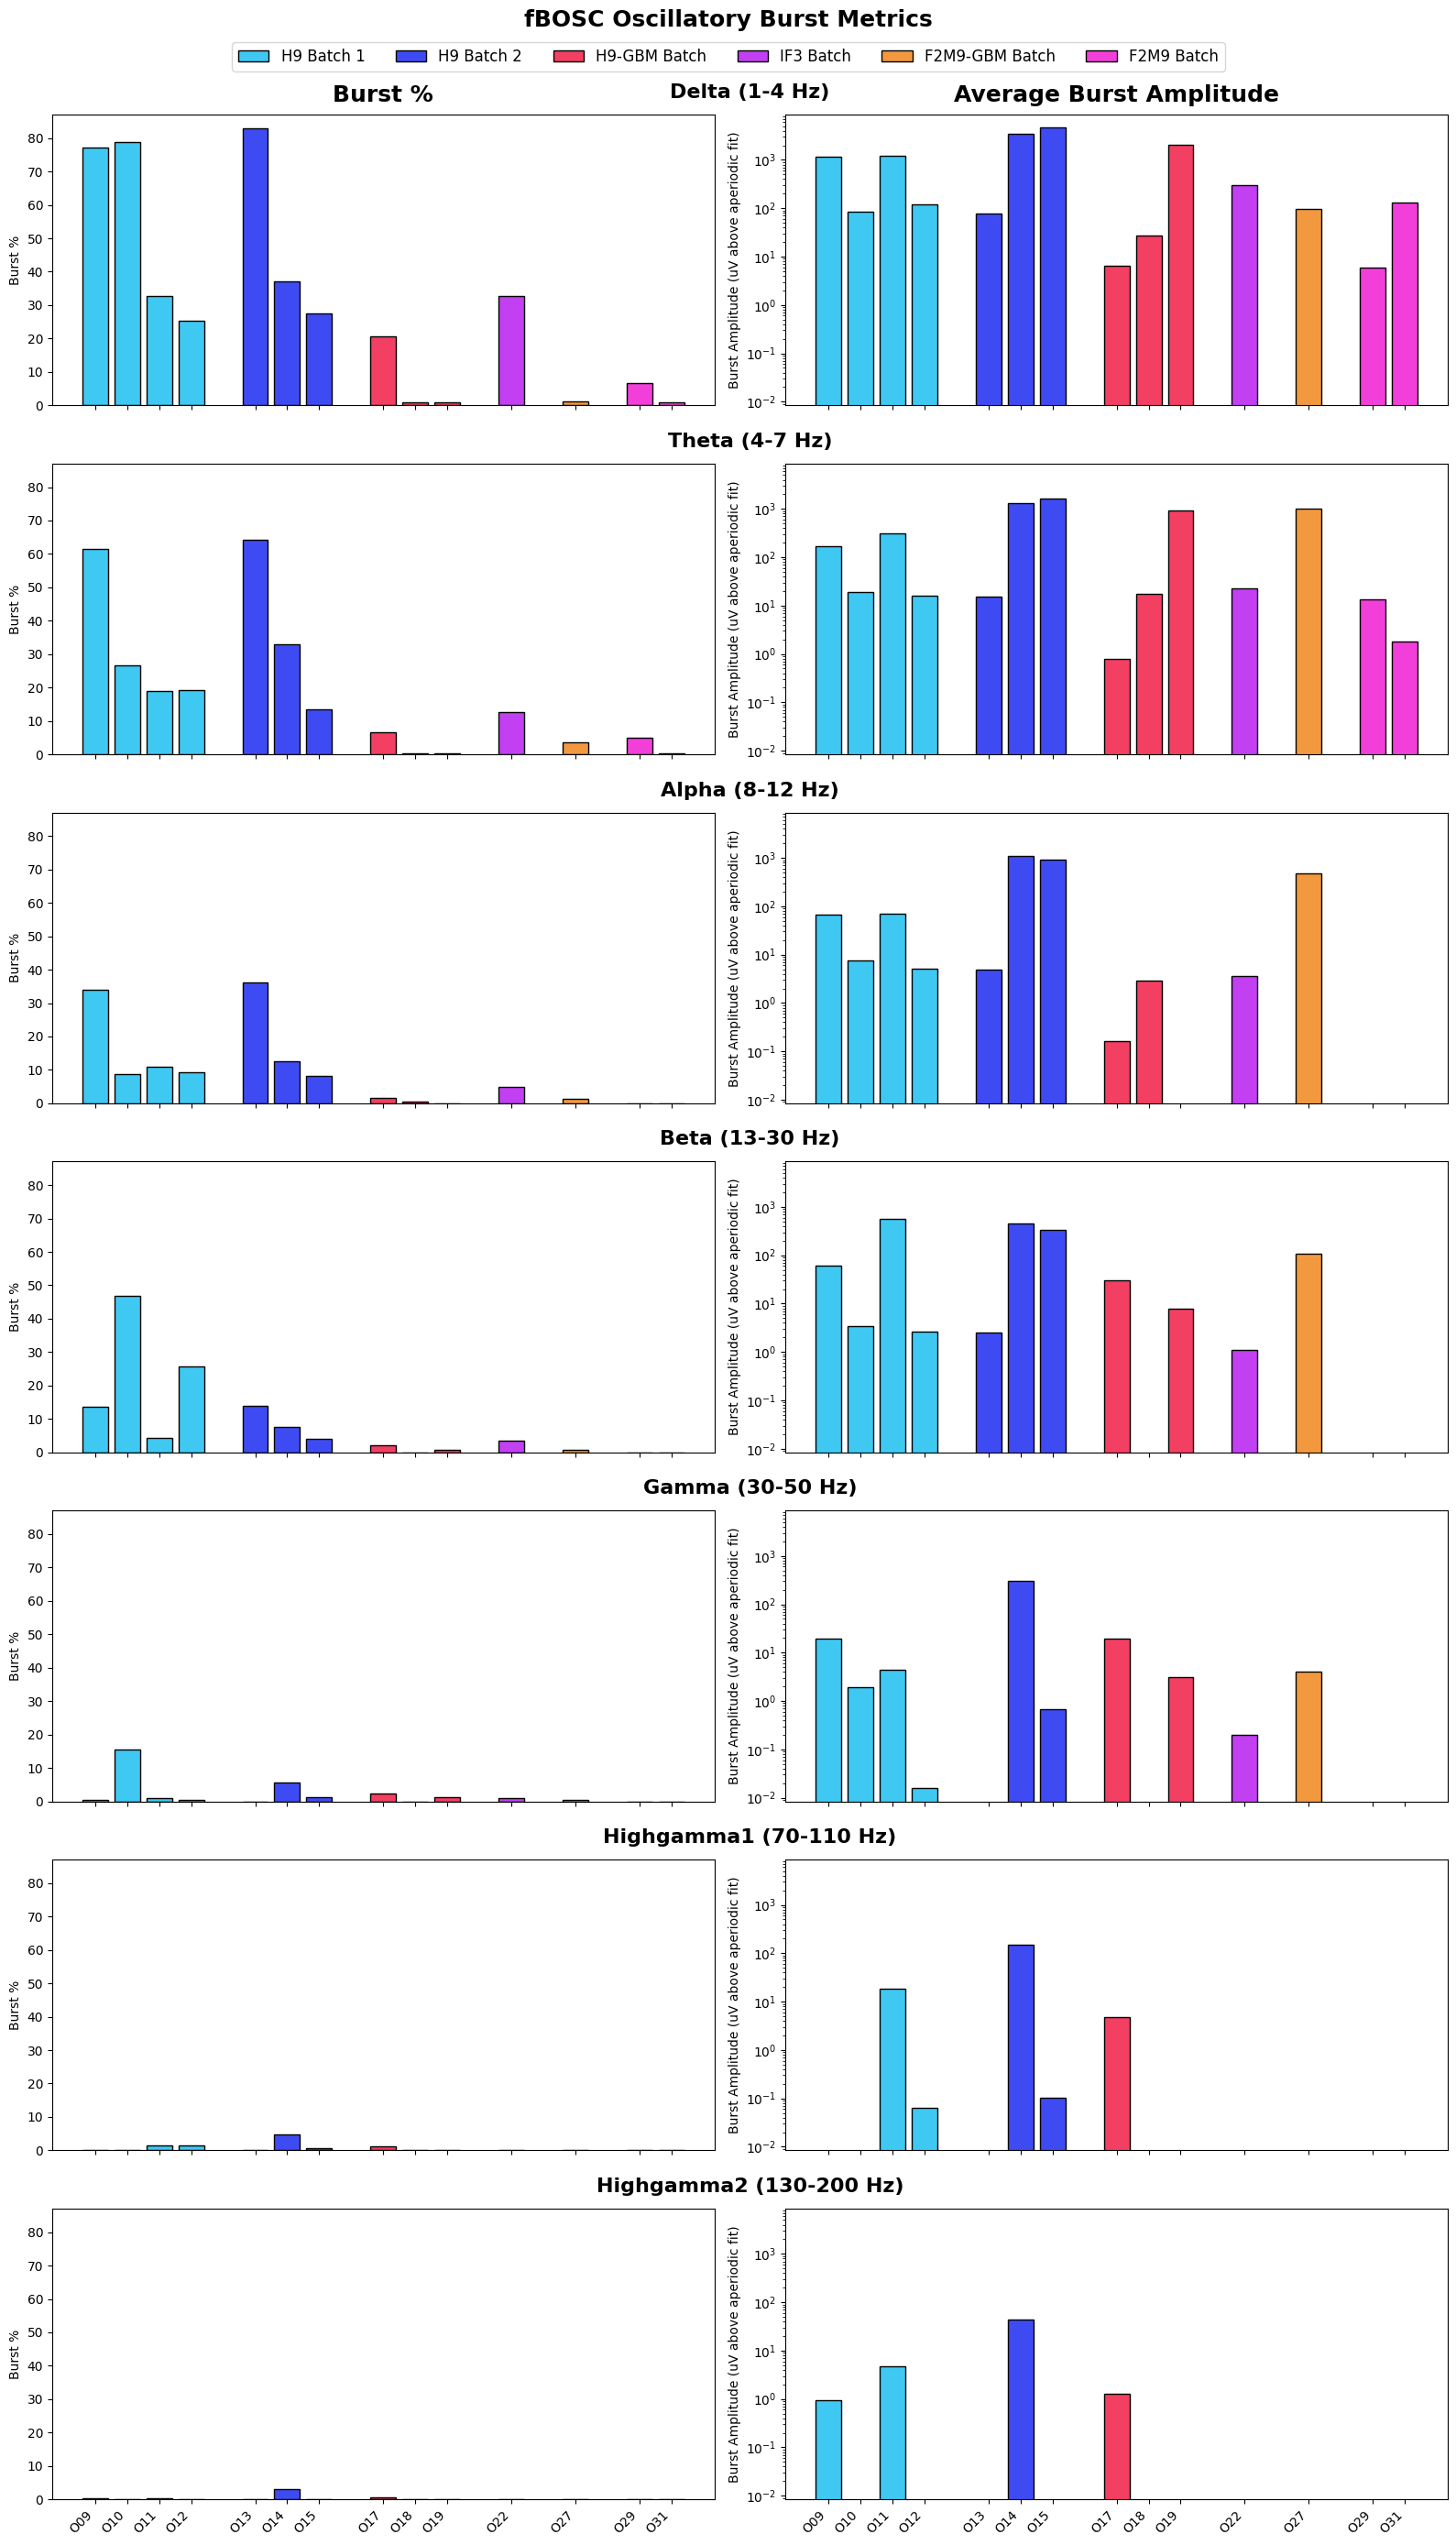

In [96]:
# Plot fBOSC oscillatory burst metrics for each organoid (num bands x num metrics figure)
# Bar plot of each metric, colored by group, organoids on the x-axis

fig, axs = plt.subplots(len(frequency_bands), len(oscillatory_metrics_dict), figsize=(8*len(oscillatory_metrics_dict), 4*len(frequency_bands)), sharex=True, sharey='col')

for i, (band_name, (lower_freq, upper_freq)) in enumerate(frequency_bands.items()):
    for j, (metric_name, metric_dict) in enumerate(oscillatory_metrics_dict.items()):
        ax = axs[i, j]

        for group_name, group_dict in metric_dict.items():

            organoid_ids = list(group_dict.keys())
            x = [x_positions[organoid_id] for organoid_id in organoid_ids]
            y = [group_dict[organoid_id][band_name] for organoid_id in organoid_ids]

            # plot bar for mean value
            ax.bar(x, y, color=group_colors[group_name], alpha=1, width=box_width, edgecolor="black", label=group_name)

        # customize subplot
        ax.set_xticks(list(x_positions.values()))
        ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')
        if metric_name == "Average Burst Amplitude":
            ax.set_yscale("log")
        if j == 0:
            ax.set_ylabel("Burst %", fontsize=10)
        else:
            ax.set_ylabel("Burst Amplitude (uV above aperiodic fit)", fontsize=10)

# customize figure
fig.suptitle("fBOSC Oscillatory Burst Metrics", fontsize=18, fontweight="bold", y=0.99)

legend_elements = [Patch(facecolor=color, edgecolor='black', label=group_name) for group_name, color in group_colors.items()]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.98),
           ncol=len(group_colors), fontsize=12)

# column titles (metric names) above top row
for j, metric_name in enumerate(oscillatory_metrics_dict.keys()):
    axs[0, j].set_title(metric_name, fontsize=18, fontweight="bold", pad=10)

# row titles (band names) centered above each row, between the two columns
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.subplots_adjust(hspace=0.2)  # increase vertical space between rows for band title text

for i, (band_name, (lower_freq, upper_freq)) in enumerate(frequency_bands.items()):
    ax_left = axs[i, 0]
    ax_right = axs[i, -1]
    left_pos = ax_left.get_position()
    right_pos = ax_right.get_position()
    center_x = (left_pos.x0 + right_pos.x1) / 2
    top_y = left_pos.y1  # top edge of the row
    fig.text(center_x, top_y+.005, f"{band_name.capitalize()} ({int(lower_freq)}-{int(upper_freq)} Hz)",
             ha='center', va='bottom', fontsize=16, fontweight='bold',
             rotation=0, transform=fig.transFigure)

plt.show()

In [97]:
# Get aperiodic vs oscillatory balance metric for each organoid (FOOOF fBOSC)
# FIX LATER: THIS DOESN'T ACCOUNT FOR APERIODIC FITS THAT USE A KNEE (ONLY "fixed")
balance_metric_dict = {}

for group_name, keys in analysis_keys.items():
    balance_metric_dict[group_name] = {}

    # fetch FOOOF and fBOSC data to calculate balance metric
    organoid_ids, start_times, end_times, band_names, oscillation_heights, dt_list, offsets, exponents = (
        analysis.FOOOFAnalysis.FBOSCAnalysis * analysis.FOOOFAnalysis * analysis.FBOSCParamset & keys & f"fooof_param_idx = {fooof_param_idx}"
        ).fetch("organoid_id", "start_time", "end_time", "band_name", "oscillation_heights", "dt", "aperiodic_offset", "aperiodic_exponent")
    
    # average aperiodic parameters across time (already averaged across electrodes)
    offsets, exponents = np.array([[np.mean(10**offset), np.mean(exponent)] for offset, exponent in zip(offsets, exponents)]).T    

    for organoid_id in analysis_organoids_dict[group_name]:
        organoid_mask = organoid_ids == organoid_id

        balance_metric_dict[group_name][organoid_id] = {}

        for band_name in frequency_bands.keys():
            band_mask = band_names == band_name

            # ensure there are the expected number of data values
            if sum(organoid_mask & band_mask) != num_sessions_dict[group_name][organoid_id]:
                raise ValueError(f"Expected {num_sessions_dict[group_name][organoid_id]} data points for organoid {organoid_id} and band {band_name} but found {sum(organoid_mask & band_mask)}")

            # calculate burst percentage and average burst amplitude for this organoid and band across sessions (per electrode)
            burst_ratios = []
            burst_amplitudes = []
            for start_time, end_time, oscillation_height, dt, offset, exponent in zip(
                start_times[organoid_mask & band_mask], end_times[organoid_mask & band_mask], oscillation_heights[organoid_mask & band_mask],
                dt_list[organoid_mask & band_mask], offsets[organoid_mask & band_mask], exponents[organoid_mask & band_mask]):

                # get session duration
                session_duration_min = (end_time - start_time).total_seconds()

                if len(oscillation_height) > 0:
                    # calculate burst percentage
                    burst_ratio = (len(oscillation_height) * dt / session_duration_min)
                    burst_ratios.append(burst_ratio)

                    # calculate burst amplitude (average height across all bursts and electrodes)
                    burst_amplitude = np.mean(oscillation_height)
                    burst_amplitudes.append(burst_amplitude)

                else:
                    burst_ratios.append(0)
                    burst_amplitudes.append(0)

            mean_burst_ratio = np.mean(burst_ratios)
            mean_burst_amplitude = np.mean(burst_amplitudes)

            # estimate aperiodic activity level by evaluating the aperiodic fit at the center frequency of the band (geometric mean of lower and upper frequencies)
            center_freq = np.sqrt(frequency_bands[band_name][0] * frequency_bands[band_name][1])
            aperiodic_activity = np.mean(offsets[organoid_mask & band_mask]) / (center_freq ** np.mean(exponents[organoid_mask & band_mask]))

            # calculate balance metric as the ratio of oscillatory activity to total activity (oscillatory + aperiodic)
            # oscillatory activity is estimated as the product of burst ratio and burst amplitude
            oscillatory_activity = mean_burst_amplitude * mean_burst_ratio
            balance_metric = oscillatory_activity / (oscillatory_activity + aperiodic_activity)

            balance_metric_dict[group_name][organoid_id][band_name] = balance_metric


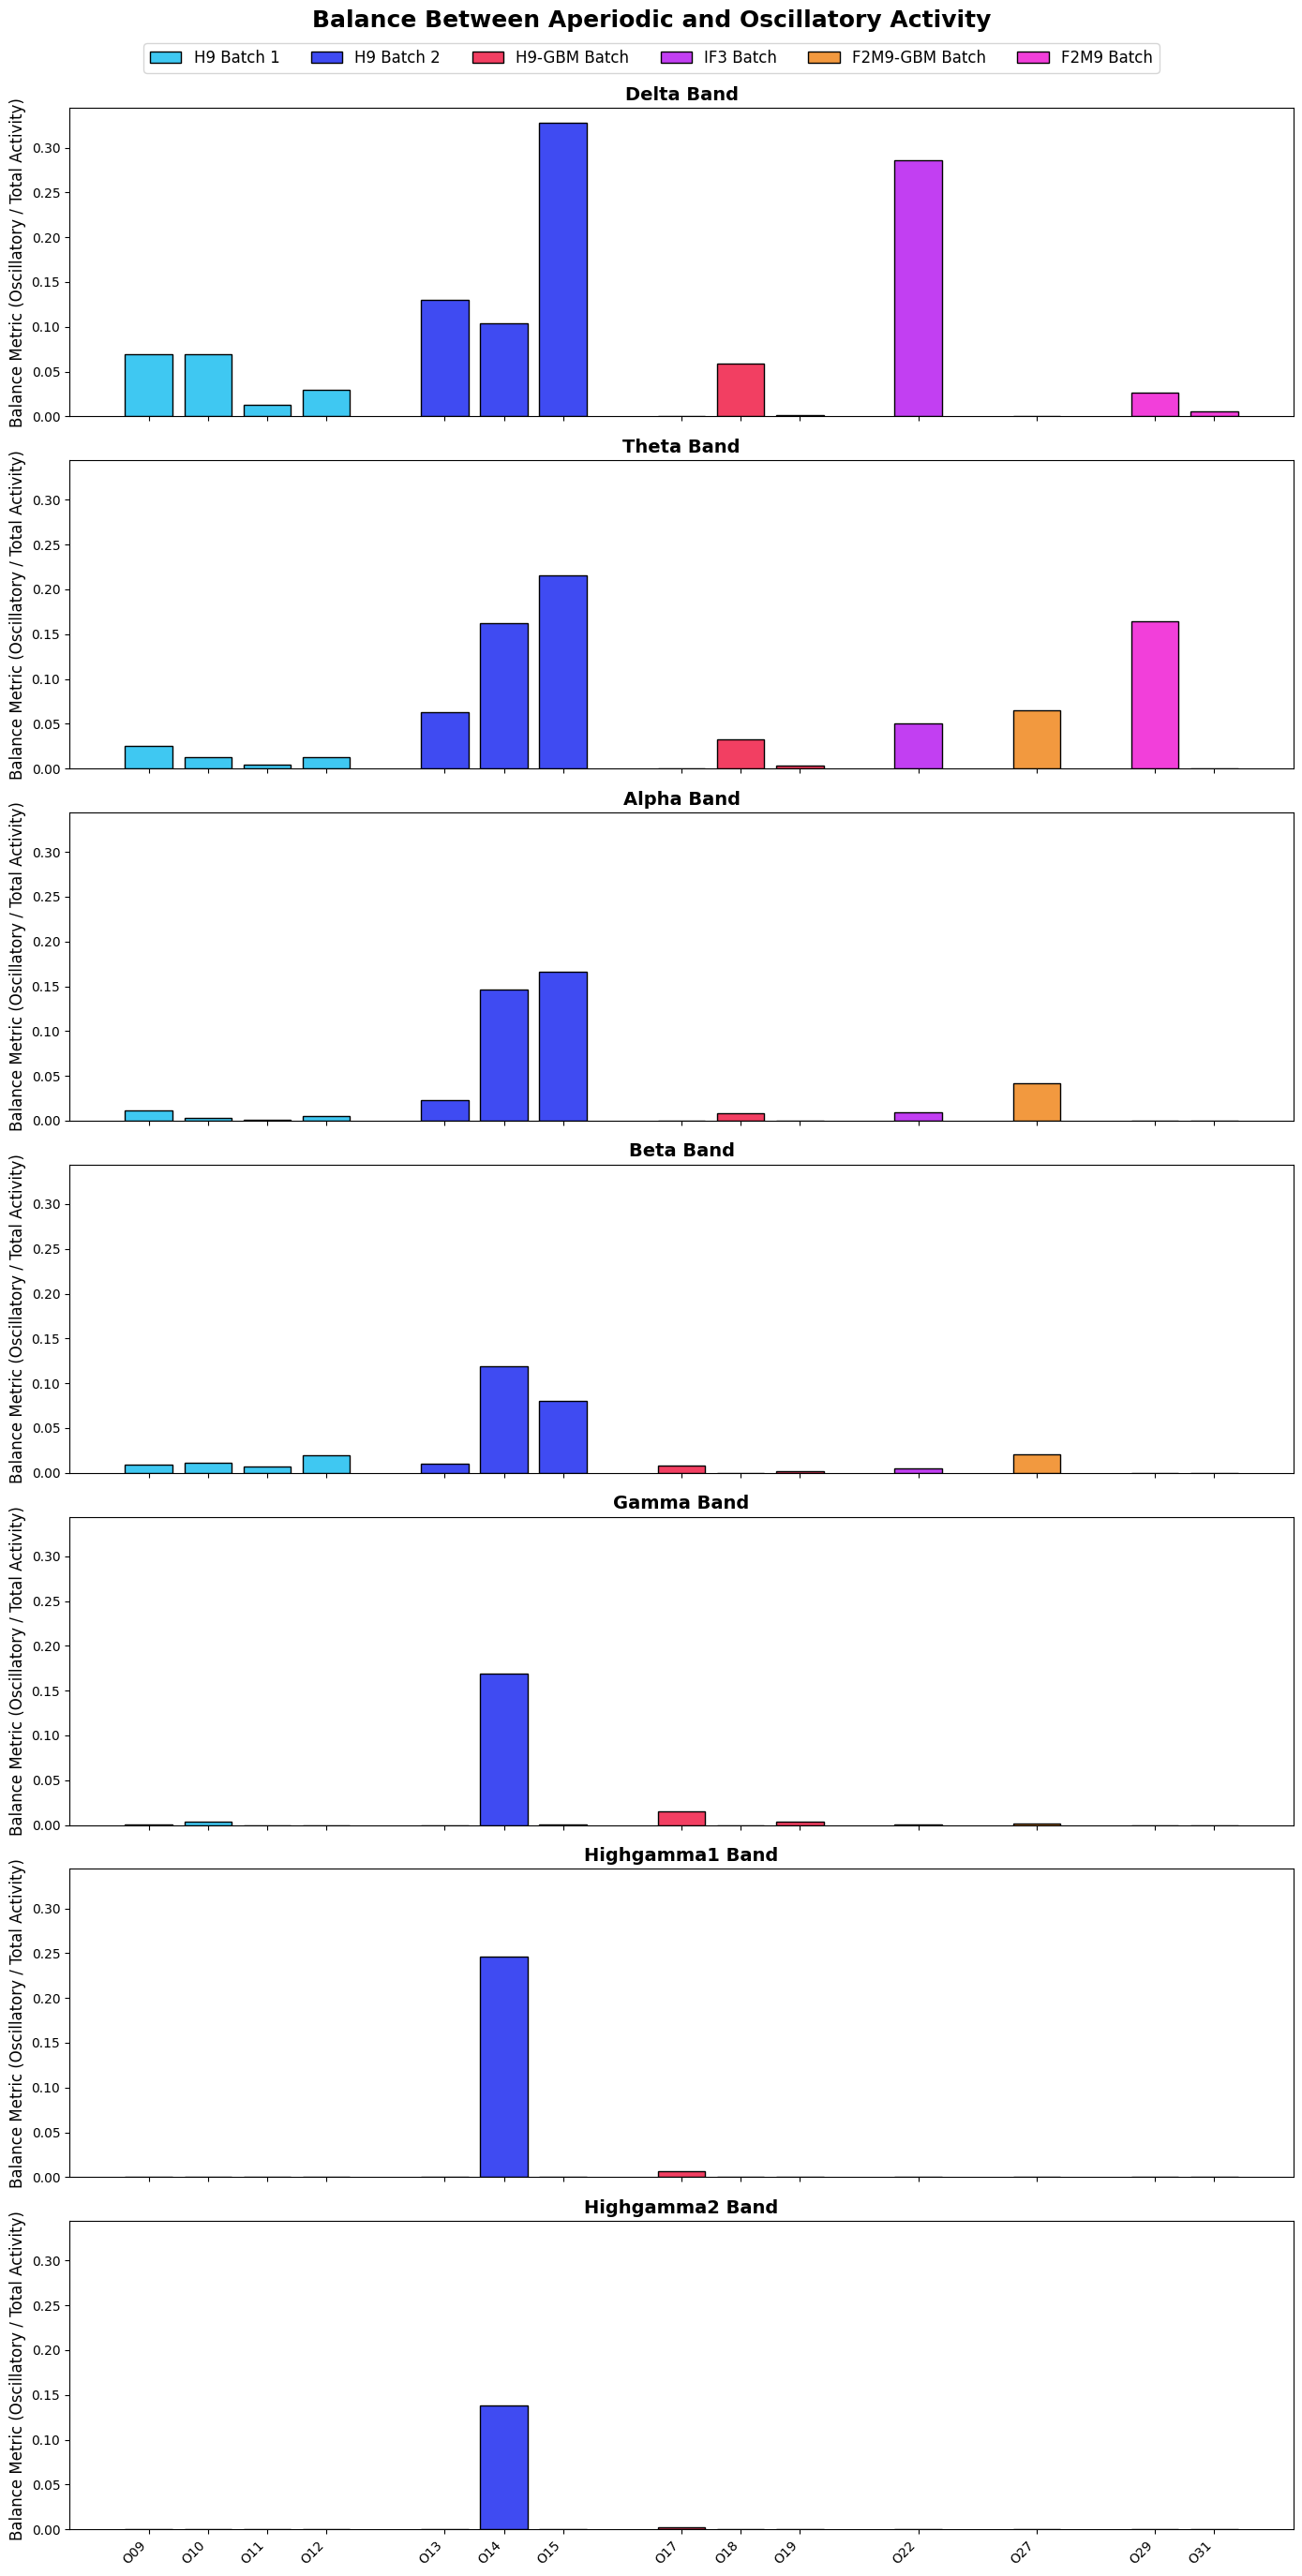

In [98]:
# Plot balance metric for each organoid (num bands x 1 figure)
# Bar plot of balance metric, colored by group, organoids on the x-axis

fig, axs = plt.subplots(len(frequency_bands), 1, figsize=(len(x_positions), 4*len(frequency_bands)), sharex=True, sharey=True)

for i, (band_name, (lower_freq, upper_freq)) in enumerate(frequency_bands.items()):
    ax = axs[i]

    for group_name, group_dict in balance_metric_dict.items():

        organoid_ids = list(group_dict.keys())
        x = [x_positions[organoid_id] for organoid_id in organoid_ids]
        y = [group_dict[organoid_id][band_name] for organoid_id in organoid_ids]

        # plot bar for mean value
        ax.bar(x, y, color=group_colors[group_name], alpha=1, width=box_width, edgecolor="black", label=group_name)

    # customize subplot
    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')
    ax.set_title(f"{band_name.capitalize()} Band", fontsize=14, fontweight="bold")
    ax.set_ylabel("Balance Metric (Oscillatory / Total Activity)", fontsize=12)

# customize figure
fig.suptitle("Balance Between Aperiodic and Oscillatory Activity", fontsize=18, fontweight="bold", y=0.98)
legend_elements = [Patch(facecolor=color, edgecolor='black', label=group_name) for group_name, color in group_colors.items()]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.97),
           ncol=len(group_colors), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])  # leaves top band for suptitle + legend

plt.show()

STTFA Analysis

In [99]:
# Get nSTTFA data for each organoid
nsttfa_dict = {}

for group_name, keys in analysis_keys.items():
    nsttfa_dict[group_name] = {}

    # fetch nSTTFA data
    organoid_ids, nsttfa_vectors, electrode_indices, frequency = (analysis.STTFA & keys & "spike_count >= 10").fetch("organoid_id", "n_sttfa", "electrode", "frequency")
    frequency = frequency[0] # should be the same for all entries
    nsttfa_array = 10 ** np.stack(nsttfa_vectors) # num sessions x frequency (log10 space -> linear space)

    for organoid_id in analysis_organoids_dict[group_name]:
        organoid_mask = organoid_ids == organoid_id

        num_elec_inside = (culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")
        elec_mask = electrode_indices < num_elec_inside
        
        nsttfa_dict[group_name][organoid_id] = nsttfa_array[organoid_mask & elec_mask, :]

In [100]:
nsttfa_band_dict = {}

for group_name, group_dict in nsttfa_dict.items():
    nsttfa_band_dict[group_name] = {}

    for organoid_id, nsttfa_array in group_dict.items():

        band_powers = {}
        for band_name, (lower_freq, upper_freq) in frequency_bands.items():
            freq_mask = (frequency >= lower_freq) & (frequency <= upper_freq)
            band_power = np.mean(nsttfa_array[:, freq_mask])
            band_powers[band_name] = band_power

        nsttfa_band_dict[group_name][organoid_id] = band_powers

In [101]:
# TODO: Read through the "nSTTFA (log10(diff in uV^2)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using nsttfa_band_dict
# each frequency band is given its own columns 
# each group of columns contains (in order): "Organoid ID", "Organoid Average", and 32 Electrode indices (0-31)
# above this row is a cell with the frequency band name (e.g. "Delta", "Theta", etc.)
# loop through nsttfa_band_dict using the 2nd layer of dictionary keys to fill in the "Organoid ID" column (final layer of keys corresponds to frequency bands)
# for each organoid, fill in the nSTTFA value for each electrode under the corresponding electrode index column and frequency band
# under the "Organoid Average" column, fill in the average nSTTFA value across electrodes for each organoid
# Each organoid should fill one complete row (different frequency bands will have different collumns)

# Populate "nSTTFA (log10(diff in uV^2)" sheet
# Sheet layout: 7 band blocks side-by-side (same 35-col stride as Frequency Band Power).
#   Band block start columns (1-based): [1, 36, 71, 106, 141, 176, 211]
#   Block: Col 1 = "Organoid ID", Col 2 = "Organoid Average", Cols 3-34 = Electrodes 0-31, Col 35 = spacer
# nsttfa_band_dict structure: {group_name: {organoid_id: {band_name: scalar (mean across elec & freq)}}}
# Per-electrode values come from nsttfa_dict[group_name][organoid_id] (shape: num_elec x num_freqs).
NSTTFA_BAND_START_COLS = [1, 36, 71, 106, 141, 176, 211]

wb_ns = openpyxl.load_workbook(excel_workbook_path)
ws_ns = wb_ns["nSTTFA (log10(diff in uV^2)"]

ns_data_row = 3  # all band blocks share the same row counter

for group_name, group_dict in nsttfa_band_dict.items():
    for organoid_id, band_dict in group_dict.items():
        for b_idx, band_name in enumerate(band_name_order):
            col_offset = NSTTFA_BAND_START_COLS[b_idx]
            band_mean = band_dict[band_name]
            ws_ns.cell(row=ns_data_row, column=col_offset,     value=organoid_id)
            ws_ns.cell(row=ns_data_row, column=col_offset + 1, value=float(band_mean))
            # Per-electrode means from the raw nsttfa_dict
            if organoid_id in nsttfa_dict.get(group_name, {}):
                nsttfa_array = nsttfa_dict[group_name][organoid_id]  # (num_elec, num_freqs)
                freq_mask_ns = (frequency >= frequency_bands[band_name][0]) & (frequency <= frequency_bands[band_name][1])
                elec_means_ns = np.mean(nsttfa_array[:, freq_mask_ns], axis=1)
                for elec_idx, elec_val in enumerate(elec_means_ns):
                    ws_ns.cell(row=ns_data_row, column=col_offset + 2 + elec_idx, value=float(elec_val))
        ns_data_row += 1

wb_ns.save(excel_workbook_path)
print("Saved 'nSTTFA (log10(diff in uV^2)'")

Saved 'nSTTFA (log10(diff in uV^2)'


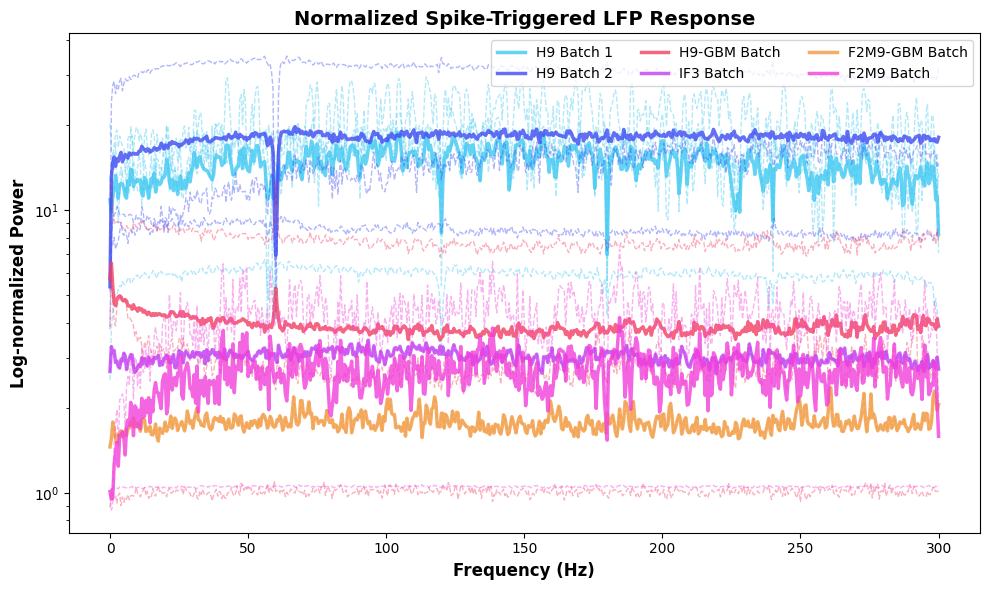

In [102]:
# Plot nsttfa vectors for each organoid, group averages indicated by bolded line (1 x 1 figure)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for group_name, group_dict in nsttfa_dict.items():
    for organoid_id, nsttfa_array in group_dict.items():

        mean_nsttfa = np.mean(nsttfa_array, axis=0)
        ax.plot(frequency, mean_nsttfa, color=group_colors[group_name], alpha=0.4, linewidth=1, linestyle="--")

    # plot group average with bold line
    group_mean_nsttfa = np.mean([np.mean(nsttfa_array, axis=0) for nsttfa_array in group_dict.values()], axis=0)
    ax.plot(frequency, group_mean_nsttfa, color=group_colors[group_name], alpha=0.8, linewidth=2.5, label=group_name)

# customize subplot
ax.set_xlabel("Frequency (Hz)", fontsize=12, fontweight="bold")
ax.set_ylabel("Log-normalized Power", fontsize=12, fontweight="bold")
ax.set_title("Normalized Spike-Triggered LFP Response", fontsize=14, fontweight="bold")
ax.set_yscale("log")
ax.legend(loc="upper right", fontsize=10, ncol=min([len(group_colors), 3]))

# customize figure
fig.tight_layout()
plt.show()

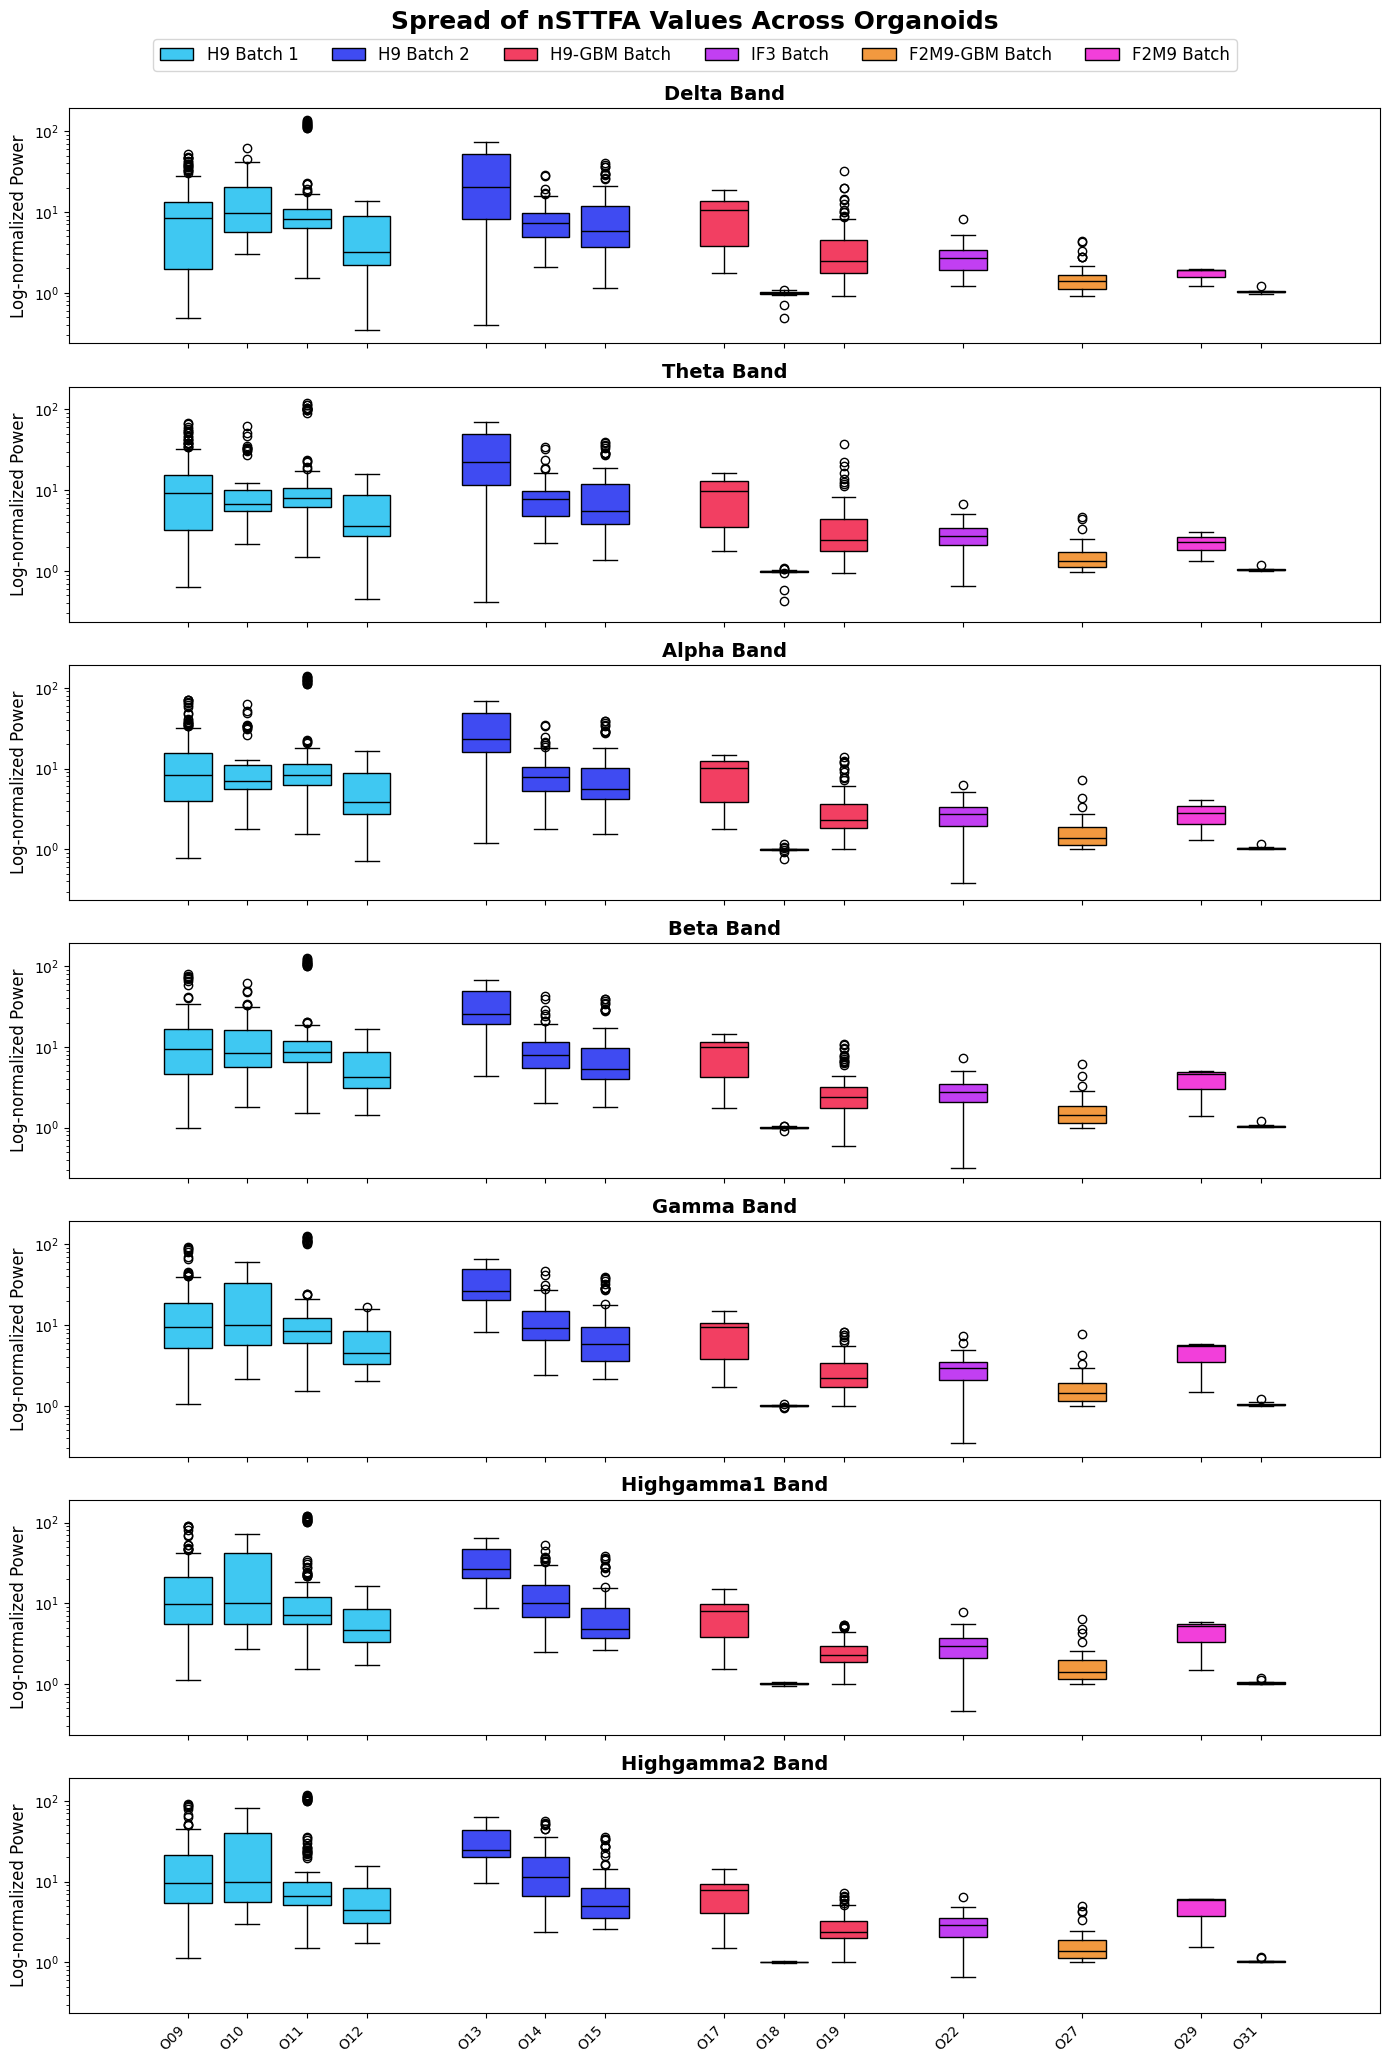

In [103]:
# Plot spread of nSTTFA values across organoids for each frequency band (num bands x 1 figure)
# Box and whisker subplot for each frequency band, colored by group, organoids on the x-axis

fig, axs = plt.subplots(len(frequency_bands), 1, figsize=(len(x_positions), 3*len(frequency_bands)), sharex=True, sharey=True)

for i, (band_name, (lower_freq, upper_freq)) in enumerate(frequency_bands.items()):
    ax = axs[i]

    for group_name, group_dict in nsttfa_dict.items():

        organoid_ids = list(group_dict.keys())
        x = [x_positions[organoid_id] for organoid_id in organoid_ids]
        y = [np.mean(group_dict[organoid_id][:, (frequency >= lower_freq) & (frequency <= upper_freq)], axis=1) for organoid_id in organoid_ids]

        # plot box and whisker for this band
        ax.boxplot(y, positions=x, widths=box_width, patch_artist=True,
                   boxprops=dict(facecolor=group_colors[group_name], color='black'),
                   medianprops=dict(color='black'),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'))

    # customize subplot
    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')
    ax.set_title(f"{band_name.capitalize()} Band", fontsize=14, fontweight="bold")
    ax.set_ylabel("Log-normalized Power", fontsize=12)
    ax.set_yscale("log")

# customize figure
fig.suptitle("Spread of nSTTFA Values Across Organoids", fontsize=18, fontweight="bold", y=0.98)
legend_elements = [Patch(facecolor=color, edgecolor='black', label=group_name) for group_name, color in group_colors.items()]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.97),
           ncol=len(group_colors), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])  # leaves top band for suptitle + legend

plt.show()

In [104]:
from scipy.interpolate import interp1d

def interpolate_spectrum(frequency, spectrum, notch_freqs):
    # create mask for frequencies to remove
    mask = np.ones_like(frequency, dtype=bool)
    for notch_freq in notch_freqs:
        freq_mask = (notch_freq - 3 <= frequency) & (frequency <= notch_freq + 3)
        mask = mask & (~freq_mask)
    # interpolate
    interp_func = interp1d(frequency[mask], spectrum[mask], kind='linear', fill_value="extrapolate")
    interp_spectrum = interp_func(frequency)
    
    return interp_spectrum

In [105]:
# Get z-scored (across frequency) nSTTFA values for each organoid
nsttfa_zscore_dict = {}

for group_name, keys in analysis_keys.items():
    nsttfa_zscore_dict[group_name] = {}

    # fetch nSTTFA data
    organoid_ids, nsttfa_vectors, electrode_indices, frequency = (analysis.STTFA & keys & "spike_count >= 10").fetch("organoid_id", "n_sttfa", "electrode", "frequency")
    frequency = frequency[0] # should be the same for all entries
    nsttfa_array = 10 ** np.stack(nsttfa_vectors) # num sessions x frequency (log10 space -> linear space)

    for organoid_id in analysis_organoids_dict[group_name]:
        organoid_mask = organoid_ids == organoid_id

        num_elec_inside = (culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")
        elec_mask = electrode_indices < num_elec_inside
        
        organoid_nsttfa = nsttfa_array[organoid_mask & elec_mask, :]

        # account for 60 Hz harmonics by interpolating over +-3 before z-scoring
        for i in range(organoid_nsttfa.shape[0]):
            organoid_nsttfa[i, :] = interpolate_spectrum(frequency, organoid_nsttfa[i, :], notch_freqs=np.arange(60, frequency.max(), 60))

        organoid_nsttfa_zscore = stats.zscore(organoid_nsttfa, axis=1) # z-score across frequency for each session

        nsttfa_zscore_dict[group_name][organoid_id] = organoid_nsttfa_zscore

In [106]:
nsttfa_zscore_band_dict = {}
for group_name, group_dict in nsttfa_zscore_dict.items():
    nsttfa_zscore_band_dict[group_name] = {}

    for organoid_id, nsttfa_zscore_array in group_dict.items():

        band_powers = {}
        for band_name, (lower_freq, upper_freq) in frequency_bands.items():
            freq_mask = (frequency >= lower_freq) & (frequency <= upper_freq)
            band_power = np.mean(nsttfa_zscore_array[:, freq_mask])
            band_powers[band_name] = band_power

        nsttfa_zscore_band_dict[group_name][organoid_id] = band_powers

In [107]:
# TODO: Read through the "z-score nSTTFA (across freq)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using nsttfa_zscore_band_dict
# each frequency band is given its own columns 
# each group of columns contains (in order): "Organoid ID", "Organoid Average", and 32 Electrode indices (0-31)
# above this row is a cell with the frequency band name (e.g. "Delta", "Theta", etc.)
# loop through nsttfa_zscore_band_dict using the 2nd layer of dictionary keys to fill in the "Organoid ID" column (final layer of keys corresponds to frequency bands)
# for each organoid, fill in the nSTTFA value for each electrode under the corresponding electrode index column and frequency band
# under the "Organoid Average" column, fill in the average nSTTFA value across electrodes for each organoid
# Each organoid should fill one complete row (different frequency bands will have different collumns)

# Populate "z-score nSTTFA (across freq)" sheet
# Identical layout to "nSTTFA" sheet — same band block start columns.
# nsttfa_zscore_band_dict structure: {group_name: {organoid_id: {band_name: scalar}}}

ZSCORE_NSTTFA_BAND_START_COLS = [1, 36, 71, 106, 141, 176, 211]

wb_zns = openpyxl.load_workbook(excel_workbook_path)
ws_zns = wb_zns["z-score nSTTFA (across freq)"]

zns_data_row = 3

for group_name, group_dict in nsttfa_zscore_band_dict.items():
    for organoid_id, band_dict in group_dict.items():
        for b_idx, band_name in enumerate(band_name_order):
            col_offset = ZSCORE_NSTTFA_BAND_START_COLS[b_idx]
            band_mean = band_dict[band_name]
            ws_zns.cell(row=zns_data_row, column=col_offset,     value=organoid_id)
            ws_zns.cell(row=zns_data_row, column=col_offset + 1, value=float(band_mean))
            # Per-electrode z-scored means from nsttfa_zscore_dict
            if organoid_id in nsttfa_zscore_dict.get(group_name, {}):
                zscore_array = nsttfa_zscore_dict[group_name][organoid_id]  # (num_elec, num_freqs)
                freq_mask_zns = (frequency >= frequency_bands[band_name][0]) & (frequency <= frequency_bands[band_name][1])
                elec_means_z = np.mean(zscore_array[:, freq_mask_zns], axis=1)
                for elec_idx, elec_val in enumerate(elec_means_z):
                    ws_zns.cell(row=zns_data_row, column=col_offset + 2 + elec_idx, value=float(elec_val))
        zns_data_row += 1

wb_zns.save(excel_workbook_path)
print("Saved 'z-score nSTTFA (across freq)'")

Saved 'z-score nSTTFA (across freq)'


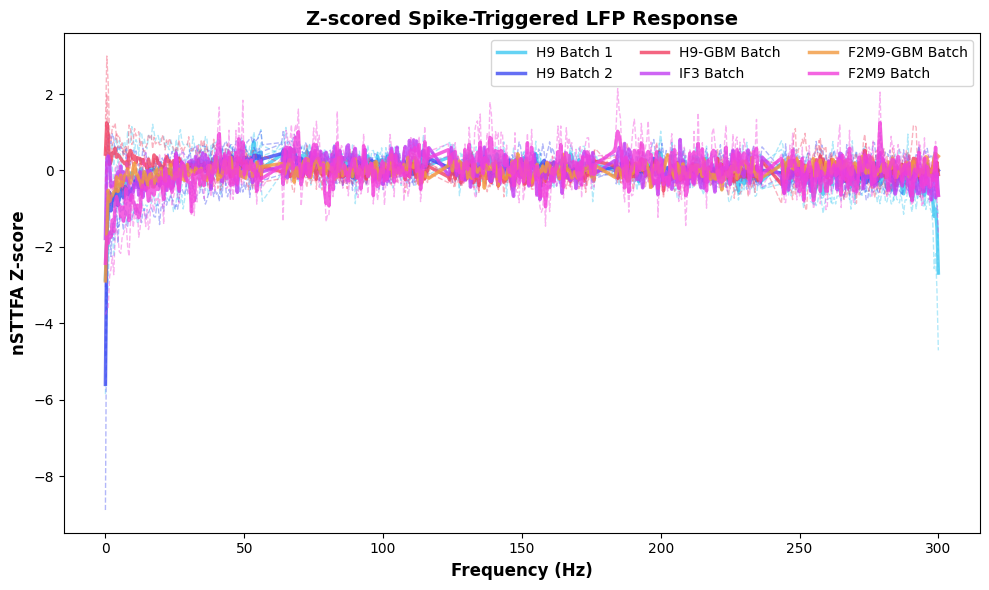

In [108]:
# Plot nsttfa zscore vectors for each organoid, group averages indicated by bolded line (1 x 1 figure)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for group_name, group_dict in nsttfa_zscore_dict.items():
    for organoid_id, nsttfa_zscore_array in group_dict.items():

        mean_nsttfa = np.mean(nsttfa_zscore_array, axis=0)
        ax.plot(frequency, mean_nsttfa, color=group_colors[group_name], alpha=0.4, linewidth=1, linestyle="--")

    # plot group average with bold line
    group_mean_nsttfa = np.mean([np.mean(nsttfa_zscore_array, axis=0) for nsttfa_zscore_array in group_dict.values()], axis=0)
    ax.plot(frequency, group_mean_nsttfa, color=group_colors[group_name], alpha=0.8, linewidth=2.5, label=group_name)

# customize subplot
ax.set_xlabel("Frequency (Hz)", fontsize=12, fontweight="bold")
ax.set_ylabel("nSTTFA Z-score", fontsize=12, fontweight="bold")
ax.set_title("Z-scored Spike-Triggered LFP Response", fontsize=14, fontweight="bold")

ax.legend(loc="upper right", fontsize=10, ncol=min([len(group_colors), 3]))

# customize figure
fig.tight_layout()
plt.show()

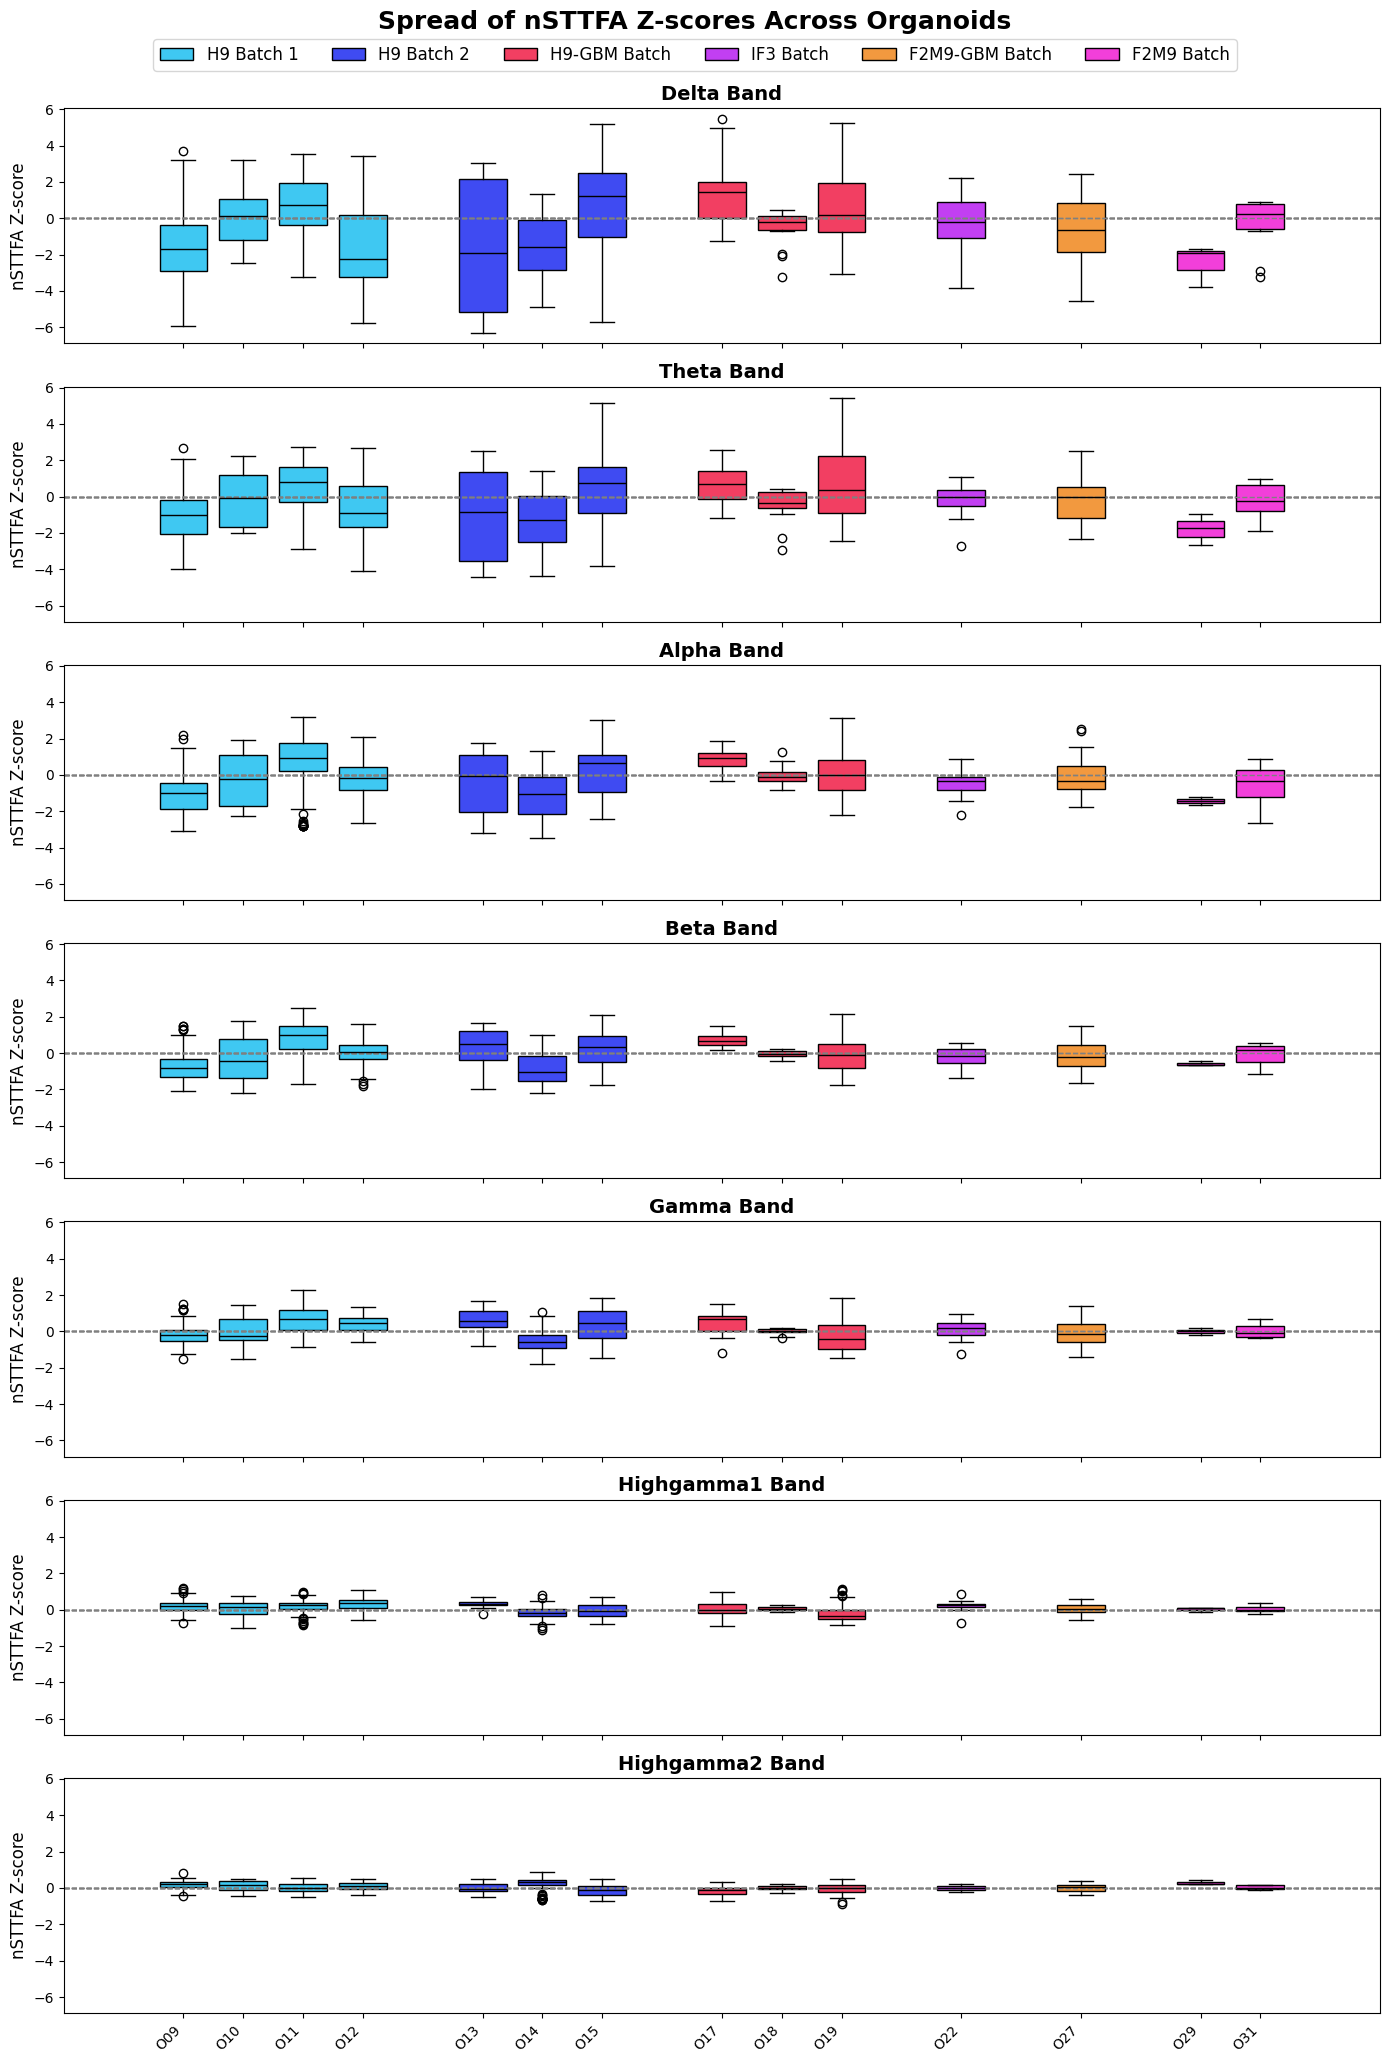

In [109]:
# Plot spread of nSTTFA zscore values across organoids for each frequency band (num bands x 1 figure)
# Box and whisker subplot for each frequency band, colored by group, organoids on the x-axis

fig, axs = plt.subplots(len(frequency_bands), 1, figsize=(len(x_positions), 3*len(frequency_bands)), sharex=True, sharey=True)

for i, (band_name, (lower_freq, upper_freq)) in enumerate(frequency_bands.items()):
    ax = axs[i]

    for group_name, group_dict in nsttfa_zscore_dict.items():

        organoid_ids = list(group_dict.keys())
        x = [x_positions[organoid_id] for organoid_id in organoid_ids]
        y = [np.mean(group_dict[organoid_id][:, (frequency >= lower_freq) & (frequency <= upper_freq)], axis=1) for organoid_id in organoid_ids]

        # plot box and whisker for this band
        ax.boxplot(y, positions=x, widths=box_width, patch_artist=True,
                   boxprops=dict(facecolor=group_colors[group_name], color='black'),
                   medianprops=dict(color='black'),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'))
        ax.axhline(0, color='gray', linestyle='--', linewidth=1) # add horizontal line at y=0 for reference

    # customize subplot
    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')
    ax.set_title(f"{band_name.capitalize()} Band", fontsize=14, fontweight="bold")
    ax.set_ylabel("nSTTFA Z-score", fontsize=12)

# customize figure
fig.suptitle("Spread of nSTTFA Z-scores Across Organoids", fontsize=18, fontweight="bold", y=0.98)
legend_elements = [Patch(facecolor=color, edgecolor='black', label=group_name) for group_name, color in group_colors.items()]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.97),
           ncol=len(group_colors), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])  # leaves top band for suptitle + legend

plt.show()

Coherence Analysis

In [110]:
# Get coherence (connectivity) data for each organoid
connectivity_dict = {}

for group_name, keys in analysis_keys.items():
    connectivity_dict[group_name] = {}

    # fetch coherence data
    organoid_ids, el_A_indices, el_B_indices, coherence_values = (analysis.Coherence.Connectivity & keys).fetch("organoid_id", "electrode_a", "electrode_b", "coherence")
    frequency = (analysis.Coherence.Connectivity & keys[0]).fetch("f")[0]
    coherence_array = np.stack(coherence_values) # num sessions x frequency

    for organoid_id in analysis_organoids_dict[group_name]:
        organoid_mask = organoid_ids == organoid_id
        num_elec_inside = (culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")

        organoid_coherence = np.zeros((num_elec_inside, num_elec_inside, len(frequency))) # initialize array to hold coherence values for all electrode pairs
        for electrode_A in range(num_elec_inside - 1): # in data, electrode A is always less than electrode B, so we can iterate through pairs without worrying about duplicates
            for electrode_B in range(electrode_A + 1, num_elec_inside):

                pair_mask = (el_A_indices == electrode_A) & (el_B_indices == electrode_B)

                # ensure there are the expected number of data values
                if sum(organoid_mask & pair_mask) != num_sessions_dict[group_name][organoid_id]:
                    raise ValueError(f"Expected {num_sessions_dict[group_name][organoid_id]} data points for organoid {organoid_id} and electrode pair {electrode_A}-{electrode_B} but found {sum(organoid_mask & pair_mask)}")

                # average coherence across sessions for this electrode pair
                mean_coherence = np.mean(coherence_array[organoid_mask & pair_mask, :], axis=0)

                organoid_coherence[electrode_A, electrode_B, :] = mean_coherence

        connectivity_dict[group_name][organoid_id] = organoid_coherence

In [111]:
connectivity_band_dict = {}

for group_name, group_dict in connectivity_dict.items():
    connectivity_band_dict[group_name] = {}

    for organoid_id, coherence_array in group_dict.items():

        band_coherence = {}
        for band_name, (lower_freq, upper_freq) in frequency_bands.items():
            freq_mask = (frequency >= lower_freq) & (frequency <= upper_freq)
            mean_band_coherence = np.mean(coherence_array[:, :, freq_mask], axis=2) # average coherence across frequencies within the band
            band_coherence[band_name] = mean_band_coherence

        connectivity_band_dict[group_name][organoid_id] = band_coherence

In [112]:
# TODO: Read through the "Connectivity (Coherence)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using connectivity_band_dict
# each frequency band is given its own columns. Each organoid is given its own set of 32 rows (1 per electrode)
# Each frequency band has 32 columns corresponding to the coherence values between that electrode and the other 31 electrodes (e.g. column 0 is coherence between electrode 0 and electrode 0, column 1 is coherence between electrode 0 and electrode 1, etc.)
# The top row for each band has the band name (e.g. "Delta", "Theta", etc.)
# There is one empty column between each frequency band's set of columns
# loop through connectivity_band_dict using the 2nd layer of dictionary keys to fill in the "Organoid ID" column (final layer of keys corresponds to frequency bands)
#      since there are multiple rows per organoid, fill in the "Organoid ID" column with the same organoid ID for all 32 rows corresponding to that organoid
# the final value is a 32x32 matrix of coherence values for each organoid and frequency band (array indices indicate electrode numbers)
# for each organoid, fill in the coherence values for each electrode under the corresponding electrode index columns and frequency band
# for each organoid, also fill in the electrode indices (0-31) in the first column to indicate which electrode the row corresponds to (under the "Electrode Indices" column)

# Populate "Connectivity (Coherence)" sheet
# Sheet layout: 7 band blocks side-by-side.
#   Band block start columns (1-based): [1, 36, 71, 106, 141, 176, 211]
#   Block structure (within each band):
#     Col 1: "Organoid ID"  (filled only in the first row of each 32-row organoid block)
#     Col 2: "Electrode Indices" (0-31, written for each organoid)
#     Cols 3-34: Electrode coherence values 0-31
#     Col 35: blank spacer
# connectivity_band_dict structure: {group_name: {organoid_id: {band_name: np.array shape (num_elec, num_elec)}}}

# Each organoid occupies num_elec consecutive rows. Row 3+ is data.
CONN_BAND_START_COLS = [1, 36, 71, 106, 141, 176, 211]

wb_conn = openpyxl.load_workbook(excel_workbook_path)
ws_conn = wb_conn["Connectivity (Coherence)"]

# Track next start data row per band block
conn_band_data_rows = {band_name: 3 for band_name in band_name_order}

for group_name, group_dict in connectivity_band_dict.items():
    for organoid_id, band_coh_dict in group_dict.items():
        for b_idx, band_name in enumerate(band_name_order):
            col_offset = CONN_BAND_START_COLS[b_idx]
            start_row = conn_band_data_rows[band_name]
            coh_matrix = band_coh_dict[band_name]  # shape (num_elec, num_elec)
            num_elec = coh_matrix.shape[0]
            for elec_row in range(num_elec):
                r = start_row + elec_row
                if elec_row == 0:
                    ws_conn.cell(row=r, column=col_offset, value=organoid_id)   # Organoid ID (first row only)
                ws_conn.cell(row=r, column=col_offset + 1, value=elec_row)      # Electrode Index
                for elec_col in range(num_elec):
                    ws_conn.cell(row=r, column=col_offset + 2 + elec_col,
                                 value=float(coh_matrix[elec_row, elec_col]))

        # Advance each band block by num_elec rows (using last organoid's shape)
        for b_idx, band_name in enumerate(band_name_order):
            conn_band_data_rows[band_name] += band_coh_dict[band_name].shape[0]

wb_conn.save(excel_workbook_path)
print("Saved 'Connectivity (Coherence)'")

Saved 'Connectivity (Coherence)'


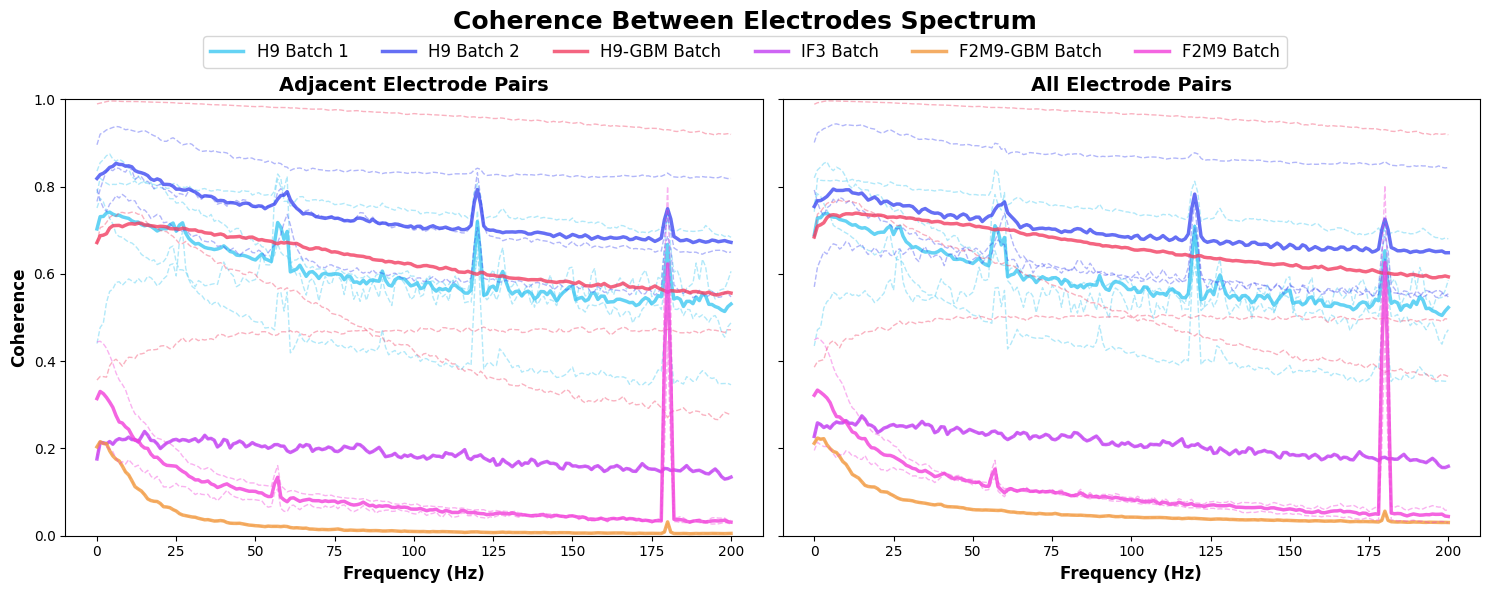

In [113]:
# Plot cohernce spectrum for adjacent and all pairs (1 x 2 figure)
# left plot: line plot of coherence spectrum for adjacent electrode pairs for each organoid, group average with bold line, colored by group
# right plot: line plot of coherence spectrum averaged across all electrode pairs for each organoid, group average with bold line, colored by group

fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True, sharex=True)

for group_name, group_dict in connectivity_dict.items():

    group_adjacent_coherence = []
    group_all_pairs_coherence = []
    for organoid_id, coherence_array in group_dict.items():

        # left plot: adjacent pairs
        adjacent_coherence = []
        for electrode_A in range(coherence_array.shape[0] - 1):
            electrode_B = electrode_A + 1
            adjacent_coherence.append(coherence_array[electrode_A, electrode_B, :])
        mean_adjacent_coherence = np.mean(adjacent_coherence, axis=0)
        axs[0].plot(frequency, mean_adjacent_coherence, color=group_colors[group_name], alpha=0.4, linewidth=1, linestyle="--")

        group_adjacent_coherence.append(mean_adjacent_coherence)

        # right plot: all pairs
        upper_triangle_indices = np.triu_indices(coherence_array.shape[0], k=1) # get indices for upper triangle of coherence matrix (excluding diagonal)
        all_pairs_coherence = coherence_array[upper_triangle_indices[0], upper_triangle_indices[1], :]
        mean_all_pairs_coherence = np.mean(all_pairs_coherence, axis=0)
        axs[1].plot(frequency, mean_all_pairs_coherence, color=group_colors[group_name], alpha=0.4, linewidth=1, linestyle="--")

        group_all_pairs_coherence.append(mean_all_pairs_coherence)

    # plot group average with bold line
    mean_group_adjacent_coherence = np.mean(group_adjacent_coherence, axis=0)
    axs[0].plot(frequency, mean_group_adjacent_coherence, color=group_colors[group_name], alpha=0.8, linewidth=2.5, label=group_name)

    mean_group_all_pairs_coherence = np.mean(group_all_pairs_coherence, axis=0)
    axs[1].plot(frequency, mean_group_all_pairs_coherence, color=group_colors[group_name], alpha=0.8, linewidth=2.5)

# customize subplots
axs[0].set_title("Adjacent Electrode Pairs", fontsize=14, fontweight="bold")
axs[0].set_xlabel("Frequency (Hz)", fontsize=12, fontweight="bold")
axs[0].set_ylabel("Coherence", fontsize=12, fontweight="bold")
axs[0].set_ylim(0, 1)
axs[1].set_title("All Electrode Pairs", fontsize=14, fontweight="bold")
axs[1].set_xlabel("Frequency (Hz)", fontsize=12, fontweight="bold")

# customize figure
fig.suptitle("Coherence Between Electrodes Spectrum", fontsize=18, fontweight="bold")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=len(group_colors), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96]) # leave top band for suptitle + legend

plt.show()

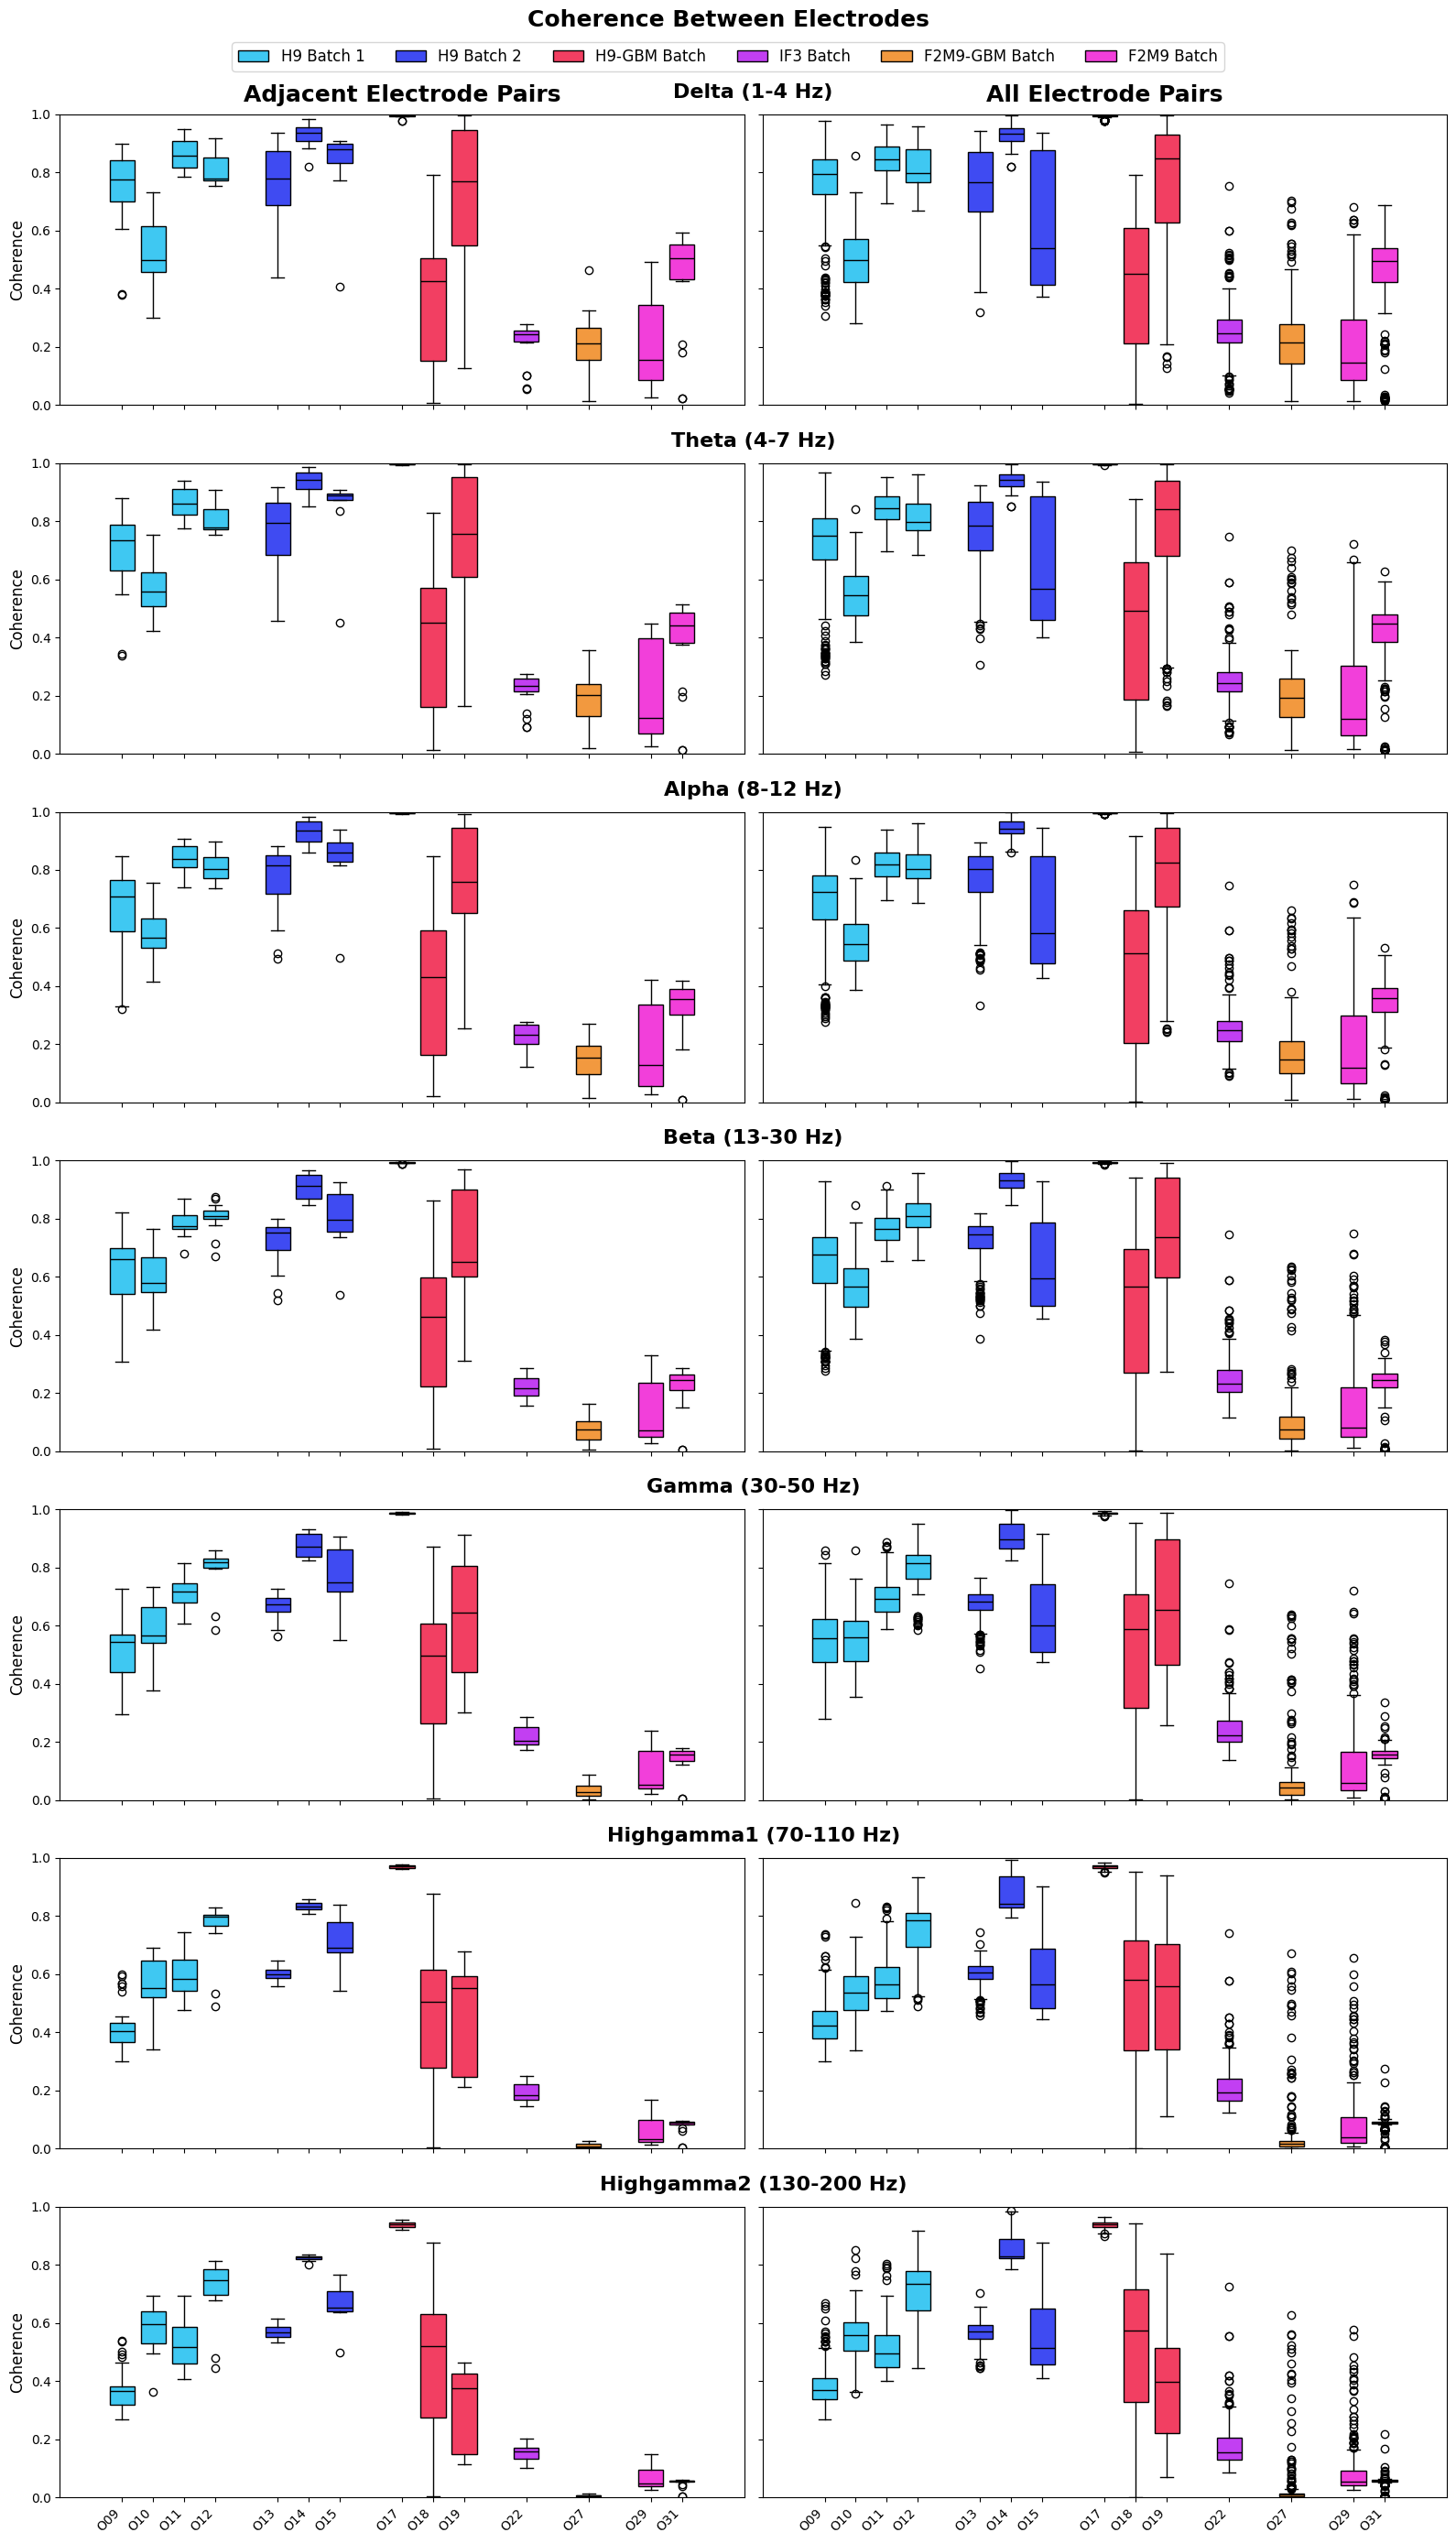

In [114]:
# Plot spread of coherence values across organoids for adjacent and all pairs for each frequency band (num bands x 2 figure)
# Box and whisker subplot for each frequency band and pair type, colored by group, organoids on the x-axis

fig, axs = plt.subplots(len(frequency_bands), 2, figsize=(16, 4*len(frequency_bands)), sharex=True, sharey=True)

for i, (band_name, (lower_freq, upper_freq)) in enumerate(frequency_bands.items()):
    for j in range(2): # loop through adjacent and all pairs
        ax = axs[i, j]

        for group_name, group_dict in connectivity_dict.items():

            organoid_ids = list(group_dict.keys())
            x = [x_positions[organoid_id] for organoid_id in organoid_ids]
            y = []
            for organoid_id in organoid_ids:
                coherence_array = group_dict[organoid_id]

                if j == 0: # adjacent pairs
                    adjacent_coherence = []
                    for electrode_A in range(coherence_array.shape[0] - 1):
                        electrode_B = electrode_A + 1
                        adjacent_coherence.append(coherence_array[electrode_A, electrode_B, (frequency >= lower_freq) & (frequency <= upper_freq)])
                    mean_adjacent_coherence = np.mean(adjacent_coherence, axis=1)
                    y.append(mean_adjacent_coherence)

                else: # all pairs
                    upper_triangle_indices = np.triu_indices(coherence_array.shape[0], k=1)
                    all_pairs_coherence = coherence_array[upper_triangle_indices[0], upper_triangle_indices[1], :][:, (frequency >= lower_freq) & (frequency <= upper_freq)]
                    mean_all_pairs_coherence = np.mean(all_pairs_coherence, axis=1)
                    y.append(mean_all_pairs_coherence)

            # plot box and whisker for this band and pair type
            ax.boxplot(y, positions=x, widths=box_width, patch_artist=True,
                       boxprops=dict(facecolor=group_colors[group_name], color='black'),
                       medianprops=dict(color='black'),
                       whiskerprops=dict(color='black'),
                       capprops=dict(color='black'))

        # customize subplot
        ax.set_xticks(list(x_positions.values()))
        ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')

        if j == 0:
            ax.set_ylabel("Coherence", fontsize=12)
        ax.set_ylim(0, 1)

# customize figure
fig.suptitle("Coherence Between Electrodes", fontsize=18, fontweight="bold", y=0.99)

legend_elements = [Patch(facecolor=color, edgecolor='black', label=group_name) for group_name, color in group_colors.items()]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.98),
           ncol=len(group_colors), fontsize=12)

# column titles (metric names) above top row
for j, metric_name in enumerate(["Adjacent Electrode Pairs", "All Electrode Pairs"]):
    axs[0, j].set_title(metric_name, fontsize=18, fontweight="bold", pad=10)

# row titles (band names) centered above each row, between the two columns
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.subplots_adjust(hspace=0.2)  # increase vertical space between rows for band title text

for i, (band_name, (lower_freq, upper_freq)) in enumerate(frequency_bands.items()):
    ax_left = axs[i, 0]
    ax_right = axs[i, -1]
    left_pos = ax_left.get_position()
    right_pos = ax_right.get_position()
    center_x = (left_pos.x0 + right_pos.x1) / 2
    top_y = left_pos.y1  # top edge of the row
    fig.text(center_x, top_y+.005, f"{band_name.capitalize()} ({int(lower_freq)}-{int(upper_freq)} Hz)",
             ha='center', va='bottom', fontsize=16, fontweight='bold',
             rotation=0, transform=fig.transFigure)

plt.show()

In [115]:
# Get the coherence binned according to electrode distance for each organoid
connectivity_distance_dict = {}

for group_name, keys in analysis_keys.items():
    connectivity_distance_dict[group_name] = {}

    # fetch coherence data
    organoid_ids, el_A_indices, el_B_indices, coherence_values = (analysis.Coherence.Connectivity & keys).fetch("organoid_id", "electrode_a", "electrode_b", "coherence")
    frequency = (analysis.Coherence.Connectivity & keys[0]).fetch("f")[0]
    coherence_array = np.stack(coherence_values) # num sessions x frequency

    # calculate distance between electrode pairs based on their indices (assuming linear array with adjacent electrodes 1 unit apart)
    electrode_distances = (el_B_indices - el_A_indices) * 100
    unique_distances = np.unique(electrode_distances)

    for organoid_id in analysis_organoids_dict[group_name]:
        organoid_mask = organoid_ids == organoid_id
        num_elec_inside = (culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")

        organoid_coherence = np.zeros((num_elec_inside, len(unique_distances), len(frequency))) 
        for elec in range(num_elec_inside):

            # get pairs that include this electrode and are within the implanted array
            elec_mask = ((el_A_indices == elec) | (el_B_indices == elec)) & ((el_A_indices < num_elec_inside) & (el_B_indices < num_elec_inside))

            # ensure there are the expected number of data values
            if sum(organoid_mask & elec_mask) != (num_sessions_dict[group_name][organoid_id] * (num_elec_inside - 1)):
                raise ValueError(f"Expected {num_sessions_dict[group_name][organoid_id] * (num_elec_inside - 1)} data points for organoid {organoid_id} and electrode {elec} but found {sum(organoid_mask & elec_mask)}")

            for i, distance in enumerate(unique_distances):
                distance_mask = electrode_distances == distance

                if sum(organoid_mask & elec_mask & distance_mask) == 0:
                    organoid_coherence[elec, i, :] = np.nan
                else:
                    mean_coherence = np.mean(coherence_array[organoid_mask & elec_mask & distance_mask, :], axis=0)
                    organoid_coherence[elec, i, :] = mean_coherence
        
        connectivity_distance_dict[group_name][organoid_id] = organoid_coherence 

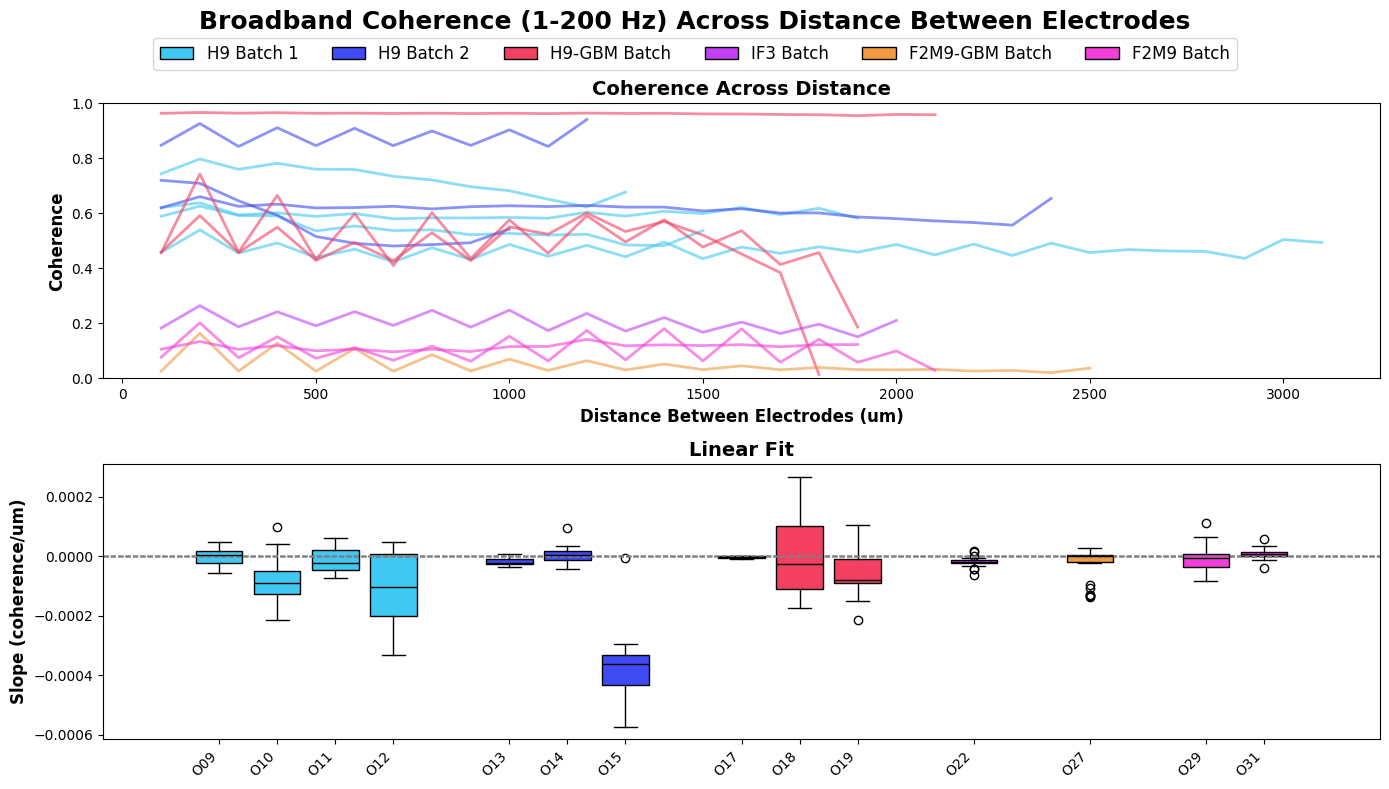

In [116]:
# Plot how broadband coherence changes with distance between electrodes for each organoid (2 x 1 figure)
# top plot: line plot of coherence vs distance for each organoid, group average with bold line, colored by group
# bottom plot: bar plot of linear fit slope of coherence vs distance for each organoid, colored by group

fig, axs = plt.subplots(2, 1, figsize=(len(x_positions), 8))

freq_min = 1
freq_max = 200
band_mask = (frequency >= freq_min) & (frequency <= freq_max)

for group_name, group_dict in connectivity_distance_dict.items():

    x = [x_positions[organoid_id] for organoid_id in list(group_dict.keys())]
    y = []
    for organoid_id, coherence_array in group_dict.items():
        
        organoid_broadband_coherence = np.mean(coherence_array[:,:, band_mask], axis=2) # average across frequency

        # top plot: coherence vs distance
        valid_distance_mask = ~np.isnan(organoid_broadband_coherence).all(axis=0) # only include distances that have valid coherence values for at least one electrode
        mean_coherence_distance = np.nanmean(organoid_broadband_coherence[:, valid_distance_mask], axis=0) # average across electrodes for each distance, ignoring nans        
        
        axs[0].plot(unique_distances[valid_distance_mask], mean_coherence_distance, color=group_colors[group_name], alpha=0.6, linewidth=2)

        # bottom plot: linear fit slope of coherence vs distance
        organoid_slopes = []
        for elec_broadband_coherence in organoid_broadband_coherence:
            elec_mask = ~np.isnan(elec_broadband_coherence) # only include distances that have data for this electrode    
        
            slope, intercept, r_value, p_value, std_err = stats.linregress(unique_distances[elec_mask], elec_broadband_coherence[elec_mask])
            organoid_slopes.append(slope)
        y.append(organoid_slopes)

    # plot box and whisker for this band
    axs[1].boxplot(y, positions=x, widths=box_width, patch_artist=True,
                    boxprops=dict(facecolor=group_colors[group_name], color='black'),
                    medianprops=dict(color='black'),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'))
    axs[1].axhline(0, color='gray', linestyle='--', linewidth=1) # add horizontal line at y=0 for reference

# customize top subplot
axs[0].set_xlabel("Distance Between Electrodes (um)", fontsize=12, fontweight="bold")
axs[0].set_ylabel("Coherence", fontsize=12, fontweight="bold")
axs[0].set_title("Coherence Across Distance", fontsize=14, fontweight="bold")
axs[0].set_ylim(0, 1)

# customize bottom subplot
axs[1].set_ylabel("Slope (coherence/um)", fontsize=12, fontweight="bold")
axs[1].set_title("Linear Fit", fontsize=14, fontweight="bold")
axs[1].set_xticks(list(x_positions.values()))
axs[1].set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')

# customize figure
fig.suptitle(f"Broadband Coherence ({freq_min}-{freq_max} Hz) Across Distance Between Electrodes", fontsize=18, fontweight="bold", y=0.98)
legend_elements = [Patch(facecolor=color, edgecolor='black', label=group_name) for group_name, color in group_colors.items()]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.955),
           ncol=len(group_colors), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96]) # leave top band for suptitle + legend

plt.show()

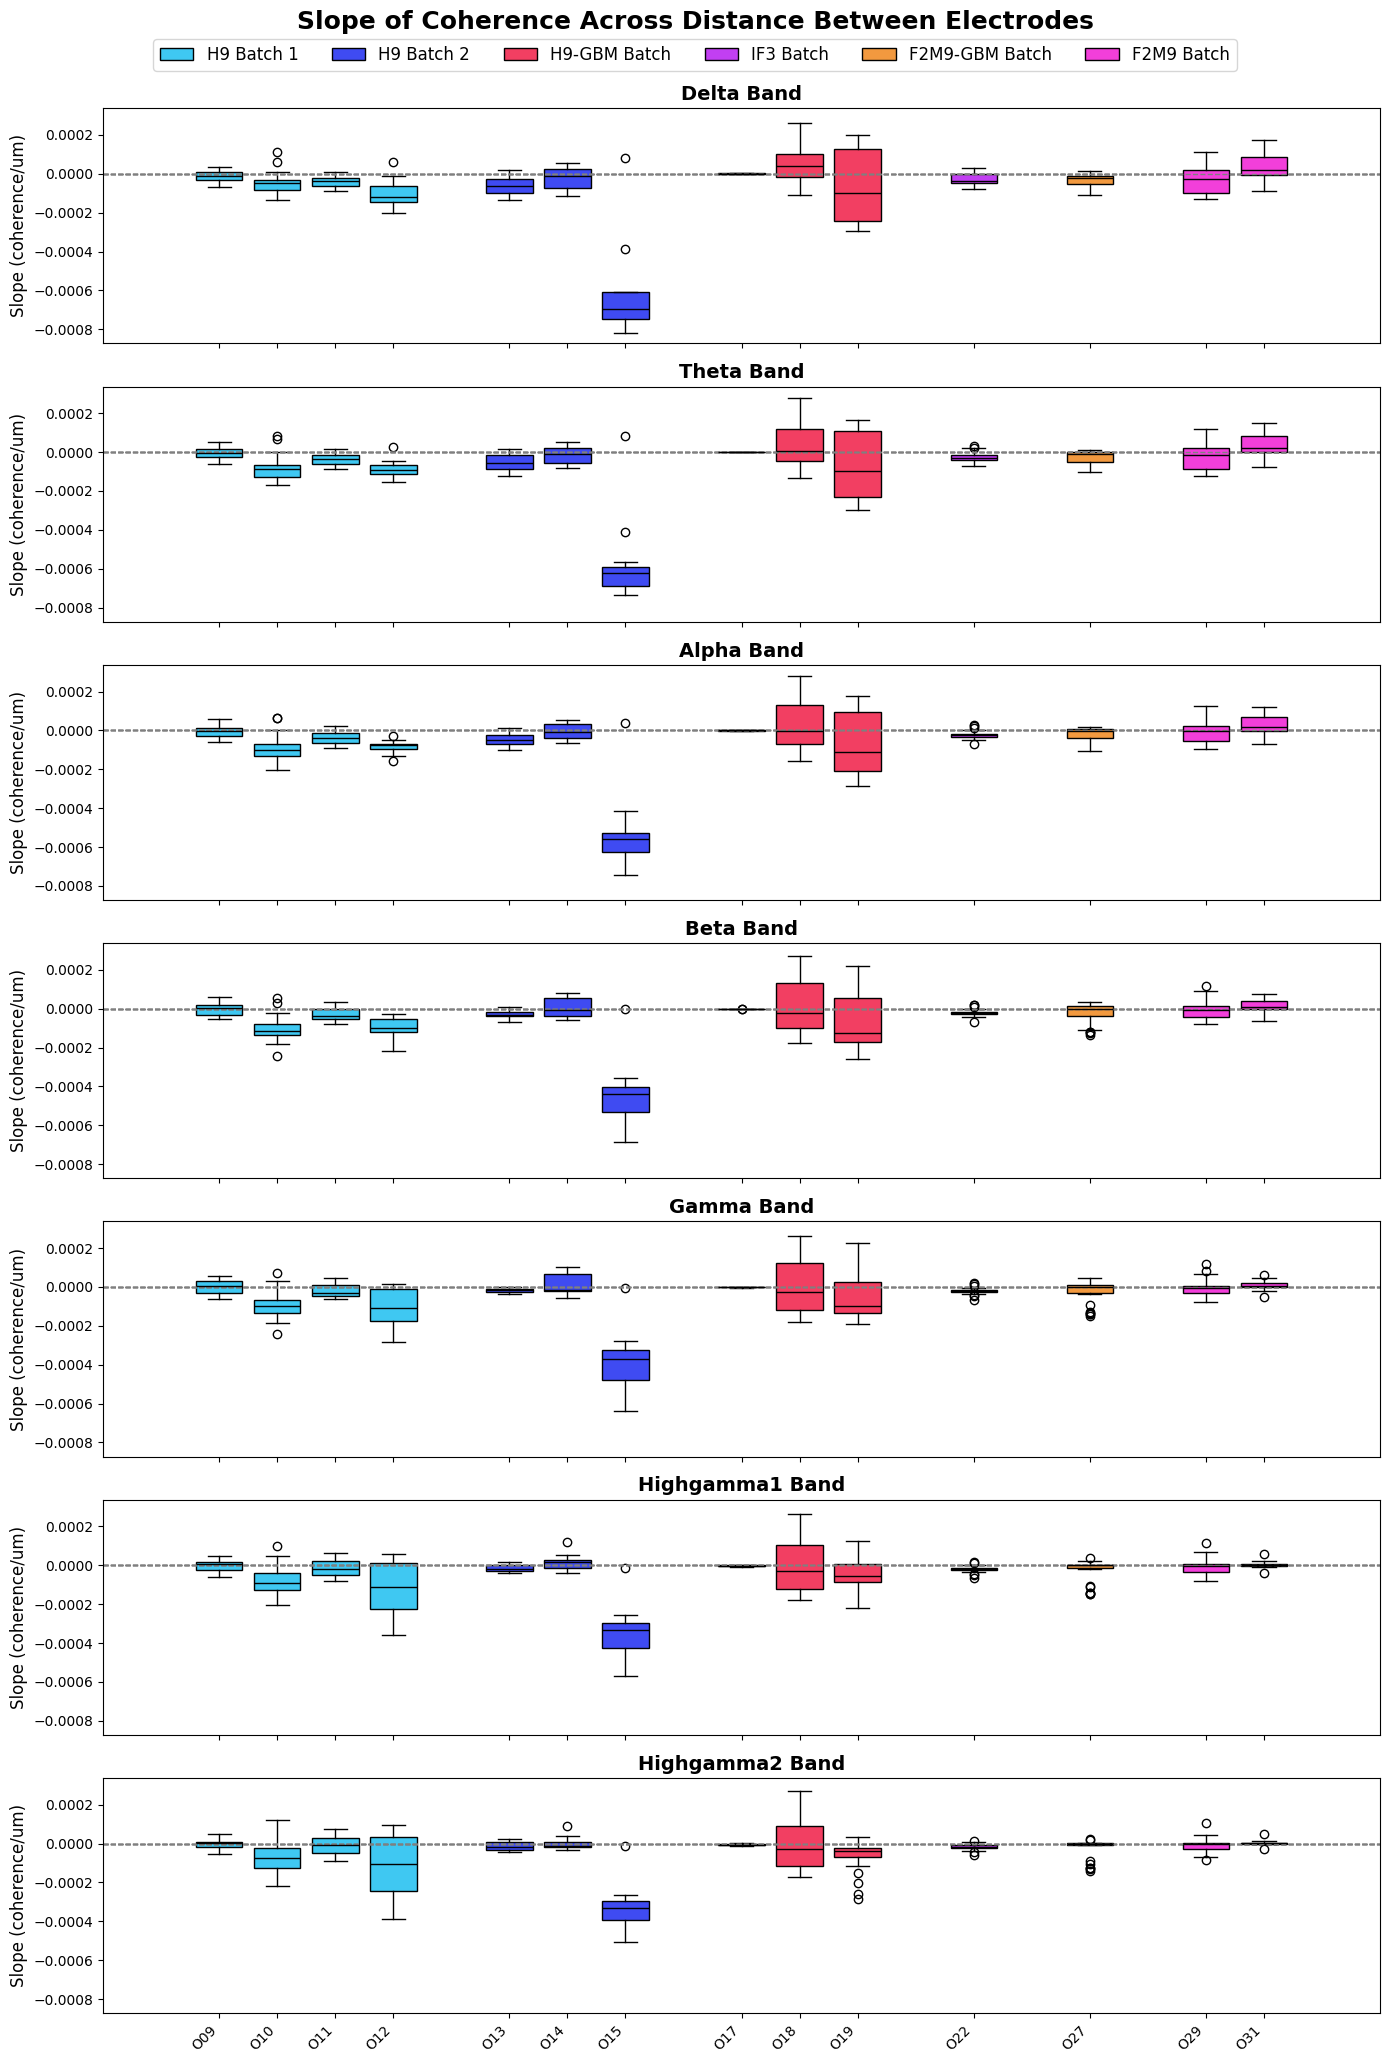

In [117]:
# Plot the linear fit slope of coherence vs distance for each frequency band (num bands x 1 figure)
# Box and whisker subplot of linear fit slopes (for each electrode) for each frequency band, colored by group, organoids on the x-axis

fig, axs = plt.subplots(len(frequency_bands), 1, figsize=(len(x_positions), 3*len(frequency_bands)), sharex=True, sharey=True)

for i, (band_name, (lower_freq, upper_freq)) in enumerate(frequency_bands.items()):
    band_mask = (frequency >= lower_freq) & (frequency <= upper_freq)
    ax = axs[i]

    for group_name, group_dict in connectivity_distance_dict.items():

        x = [x_positions[organoid_id] for organoid_id in list(group_dict.keys())]
        y = []
        for organoid_id, coherence_array in group_dict.items():

            organoid_coherence_values = np.mean(coherence_array[:, :, band_mask], axis=2) # average across frequency within the band

            organoid_slopes = []
            for elec_coherence_values in organoid_coherence_values:
                elec_mask = ~np.isnan(elec_coherence_values) # only include distances that have data for this electrode    
            
                slope, intercept, r_value, p_value, std_err = stats.linregress(unique_distances[elec_mask], elec_coherence_values[elec_mask])
                organoid_slopes.append(slope)
            y.append(organoid_slopes)

        # plot box and whisker for this band
        ax.boxplot(y, positions=x, widths=box_width, patch_artist=True,
                   boxprops=dict(facecolor=group_colors[group_name], color='black'),
                   medianprops=dict(color='black'),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'))
        ax.axhline(0, color='gray', linestyle='--', linewidth=1) # add horizontal line at y=0 for reference

    # customize subplot
    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')
    ax.set_title(f"{band_name.capitalize()} Band", fontsize=14, fontweight="bold")
    ax.set_ylabel("Slope (coherence/um)", fontsize=12)

# customize figure
fig.suptitle("Slope of Coherence Across Distance Between Electrodes", fontsize=18, fontweight="bold", y=0.98)
legend_elements = [Patch(facecolor=color, edgecolor='black', label=group_name) for group_name, color in group_colors.items()]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.97),
           ncol=len(group_colors), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])  # leaves top band for suptitle + legend

plt.show()
    

In [118]:
# Get coherence (synchronny)
synchrony_dict = {
    band_name: {}
    for band_name in frequency_bands.keys()
}

for group_name, keys in analysis_keys.items():

    # fetch synchrony data
    organoid_ids, band_names, electrode_indices, synchrony_values = (analysis.Coherence.Synchrony & keys).fetch("organoid_id", "band_name", "electrode", "synchrony")
    frequency = (analysis.Coherence.Synchrony & keys[0]).fetch("f")[0]
    synchrony_array = np.stack(synchrony_values) # num sessions x frequency

    for band_name in frequency_bands.keys():
        synchrony_dict[band_name][group_name] = {}
        band_mask = band_names == band_name

        for organoid_id in analysis_organoids_dict[group_name]:
            organoid_mask = organoid_ids == organoid_id
            num_elec_inside = (culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")

            organoid_synchrony = []
            for elec in range(num_elec_inside):
                elec_mask = electrode_indices == elec

                # ensure there are the expected number of data values
                if sum(organoid_mask & band_mask & elec_mask) != num_sessions_dict[group_name][organoid_id]:
                    raise ValueError(f"Expected {num_sessions_dict[group_name][organoid_id]} data points for organoid {organoid_id}, band {band_name}, and electrode {elec} but found {sum(organoid_mask & band_mask & elec_mask)}")

                mean_synchrony = np.mean(synchrony_array[organoid_mask & band_mask & elec_mask, :], axis=0)
                organoid_synchrony.append(mean_synchrony)
            synchrony_dict[band_name][group_name][organoid_id] = np.array(organoid_synchrony)

In [119]:
# TODO: Read through the "Synchrony (Coherence)" sheet in the file "Organoid_Analysis.xlsx" and populate the sheet using synchrony_dict
# each frequency band is given its own columns (an Organoid ID column, an Organoid Average column, and 32 Electrode Average columns).
# the top row for each band has the band name (e.g. "Delta", "Theta", etc.)
# loop through synchrony_dict using the final layer of dictionary keys to fill in the "Organoid ID" columns
# for each organoid, fill in the synchrony value for each electrode under the corresponding electrode index column and frequency band
#     if there are less than 32 values, leave the remaining columns blank
# under the "Organoid Average" column, fill in the average synchrony value across electrodes for each organoid
# Each organoid should fill one complete row (different frequency bands will have different collumns)

# Populate "Synchrony (Coherence)" sheet
# Sheet layout: 7 band blocks side-by-side (same 35-col stride).
#   Band block start columns (1-based): [1, 36, 71, 106, 141, 176, 211]
#   Block: Col 1 = "Organoid ID", Col 2 = "Organoid Average", Cols 3-34 = Electrodes 0-31, Col 35 = spacer
# synchrony_dict structure: {band_name: {group_name: {organoid_id: np.array shape (num_elec, num_freqs)}}}
# For each organoid, fill per-electrode mean synchrony averaged over the band's frequency range.

SYNC_BAND_START_COLS = [1, 36, 71, 106, 141, 176, 211]

wb_sync = openpyxl.load_workbook(excel_workbook_path)
ws_sync = wb_sync["Synchrony (Coherence)"]

sync_data_row = 3  # single shared row counter across all band blocks

# Iterate in organoid order (consistent across all bands)
# Build a flat list of (group_name, organoid_id) in the order they appear
seen_organoids = []
for band_name in band_name_order:
    for group_name, group_dict in synchrony_dict[band_name].items():
        for organoid_id in group_dict.keys():
            if (group_name, organoid_id) not in seen_organoids:
                seen_organoids.append((group_name, organoid_id))

for group_name, organoid_id in seen_organoids:
    for b_idx, band_name in enumerate(band_name_order):
        col_offset = SYNC_BAND_START_COLS[b_idx]
        sync_array = synchrony_dict[band_name][group_name][organoid_id]  # (num_elec, num_freqs)
        freq_mask_sync = (frequency >= frequency_bands[band_name][0]) & (frequency <= frequency_bands[band_name][1])
        elec_sync_means = np.mean(sync_array[:, freq_mask_sync], axis=1)  # (num_elec,)
        ws_sync.cell(row=sync_data_row, column=col_offset,     value=organoid_id)
        ws_sync.cell(row=sync_data_row, column=col_offset + 1, value=float(np.mean(elec_sync_means)))
        for elec_idx, sync_val in enumerate(elec_sync_means):
            ws_sync.cell(row=sync_data_row, column=col_offset + 2 + elec_idx, value=float(sync_val))
    sync_data_row += 1

wb_sync.save(excel_workbook_path)
print("Saved 'Synchrony (Coherence)'")

Saved 'Synchrony (Coherence)'


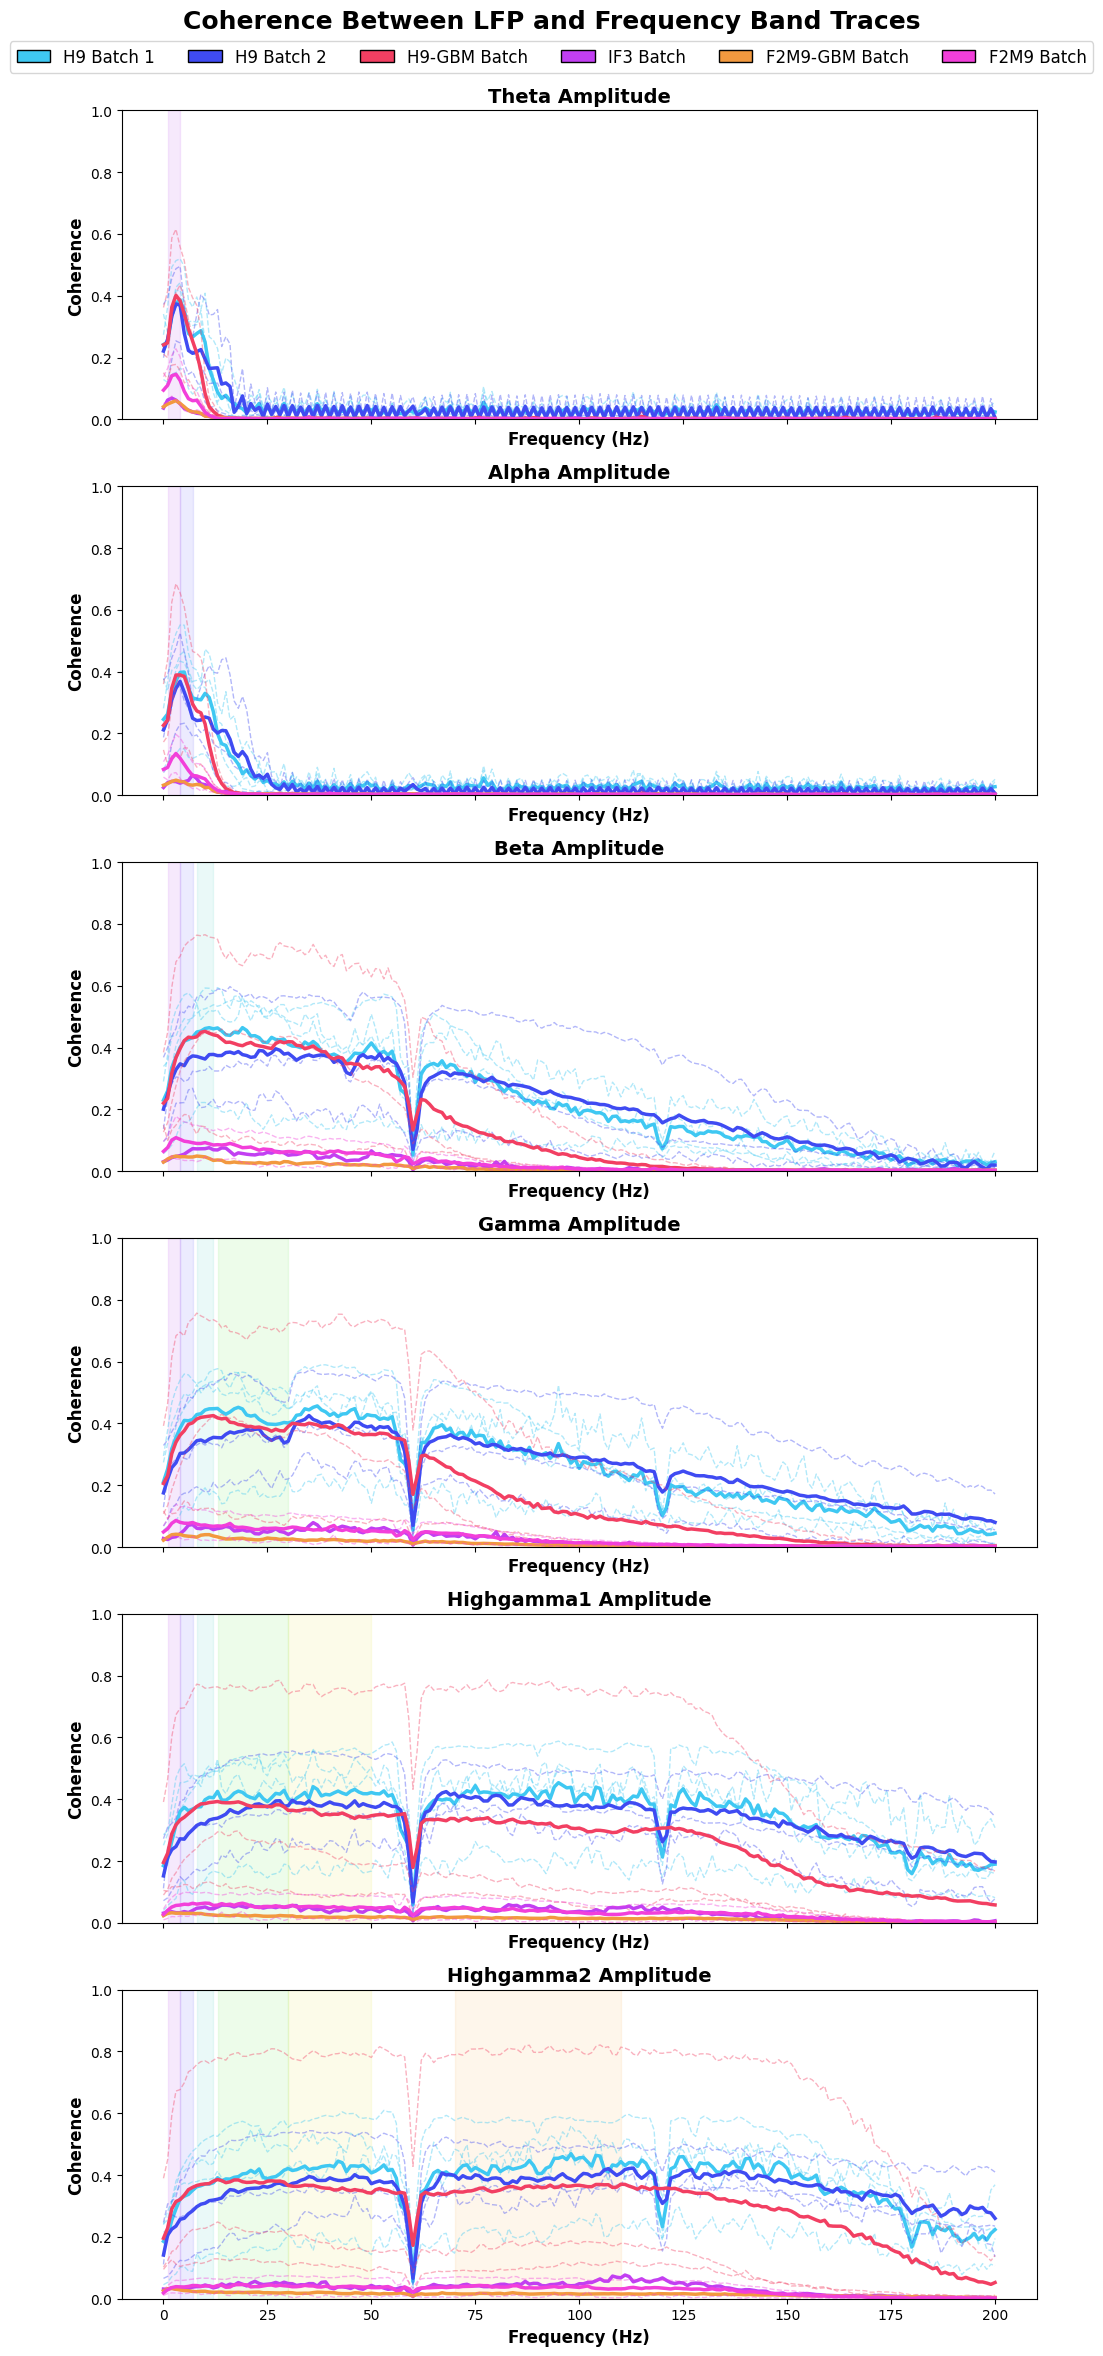

In [120]:
# Plot the synchronny values for each organoid and frequency band (num bands x 1 figure)
# Line plot of synchrony values for each organoid, colored by group, group average with bold line. Frequency band regions shaded in background

fig, axs = plt.subplots(len(frequency_bands)-1, 1, figsize=(10, 4*(len(frequency_bands)-1)), sharex=True, sharey=True)

for i, (band_name, band_dict) in enumerate(synchrony_dict.items()):
    if band_name == "delta":
        continue # skip delta band since it's two low to be an amplitude trace
    ax = axs[i-1]

    for group_name, group_dict in band_dict.items():

        group_synchrony = []
        for organoid_id, synchrony_array in group_dict.items():
            mean_synchrony = np.mean(synchrony_array, axis=0)
            ax.plot(frequency, mean_synchrony, color=group_colors[group_name], alpha=0.4, linewidth=1, linestyle="--")

            group_synchrony.append(mean_synchrony)

        # plot group average
        mean_group_synchrony = np.mean(group_synchrony, axis=0)
        ax.plot(frequency, mean_group_synchrony, color=group_colors[group_name], alpha=1, linewidth=2.5)

    # shade frequency band regions
    for other_band_name, (low_freq, high_freq) in frequency_bands.items():
        if frequency_bands[other_band_name][1] <= frequency_bands[band_name][0]: # only shade bands that are lower than the current band since synchrony is only calculated for frequencies lower than the band
            ax.axvspan(low_freq, high_freq, color=band_colors[other_band_name], alpha=0.1)  

    # customize subplot
    ax.set_title(f"{band_name.capitalize()} Amplitude", fontsize=14, fontweight="bold")
    ax.set_xlabel("Frequency (Hz)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Coherence", fontsize=12, fontweight="bold") 
    ax.set_ylim(0, 1)

# customize figure
fig.suptitle("Coherence Between LFP and Frequency Band Traces", fontsize=18, fontweight="bold", y=0.98)
legend_elements = [Patch(facecolor=color, edgecolor='black', label=group_name) for group_name, color in group_colors.items()]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.97),
           ncol=len(group_colors), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])  # leaves top band for suptitle + legend

plt.show()

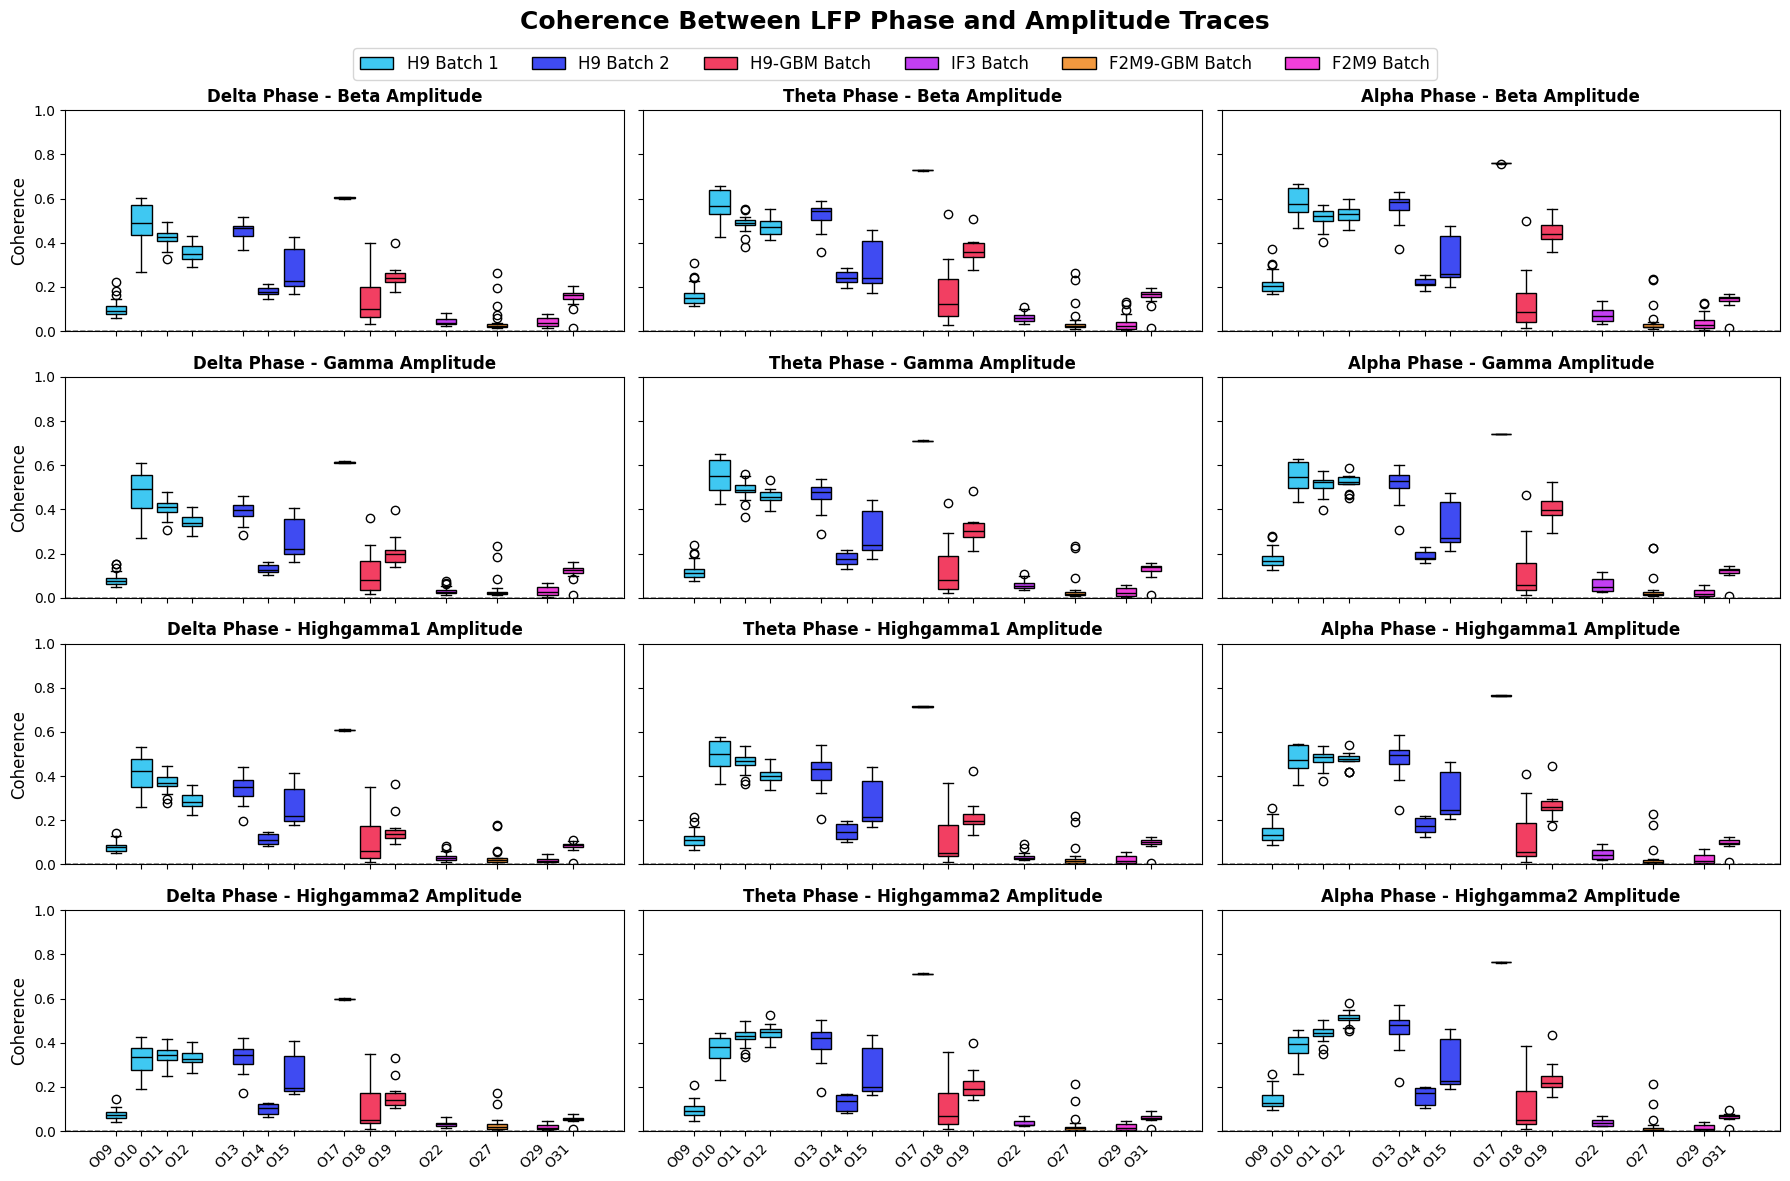

In [121]:
# Plot coherence spread (across electrodes) for the various phase-amplitude bands (num amplitude bands x num phase bands figure)
# Box and whisker subplot for each phase-amplitude band combination, colored by group, organoids on the x-axis

amplitude_band_names = ["beta", "gamma", "highgamma1", "highgamma2"]
phase_band_names = ["delta", "theta", "alpha"]

fig, axs = plt.subplots(len(amplitude_band_names), len(phase_band_names), figsize=(6*len(phase_band_names), 3*len(amplitude_band_names)), sharex=True, sharey=True)

for i, amp_band_name in enumerate(amplitude_band_names):
    for j, phase_band_name in enumerate(phase_band_names):
        ax = axs[i, j]
        phase_band_mask = (frequency >= frequency_bands[phase_band_name][0]) & (frequency <= frequency_bands[phase_band_name][1])

        for group_name, group_dict in synchrony_dict[amp_band_name].items():

            x = [x_positions[organoid_id] for organoid_id in list(group_dict.keys())]
            y = []

            for organoid_id, synchrony_array in group_dict.items():

                mean_synchrony = np.mean(synchrony_array[:, phase_band_mask], axis=1) # average synchrony across frequencies within the phase band for each electrode
                y.append(mean_synchrony)

            # plot box and whisker for this band
            ax.boxplot(y, positions=x, widths=box_width, patch_artist=True,
                       boxprops=dict(facecolor=group_colors[group_name], color='black'),
                       medianprops=dict(color='black'),
                       whiskerprops=dict(color='black'),
                       capprops=dict(color='black'))
            ax.axhline(0, color='gray', linestyle='--', linewidth=1) # add horizontal line at y=0 for reference

        # customize subplot
        ax.set_xticks(list(x_positions.values()))
        ax.set_xticklabels(list(x_positions.keys()), rotation=45, ha='right')
        ax.set_title(f"{phase_band_name.capitalize()} Phase - {amp_band_name.capitalize()} Amplitude", fontsize=12, fontweight="bold")
        ax.set_ylim(0, 1)

        if j == 0:
            ax.set_ylabel("Coherence", fontsize=12)

# customize figure
fig.suptitle("Coherence Between LFP Phase and Amplitude Traces", fontsize=18, fontweight="bold", y=0.98)
legend_elements = [Patch(facecolor=color, edgecolor='black', label=group_name) for group_name, color in group_colors.items()]
fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0.955),
           ncol=len(group_colors), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])  # leaves top band for suptitle + legend

plt.show()